<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    ETL and ML Workflow for CO₂ Uptake Data Cleaning, Feature Scaling, and Predictive Modeling
    
</center></p></h1>

<!DOCTYPE html>
<html>
<head>
  <style>
    .center-img {
      display: block;
      margin-left: auto;
      margin-right: auto;
      max-width: 80%; /* optional: control size */
    }
  </style>
</head>
<body>
  <img src="Screenshot 2025-09-21 144650.png" alt="Screenshot" class="center-img">
</body>
</html>

< img scr=![Screenshot 2025-09-21 144650.png](<attachment:Screenshot 2025-09-21 144650.png>)>

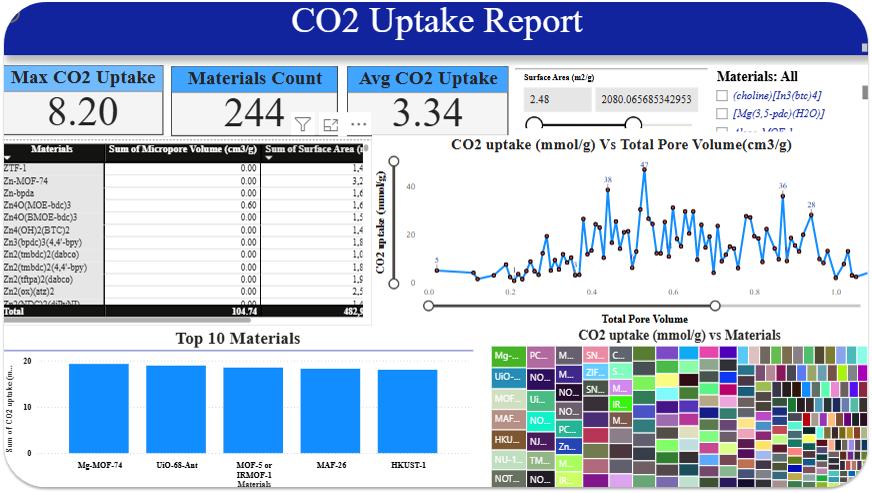

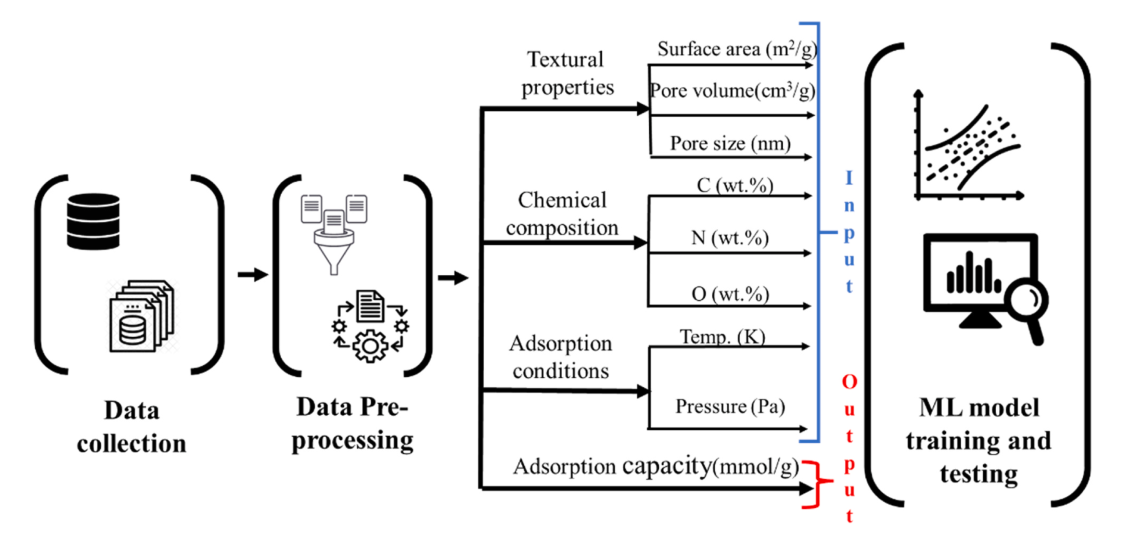



<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">
    <p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">
        About the Dataset
    </p>
    <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
        This dataset contains information on porous materials and their CO₂ uptake performance. It includes 
        <strong>527+ entries</strong> with <strong>54 features</strong>, covering material properties, experimental conditions, 
        and chemical structure descriptors. The primary target variable is <strong>CO2 uptake (mmol/g)</strong>. 
        Each material is identified by its name (e.g., HKUST-1, MOF-5, ZIF-8).
    </p>

<p style="text-align: justify; font-family: cursive; font-size: 14px; color: green; font-weight: bold;">Key Features</p>
    <ul style="font-family: cursive; font-size: 14px; color: black;">
        <li><strong>Material Properties:</strong> Surface Area (m²/g), Total Pore Volume (cm³/g), Specific Pore Volume (cm³/g).</li>
        <li><strong>Experimental Conditions:</strong> Pressure (bar), Temperature (°C).</li>
        <li><strong>CO₂ Uptake:</strong> CO2 uptake (mmol/g) per gram of material.</li>
        <li><strong>Chemical Structure Descriptors:</strong>
            <ul>
                <li>Bond types: C-C, C=C, C≡C, C-O, C=O, C-N, C≡N, etc.</li>
                <li>Ring structures: e.g., (ring) C-C (ring), (ring) N-S (ring)</li>
                <li>Metal nodes: Al, Cd, Co, Cu, Mg, Mn, Ni, Zn, Zr (binary indicators)</li>
            </ul>
        </li>
    </ul>
</div>


  <font size='4'>
Outline:<br>
- Summary about file<br>
- Importing libraies and dataset<br> 
- General information from dataset<br>
- Cleanning dataset<br>
- features selection<br>
- Checking three set of dataset(oroginal, modified and after feature selection<br>
- Effect of models and scalers on datasets<br>
- Choosing GBR method with minmax scaler<br>
- Compersion original and feture selection dataset using some models and attributes<br>
- Showing results.<br>
- Applying ANN on two datasets


<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">3️⃣ Step 2 | Python Libraries </font><br>
 <br>   
<br>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers,layers,callbacks
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import f_oneway, ttest_ind
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import learning_curve, cross_val_score, cross_validate
from math import sqrt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression
from scipy import stats 

import streamlit as st
import joblib
import plotly.express as px

import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [ ]:
df_1 = pd.read_excel('datapoints.xlsx')
df = df_1.copy() # fro heatmap and feature analysis

In [4]:
df.head()

,Materials,Surface Area (m2/g),Total Pore Volume(cm3/g),Micropore Volume (cm3/g),Temp (°C),Pressure (bar),CO2 uptake (mmol/g),C-C,C-C (ring),(ring) C-C (ring),...,Ti,Be,Pd,Y,Er,In,Cr,Fe,Mo,Zr
0,Be12(OH)12(BTB)4,1281.6,0.71,0.32,25,1.0,2.625000,0,3,15,...,0,1,0,0,0,0,0,0,0,0
1,Be12(OH)12(BTB)4,1012.6,0.56,0.22,25,1.0,2.586364,0,3,15,...,0,1,0,0,0,0,0,0,0,0
2,Be12(OH)12(BTB)4,1408.8,0.83,0.36,25,1.0,2.920455,0,3,15,...,0,1,0,0,0,0,0,0,0,0
3,Be12(OH)12(BTB)4,1403.9,0.85,0.33,25,1.0,2.438636,0,3,15,...,0,1,0,0,0,0,0,0,0,0
4,Cd4(TCPM)2,841.3,0.36,NaN,25,1.0,3.230000,0,8,12,...,0,0,0,0,0,0,0,0,0,0


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [35]:
# info from of datasets
print(' shape of data set is = ',df.shape)
print()

print(' dataset head:\n')
df.head()
print()

print(' dataset info:\n')
dfinfo=df.info()
print()

print(' describtion of data set:\n')
df_des=df.describe().transpose()
df_des


 shape of data set is =  (527, 54)

 dataset head:


 dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Materials                 527 non-null    object 
 1   Surface Area (m2/g)       527 non-null    float64
 2   Total Pore Volume(cm3/g)  499 non-null    float64
 3   Micropore Volume (cm3/g)  317 non-null    float64
 4   Temp (°C)                 527 non-null    int64  
 5   Pressure (bar)            527 non-null    float64
 6   CO2 uptake (mmol/g)       527 non-null    float64
 7   C-C                       527 non-null    int64  
 8   C-C (ring)                527 non-null    int64  
 9   (ring) C-C (ring)         527 non-null    int64  
 10  C=C                       527 non-null    int64  
 11  C-O                       527 non-null    int64  
 12  C=O                       527 non-null    int64  
 

,count,mean,std,min,25%,50%,75%,max
Surface Area (m2/g),527.0,1488.150152,728.611596,2.48,955.500,1420.00,1960.000,3337.00000
Total Pore Volume(cm3/g),499.0,0.800020,0.448172,0.02,0.480,0.69,1.030,3.09000
Micropore Volume (cm3/g),317.0,0.516845,0.272742,0.04,0.310,0.48,0.690,1.29000
Temp (°C),527.0,18.462998,11.009418,0.00,0.000,25.00,25.000,30.00000
Pressure (bar),527.0,0.866636,0.311198,0.10,1.000,1.00,1.000,1.01325
CO2 uptake (mmol/g),527.0,3.453549,1.567808,0.36,2.335,3.46,4.345,8.20000
C-C,527.0,0.252372,0.786573,0.00,0.000,0.00,0.000,6.00000
C-C (ring),527.0,3.597723,2.758574,0.00,2.000,3.00,4.000,18.00000
(ring) C-C (ring),527.0,9.504744,7.835735,0.00,3.000,7.00,13.000,43.00000
C=C,527.0,0.041746,0.329424,0.00,0.000,0.00,0.000,6.00000


# Distribution and analysing dataset

<Figure size 1280x960 with 0 Axes>

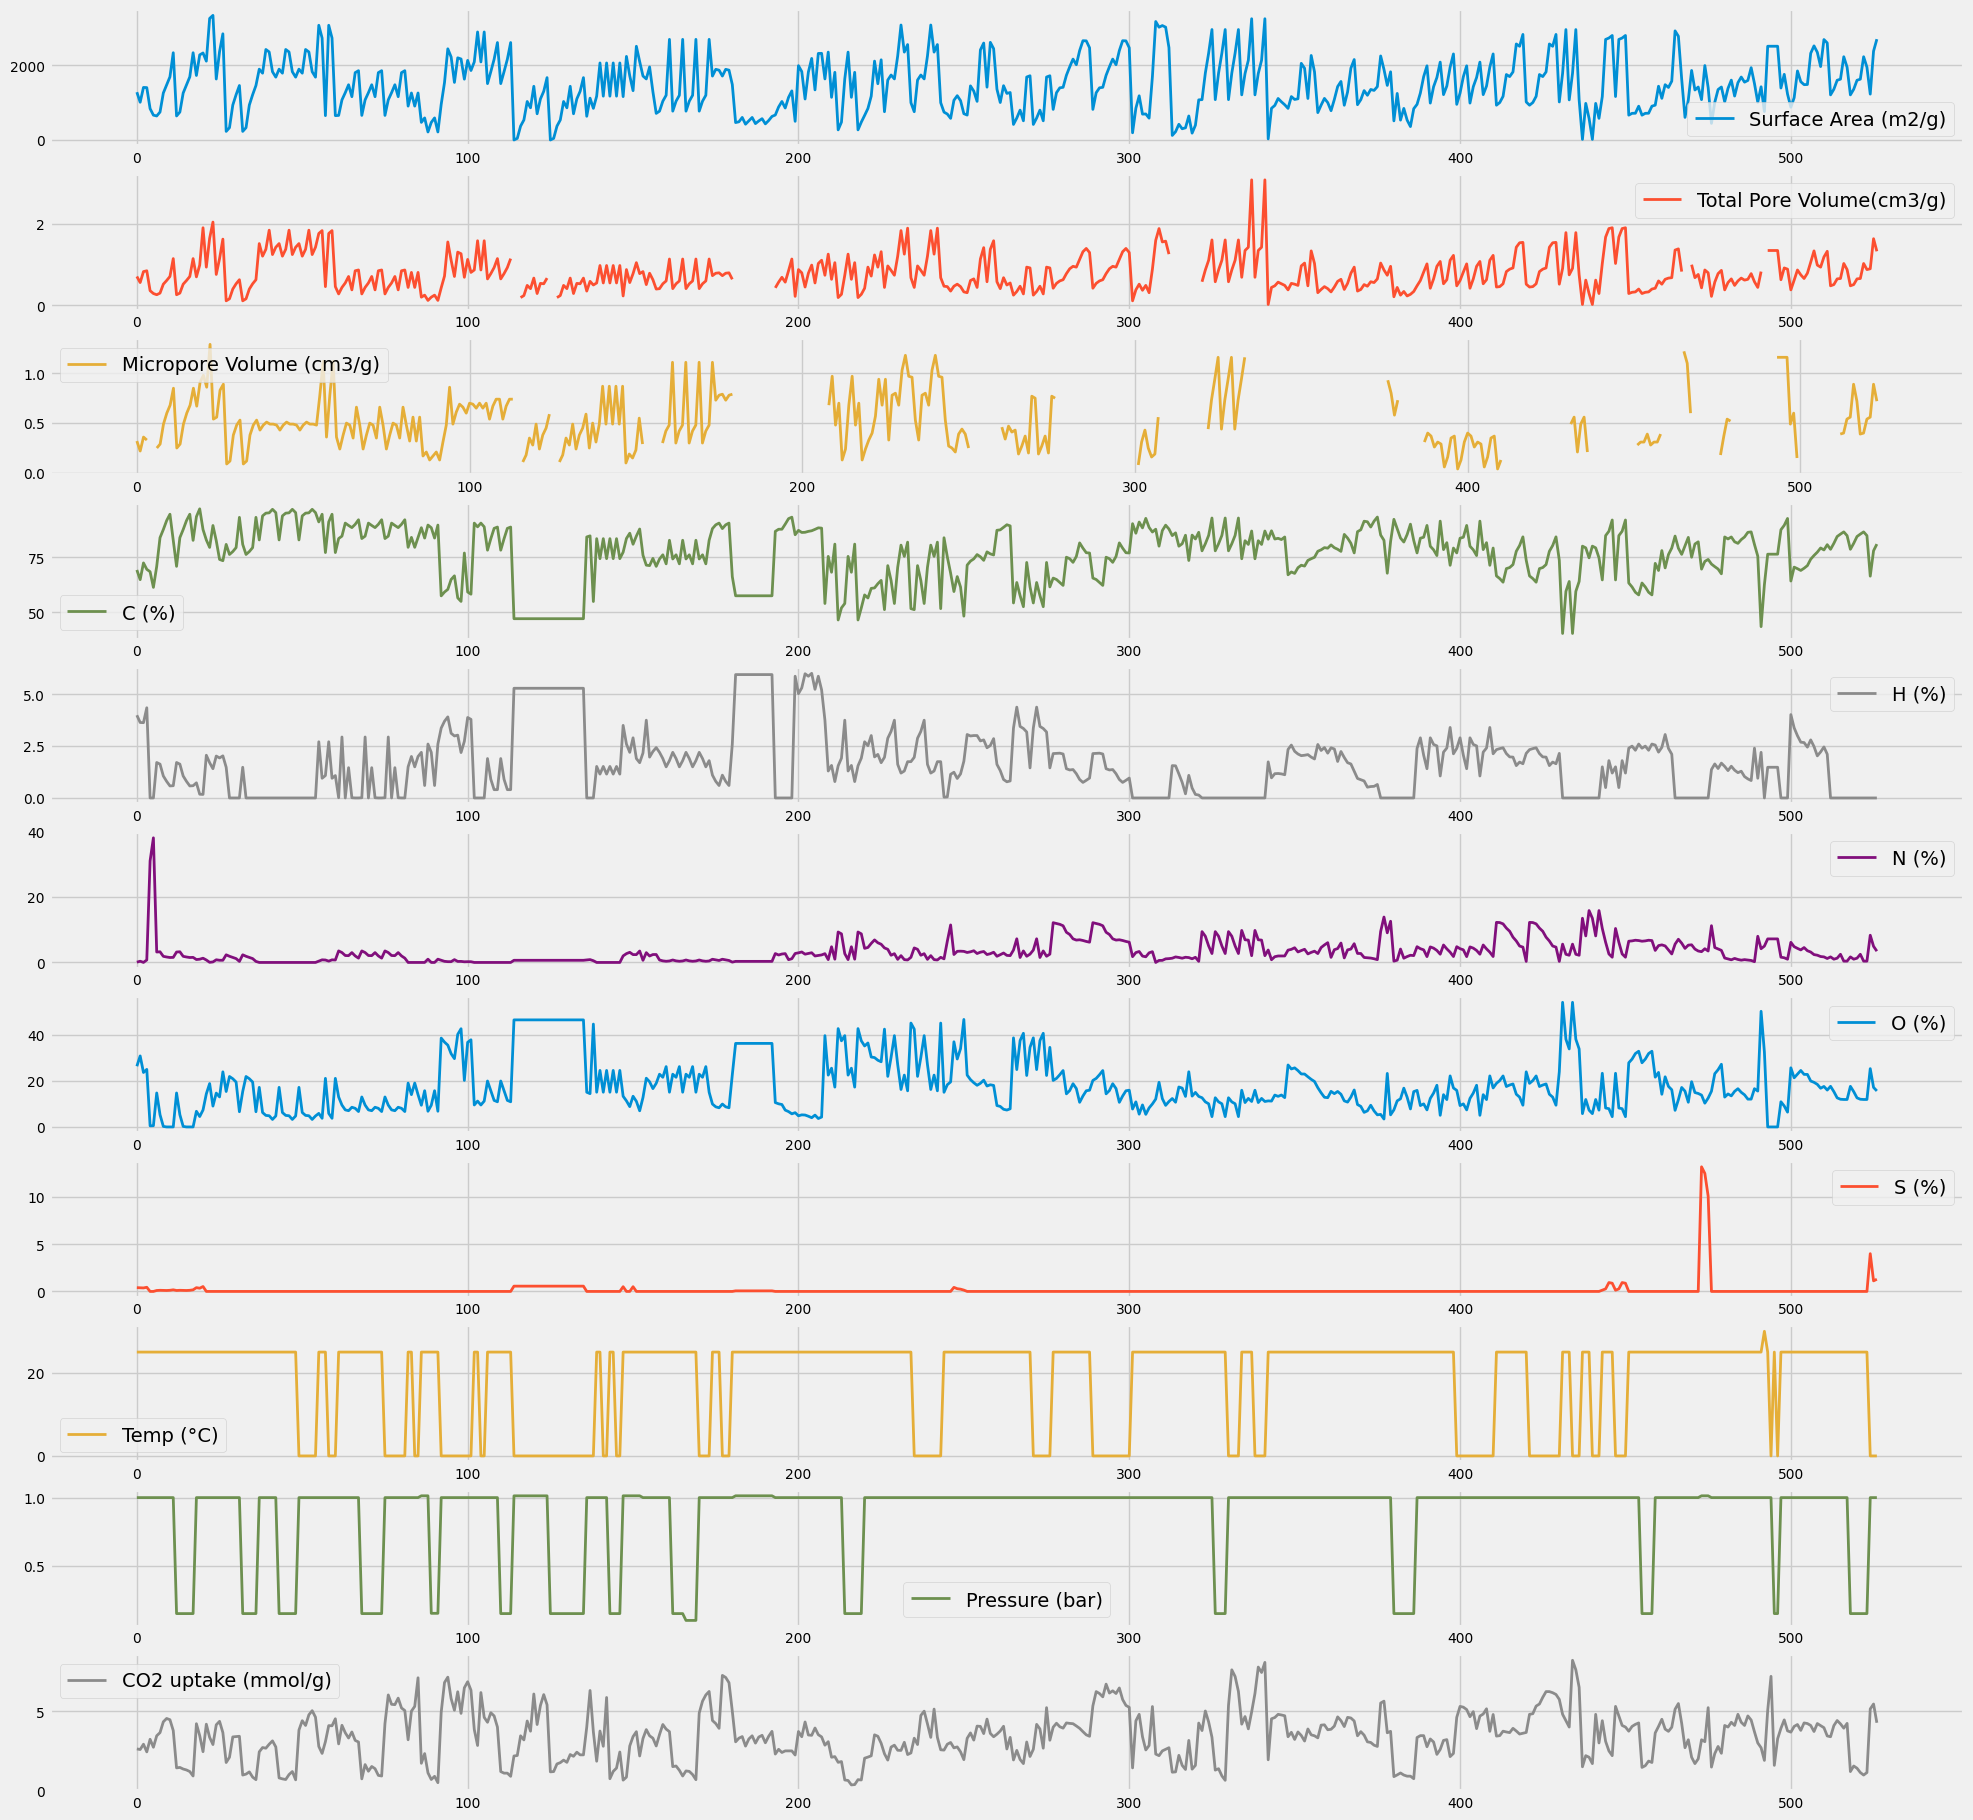

In [54]:
# Visualization of the primary dataset
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
df.plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

In [23]:
df.columns

Index(['Materials', 'Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'Temp (°C)', 'Pressure (bar)',
       'CO2 uptake (mmol/g)', 'C-C', 'C-C (ring)', '(ring) C-C (ring)', 'C=C',
       'C-O', 'C=O', 'C-N', 'C=N', '(ring) N - N (ring)', 'N=N',
       '(ring) N=N (ring)', '(ring) C-O', '(ring) C=O', ' (ring) C-S (ring)',
       ' (ring) N-S (ring)', '(ring) C-N', 'C-N (ring)', '(ring) C=C (ring)',
       '(ring) N-C (ring)', '(ring) N=C (ring)', 'C ≡ C', 'C ≡ N', 'N - O',
       'N = O', 'O - R', 'C - R', '(ring) C - R', 'Al', 'Cd', 'Co', 'Cu', 'Mg',
       'Mn', 'Ni', 'Zn', 'Zn4O', 'Sc', 'Ti', 'Be', 'Pd', 'Y', 'Er', 'In', 'Cr',
       'Fe', 'Mo', 'Zr'],
      dtype='object')

In [3]:
# Visualization of the primary dataset
df_col=['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)']

<Figure size 1280x960 with 0 Axes>

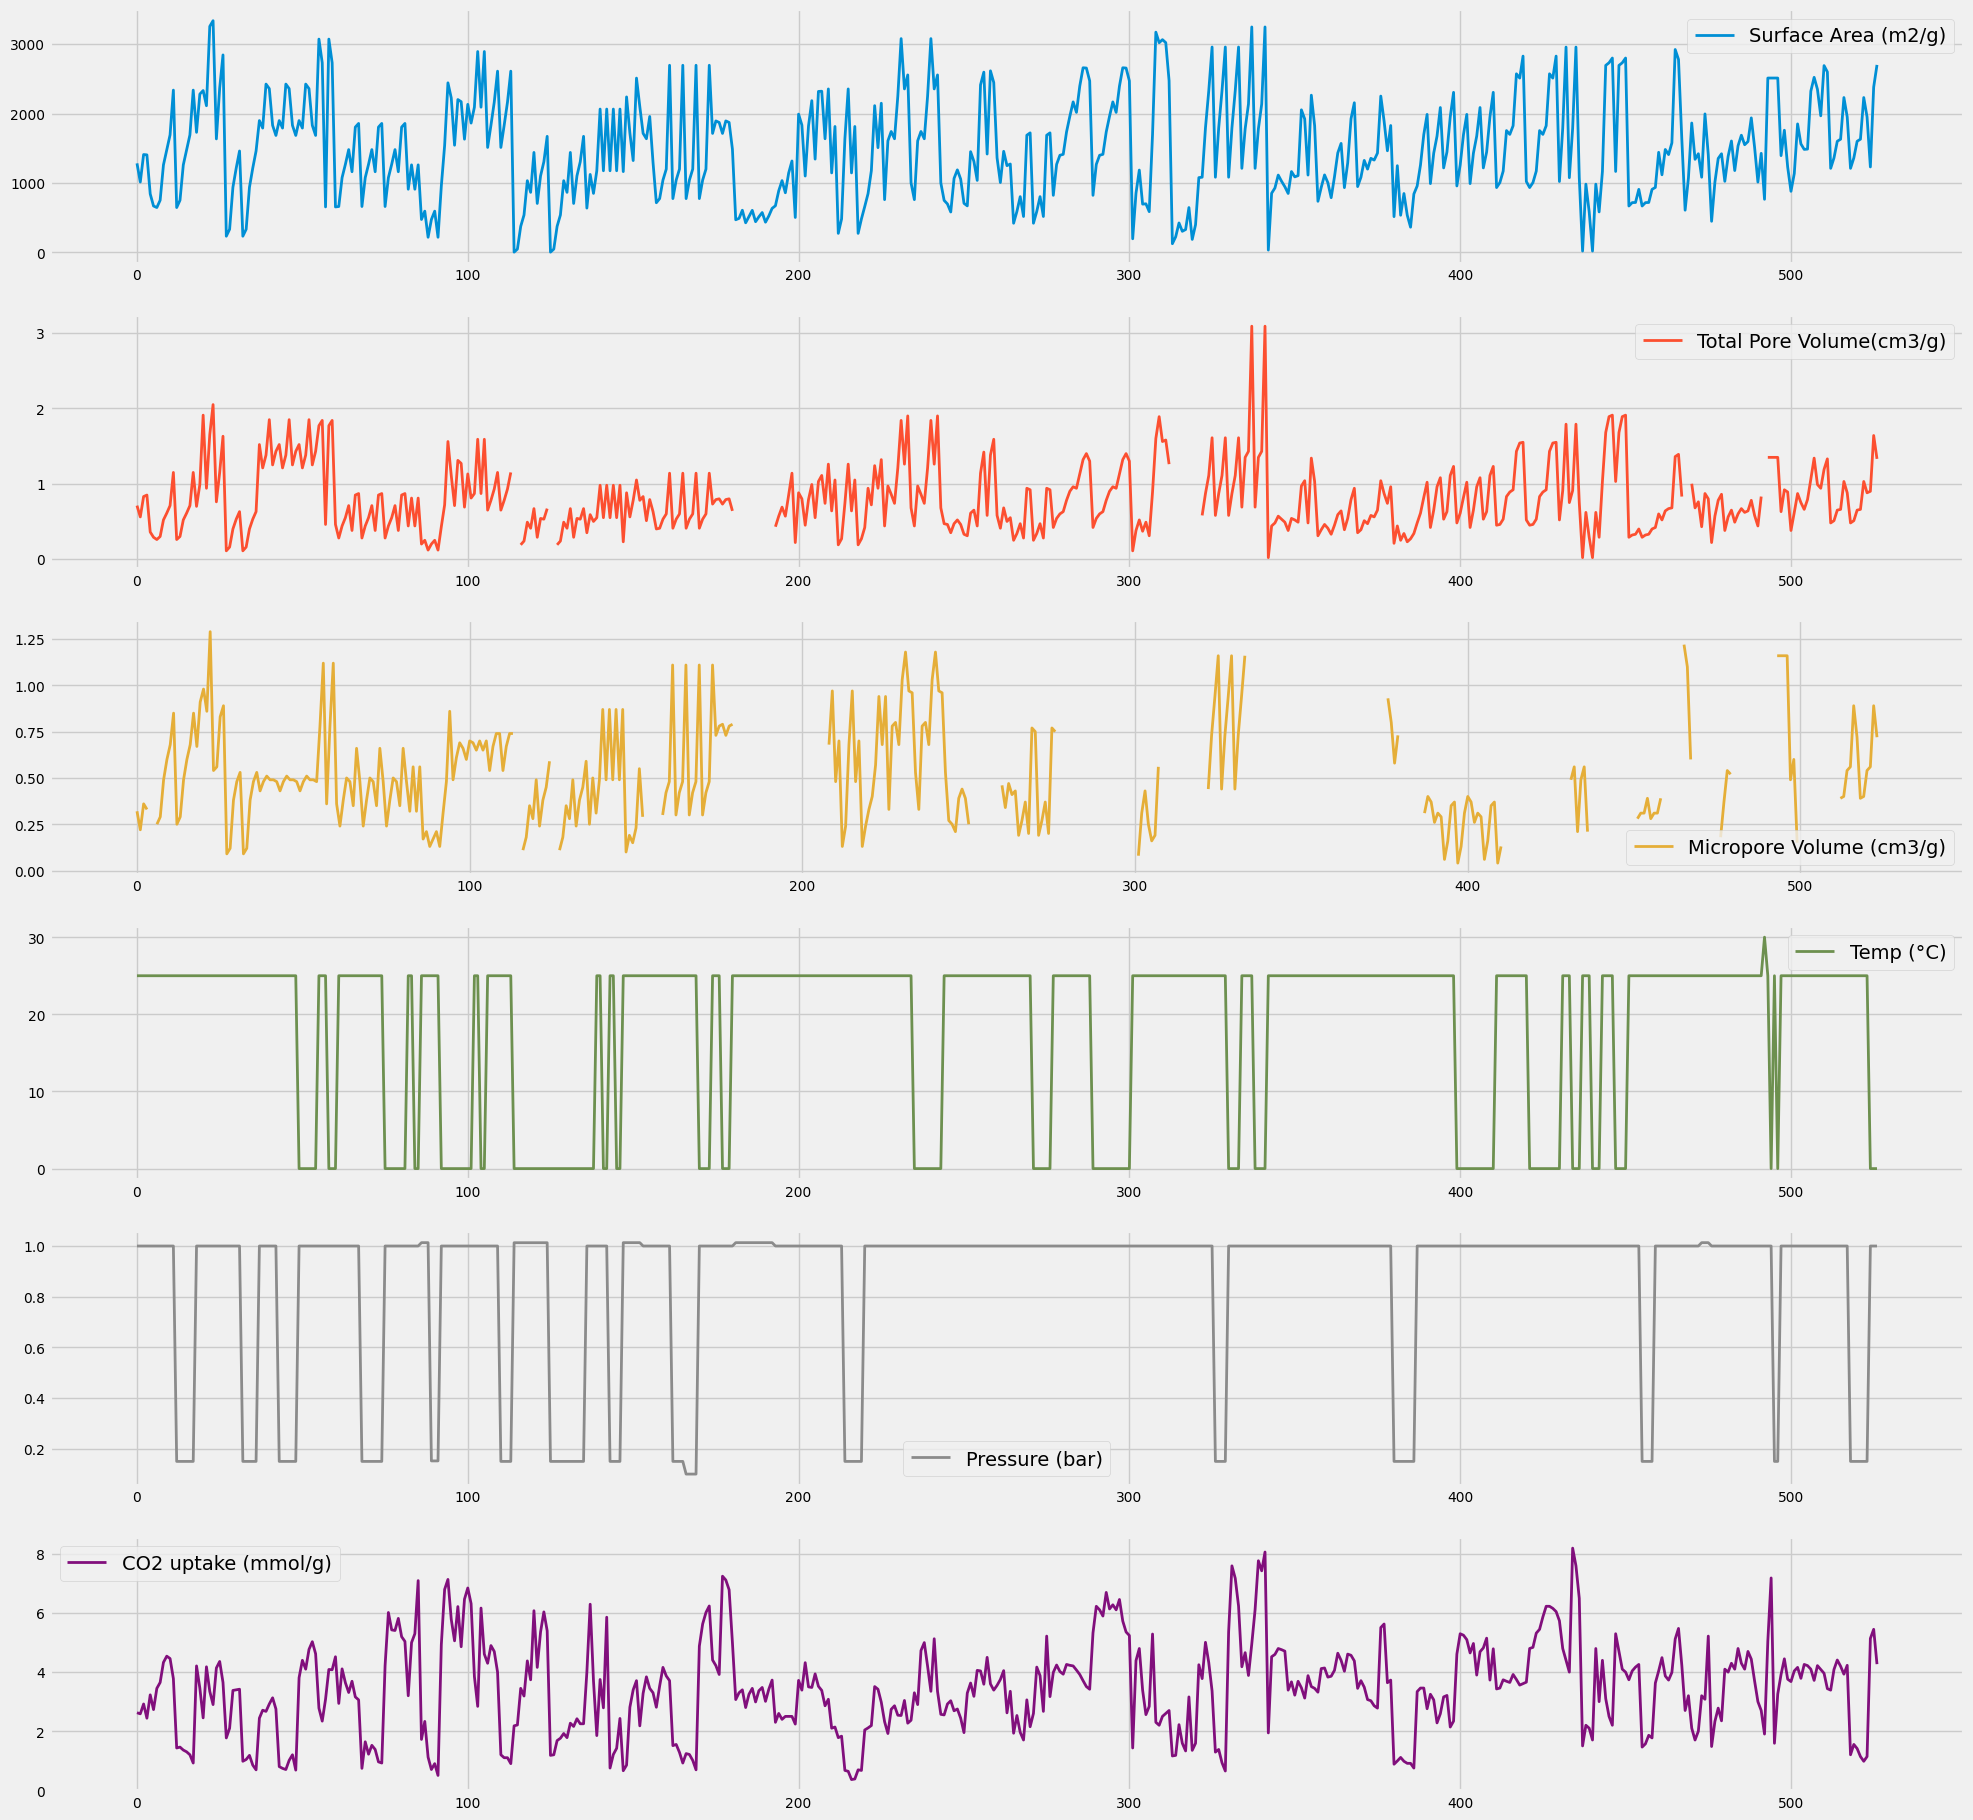

In [ ]:

plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
df[df_col].plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

<Figure size 1280x960 with 0 Axes>

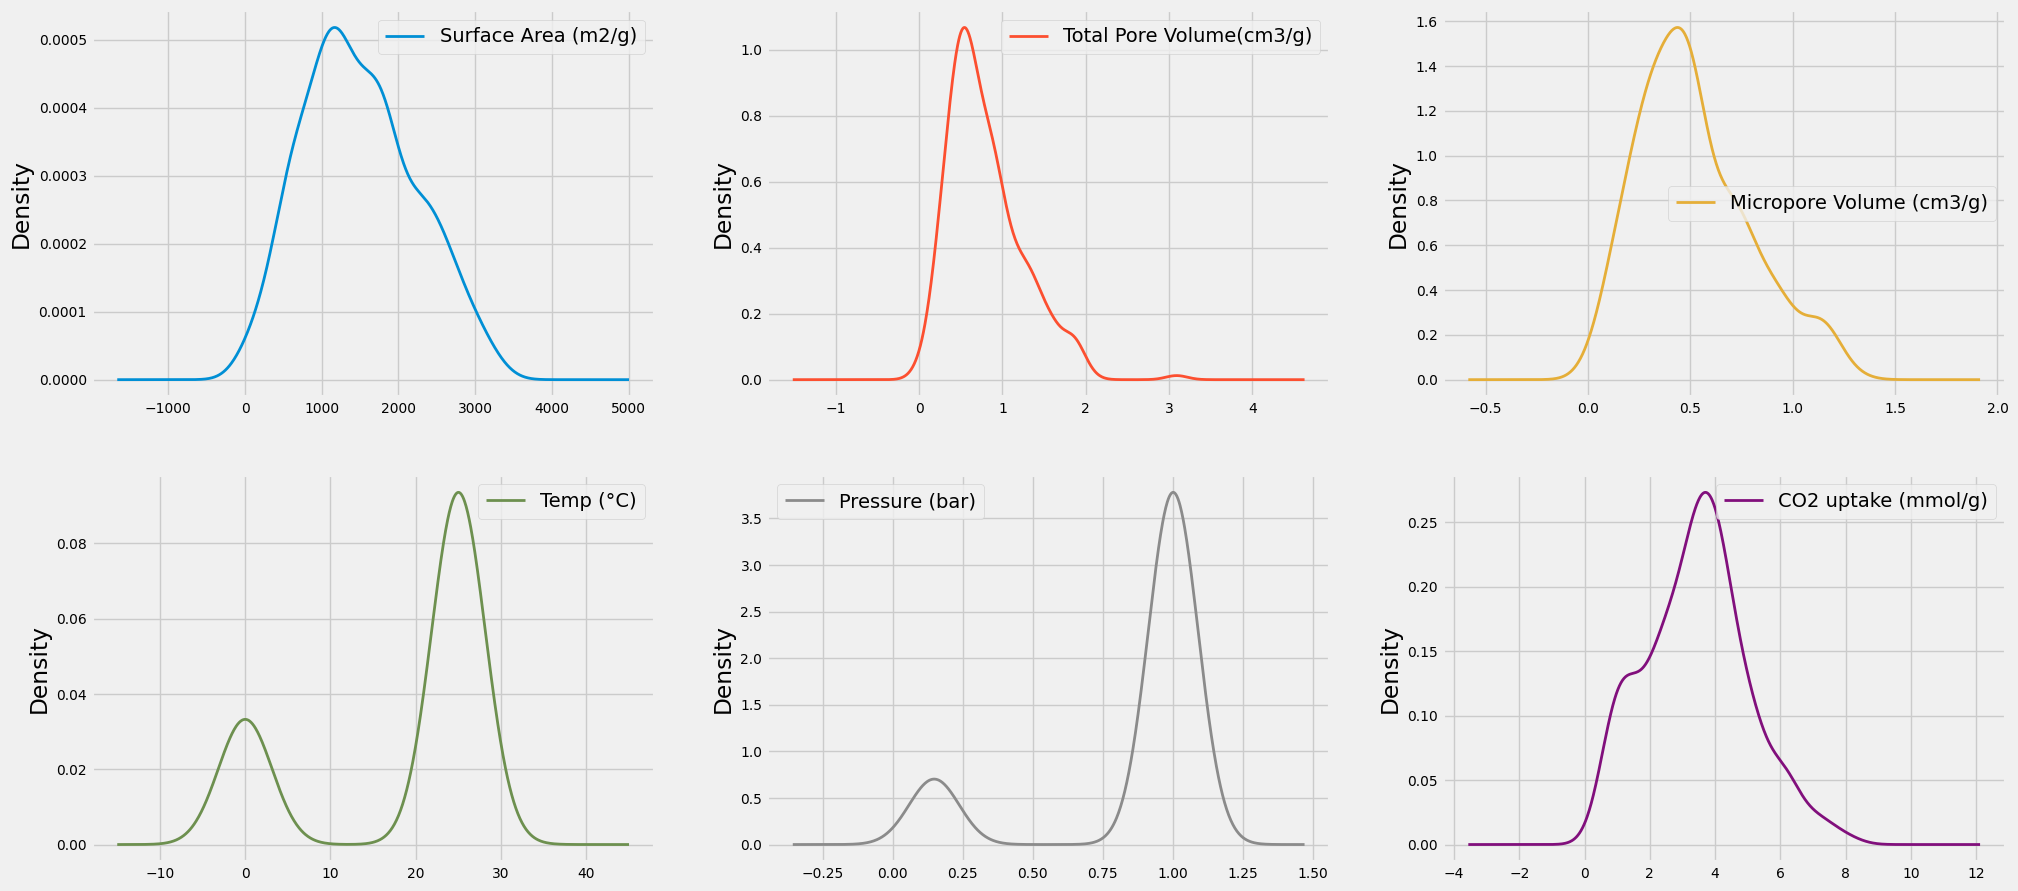

In [58]:
#disribution of the primary dataset
plt.figure(dpi=200)
df[df_col].plot(kind='density',subplots=True,layout=(4, 3), figsize=(22,22),
           fontsize=10, linewidth=2, sharex=False);
plt.show()

In [59]:
def density_features(dataset, feature_name):
    """
    Plot histogram + KDE for a given feature in the dataset.
    Also shows vertical lines for mean and median.
    """
    print(dataset.columns)
    sns.set(style="darkgrid")

    # Define the figure and axis
    f, ax_hist = plt.subplots(figsize=(8, 6), dpi=400)

    # Plot the histogram with KDE (replacement for distplot)
    sns.histplot(dataset[feature_name], ax=ax_hist, color='skyblue', kde=True)

    # Plot vertical lines for mean and median
    mean_value = dataset[feature_name].mean()
    median_value = dataset[feature_name].median()
    ax_hist.axvline(median_value, color='red', linewidth=1.7)
    ax_hist.axvline(mean_value, color="blue", linestyle='--', linewidth=1.7)

    # Add text labels for mean and median
    ax_hist.text(mean_value, ax_hist.get_ylim()[1] * 0.9,
                 f'Mean   = {mean_value:.2f}', color='blue', ha='center')
    ax_hist.text(median_value, ax_hist.get_ylim()[1] * 0.85,
                 f'Median = {median_value:.2f}', color='red', ha='center')

    ax_hist.set_xlabel(feature_name, fontsize=18)
    ax_hist.set_ylabel('Density', fontsize=18)
    plt.show()

Index(['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'C (%)', 'H (%)', 'N (%)', 'O (%)', 'S (%)',
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)'],
      dtype='object')


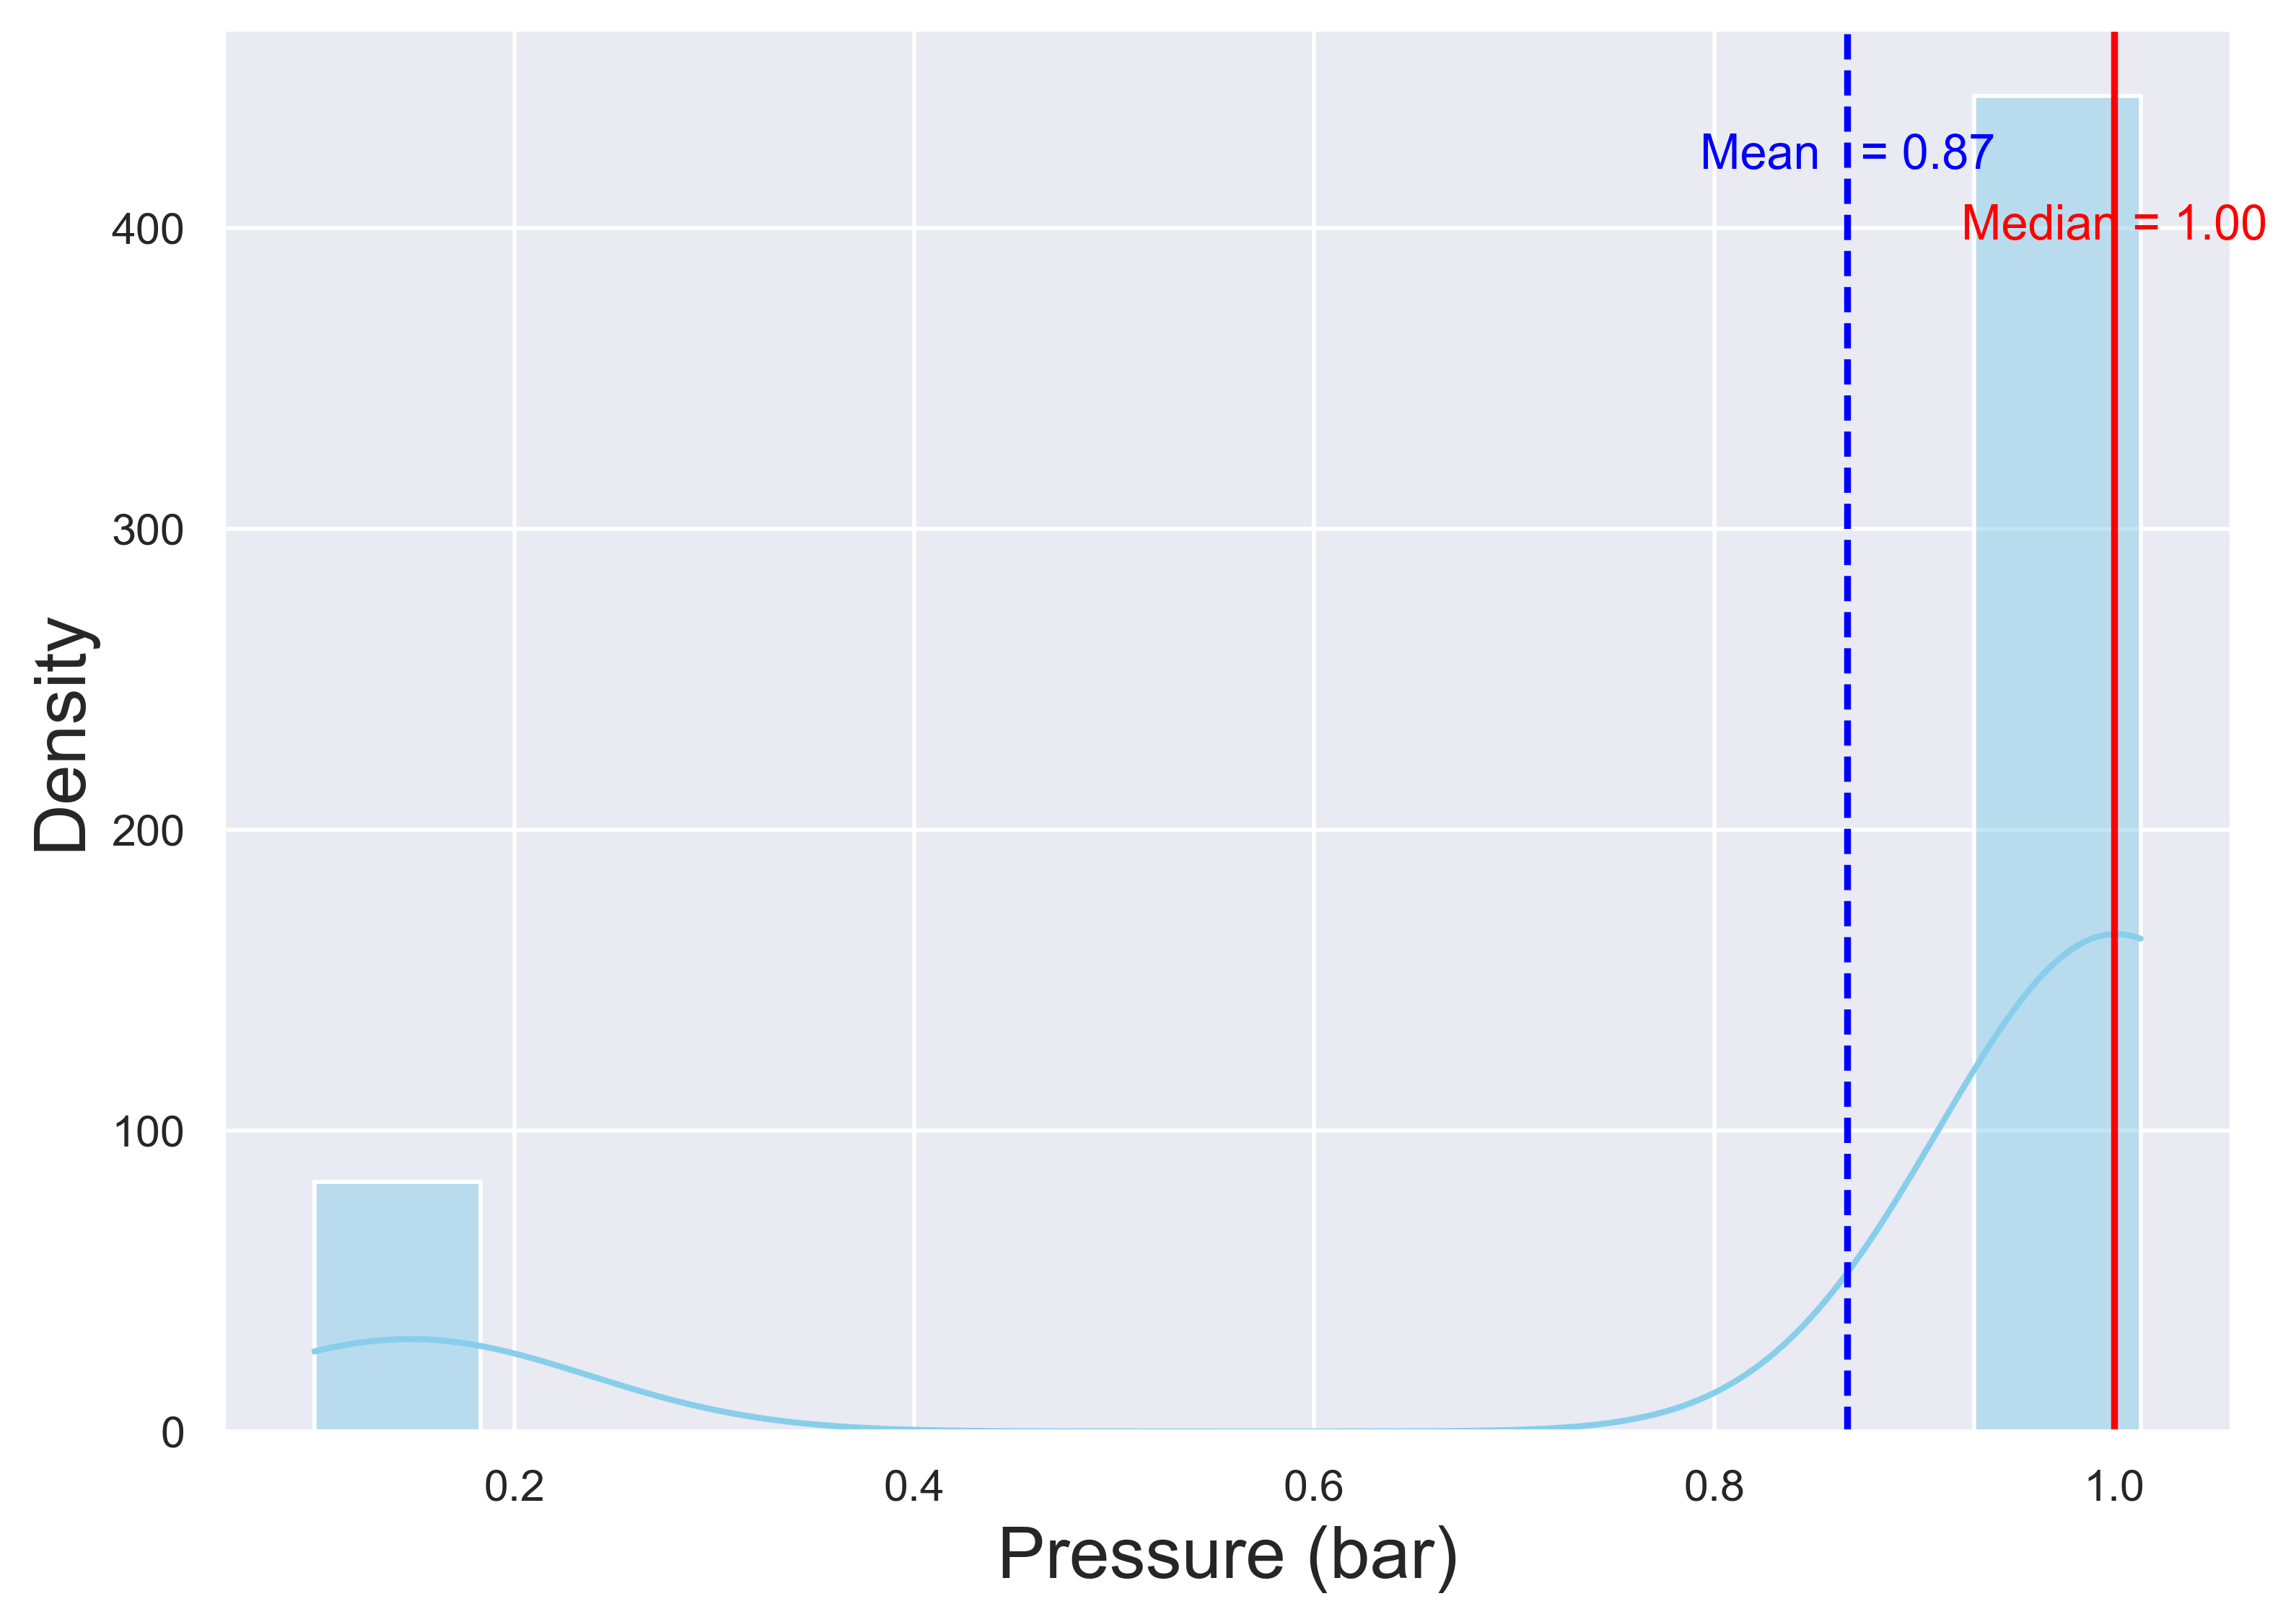

In [60]:
density_features(df, 'Pressure (bar)') 

Index(['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'C (%)', 'H (%)', 'N (%)', 'O (%)', 'S (%)',
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)'],
      dtype='object')


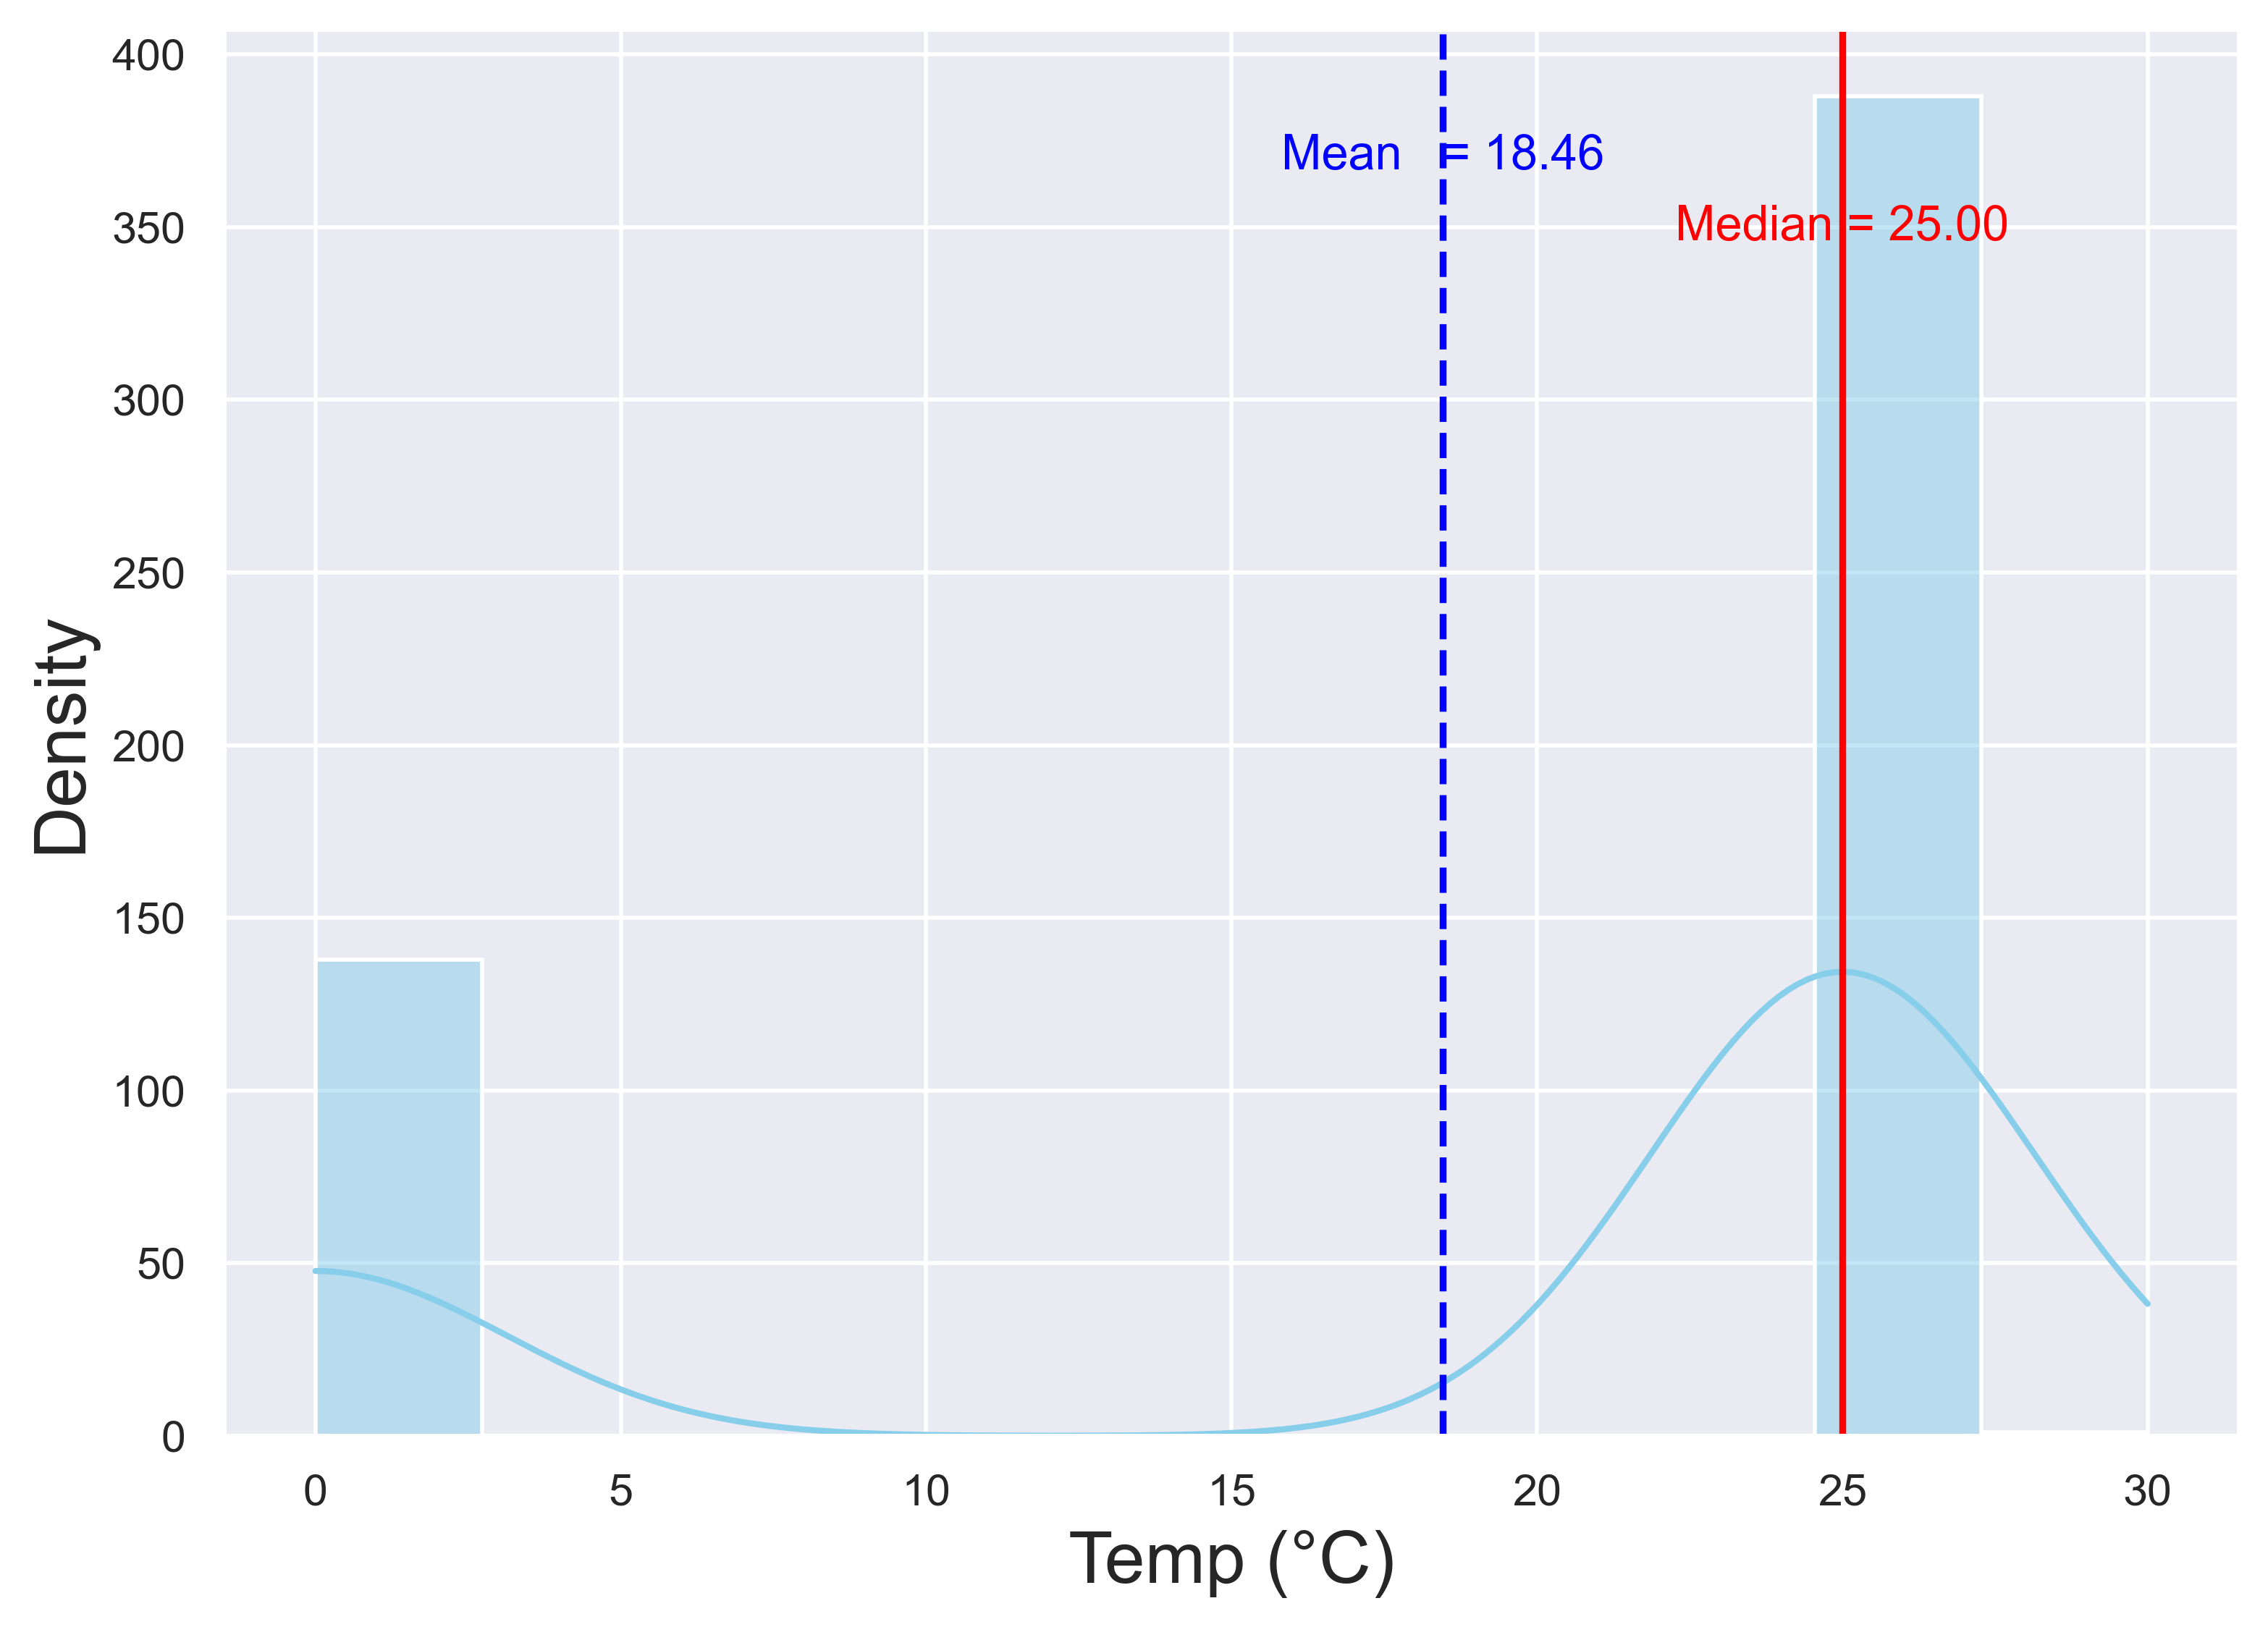

In [61]:
density_features(df, 'Temp (°C)') 

Index(['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'C (%)', 'H (%)', 'N (%)', 'O (%)', 'S (%)',
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)'],
      dtype='object')


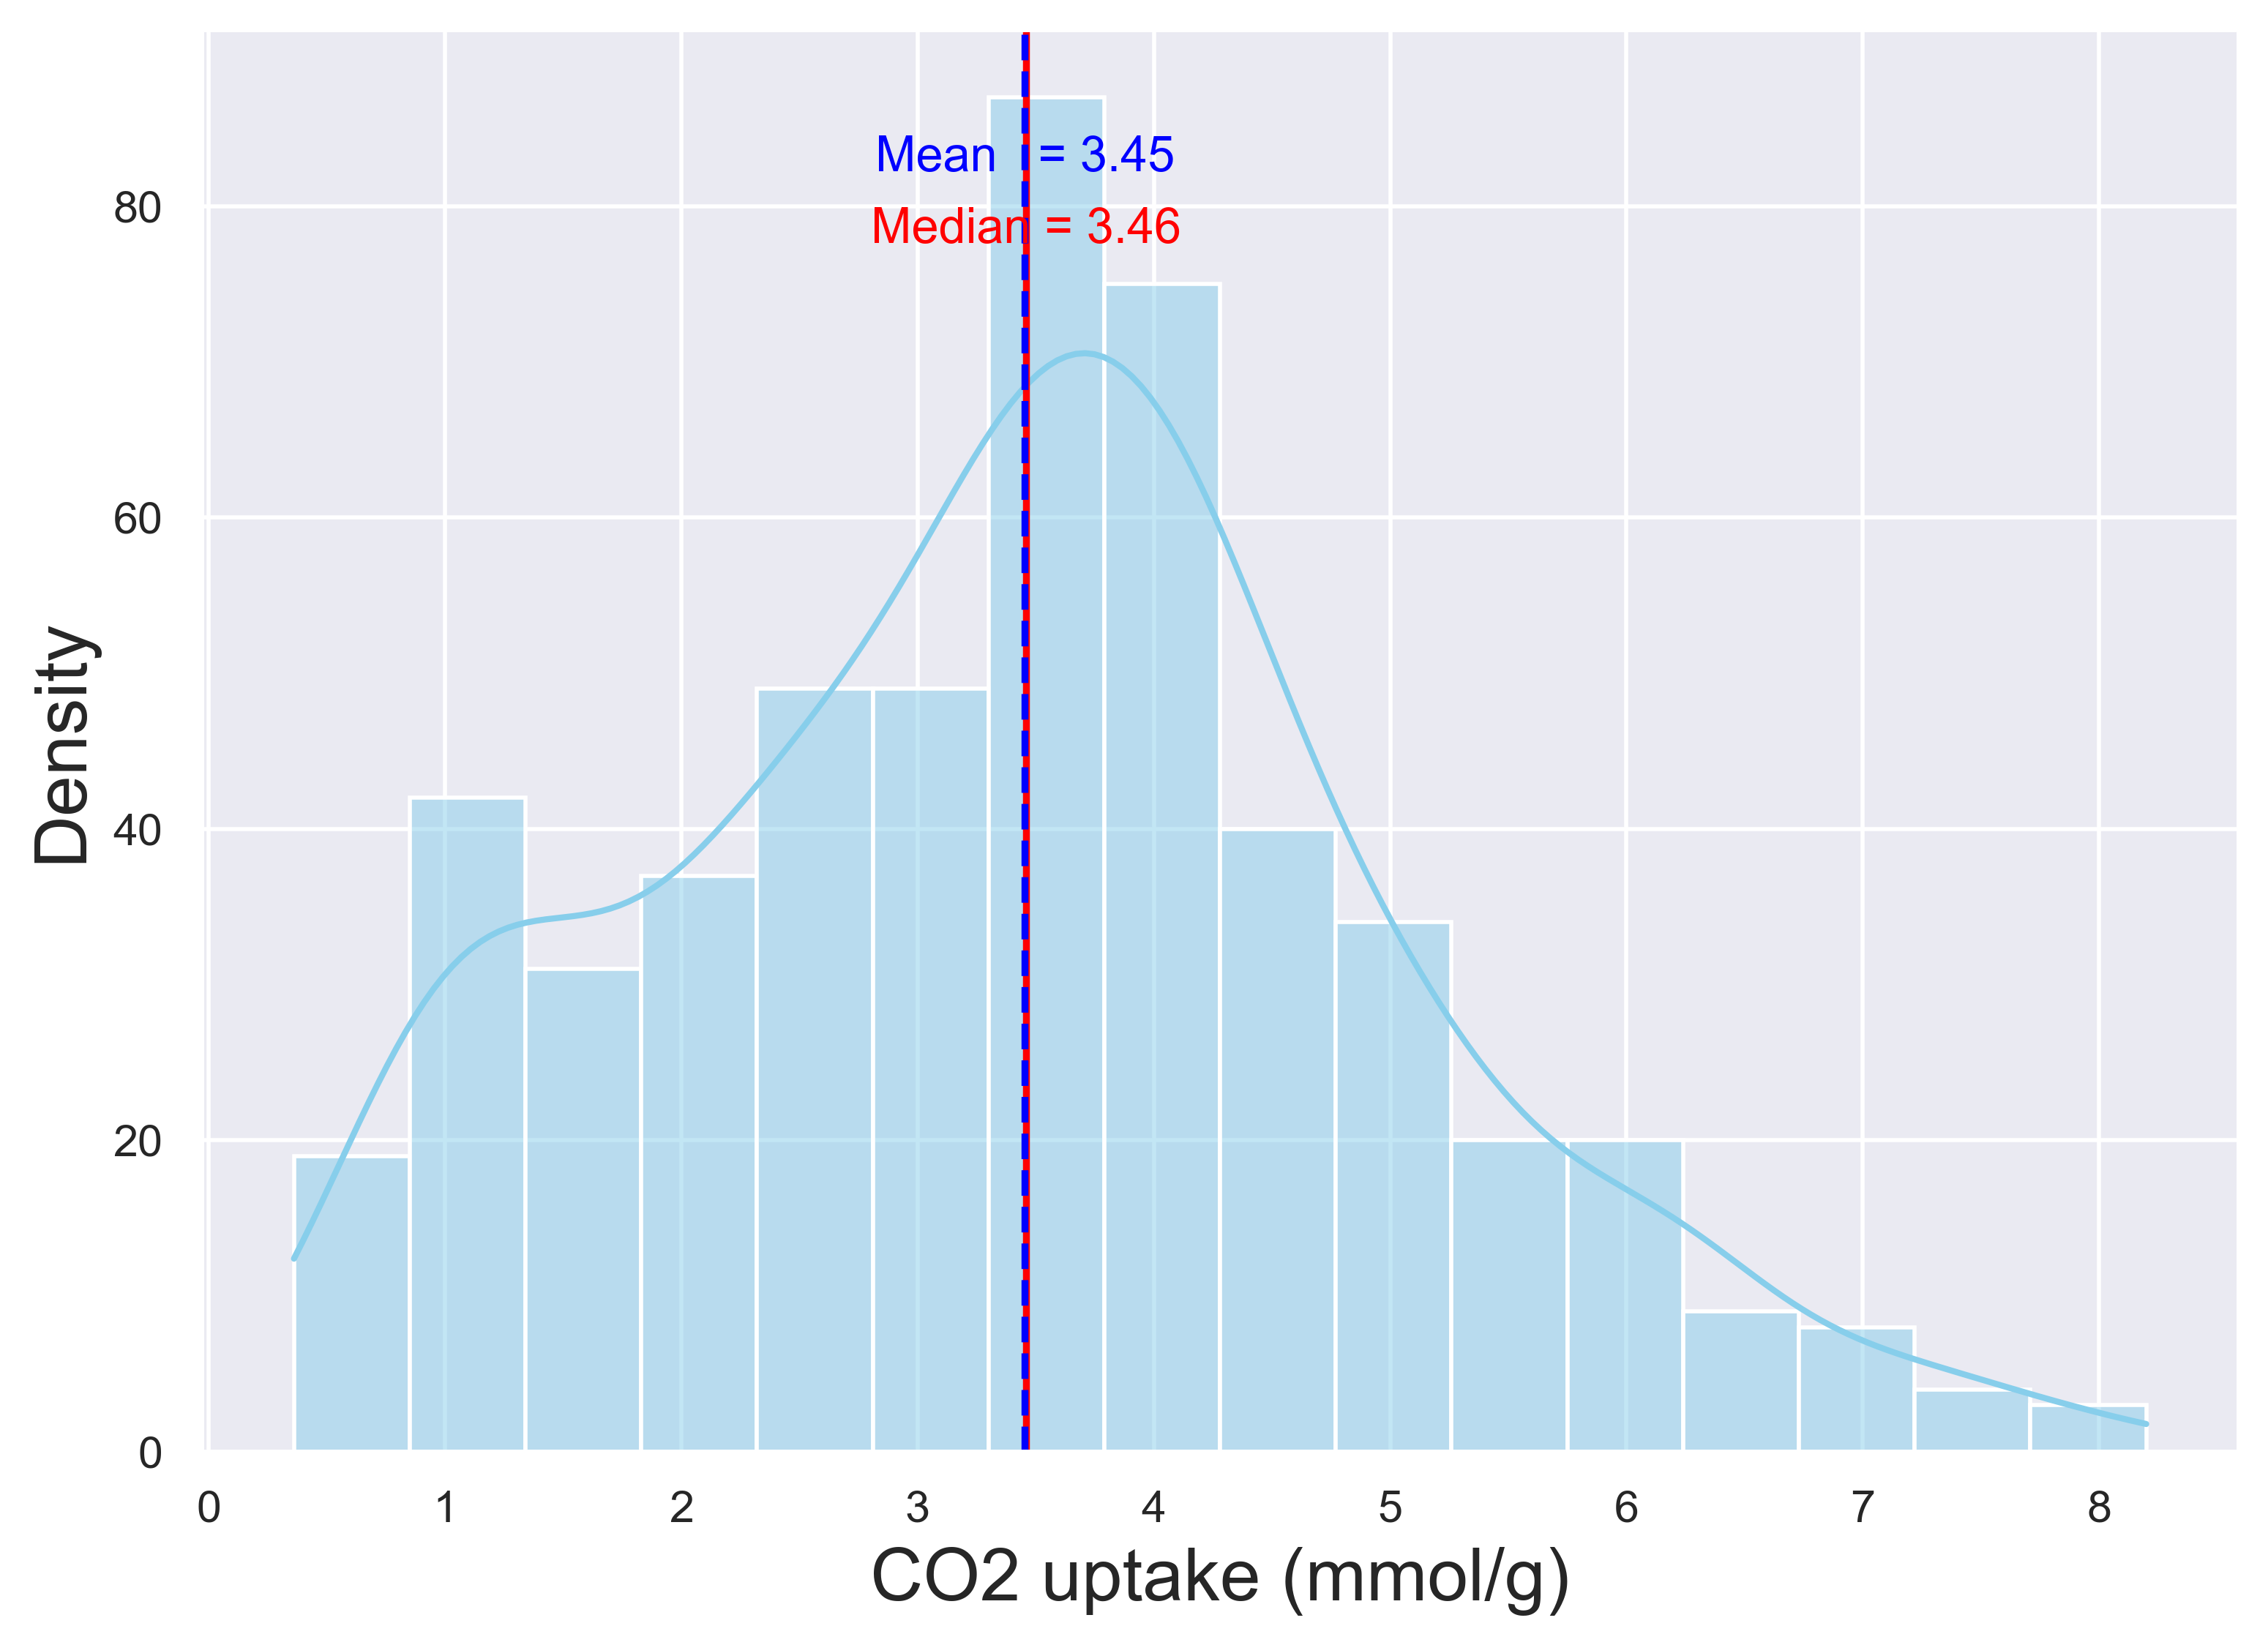

In [62]:
density_features(df, 'CO2 uptake (mmol/g)') 

Index(['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'C (%)', 'H (%)', 'N (%)', 'O (%)', 'S (%)',
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)'],
      dtype='object')


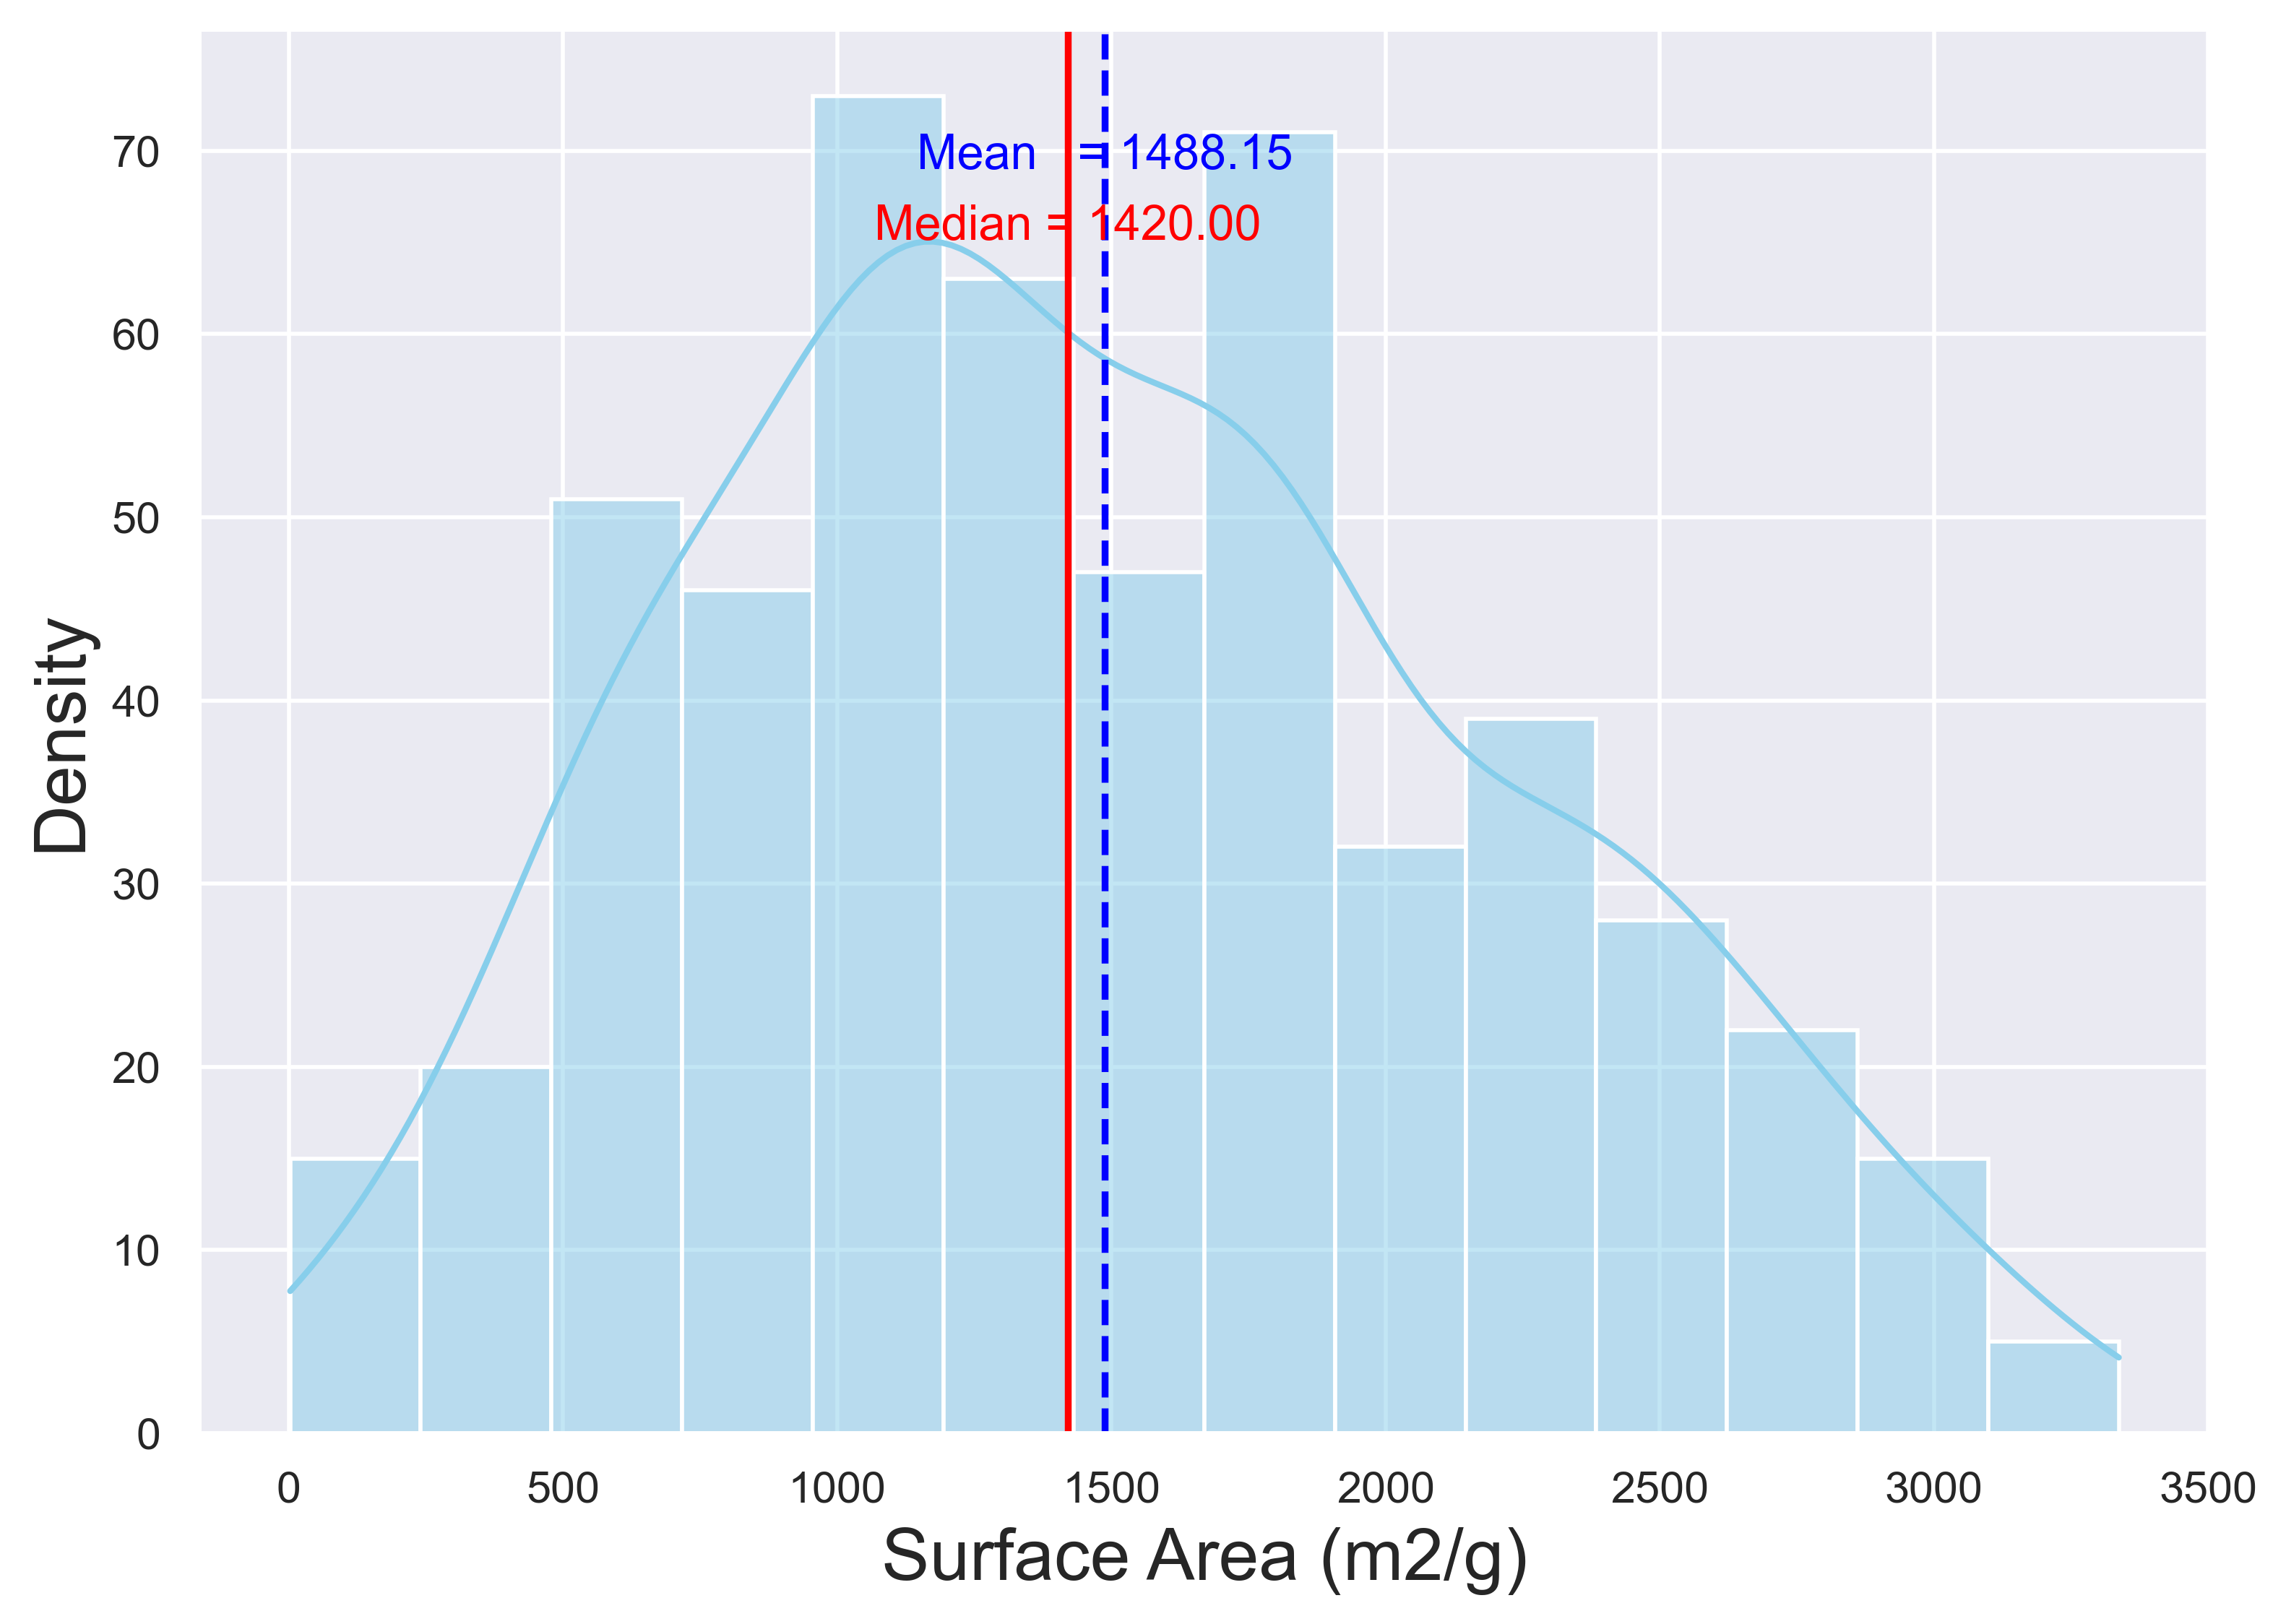

In [63]:
density_features(df, 'Surface Area (m2/g)') 

Index(['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'C (%)', 'H (%)', 'N (%)', 'O (%)', 'S (%)',
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)'],
      dtype='object')


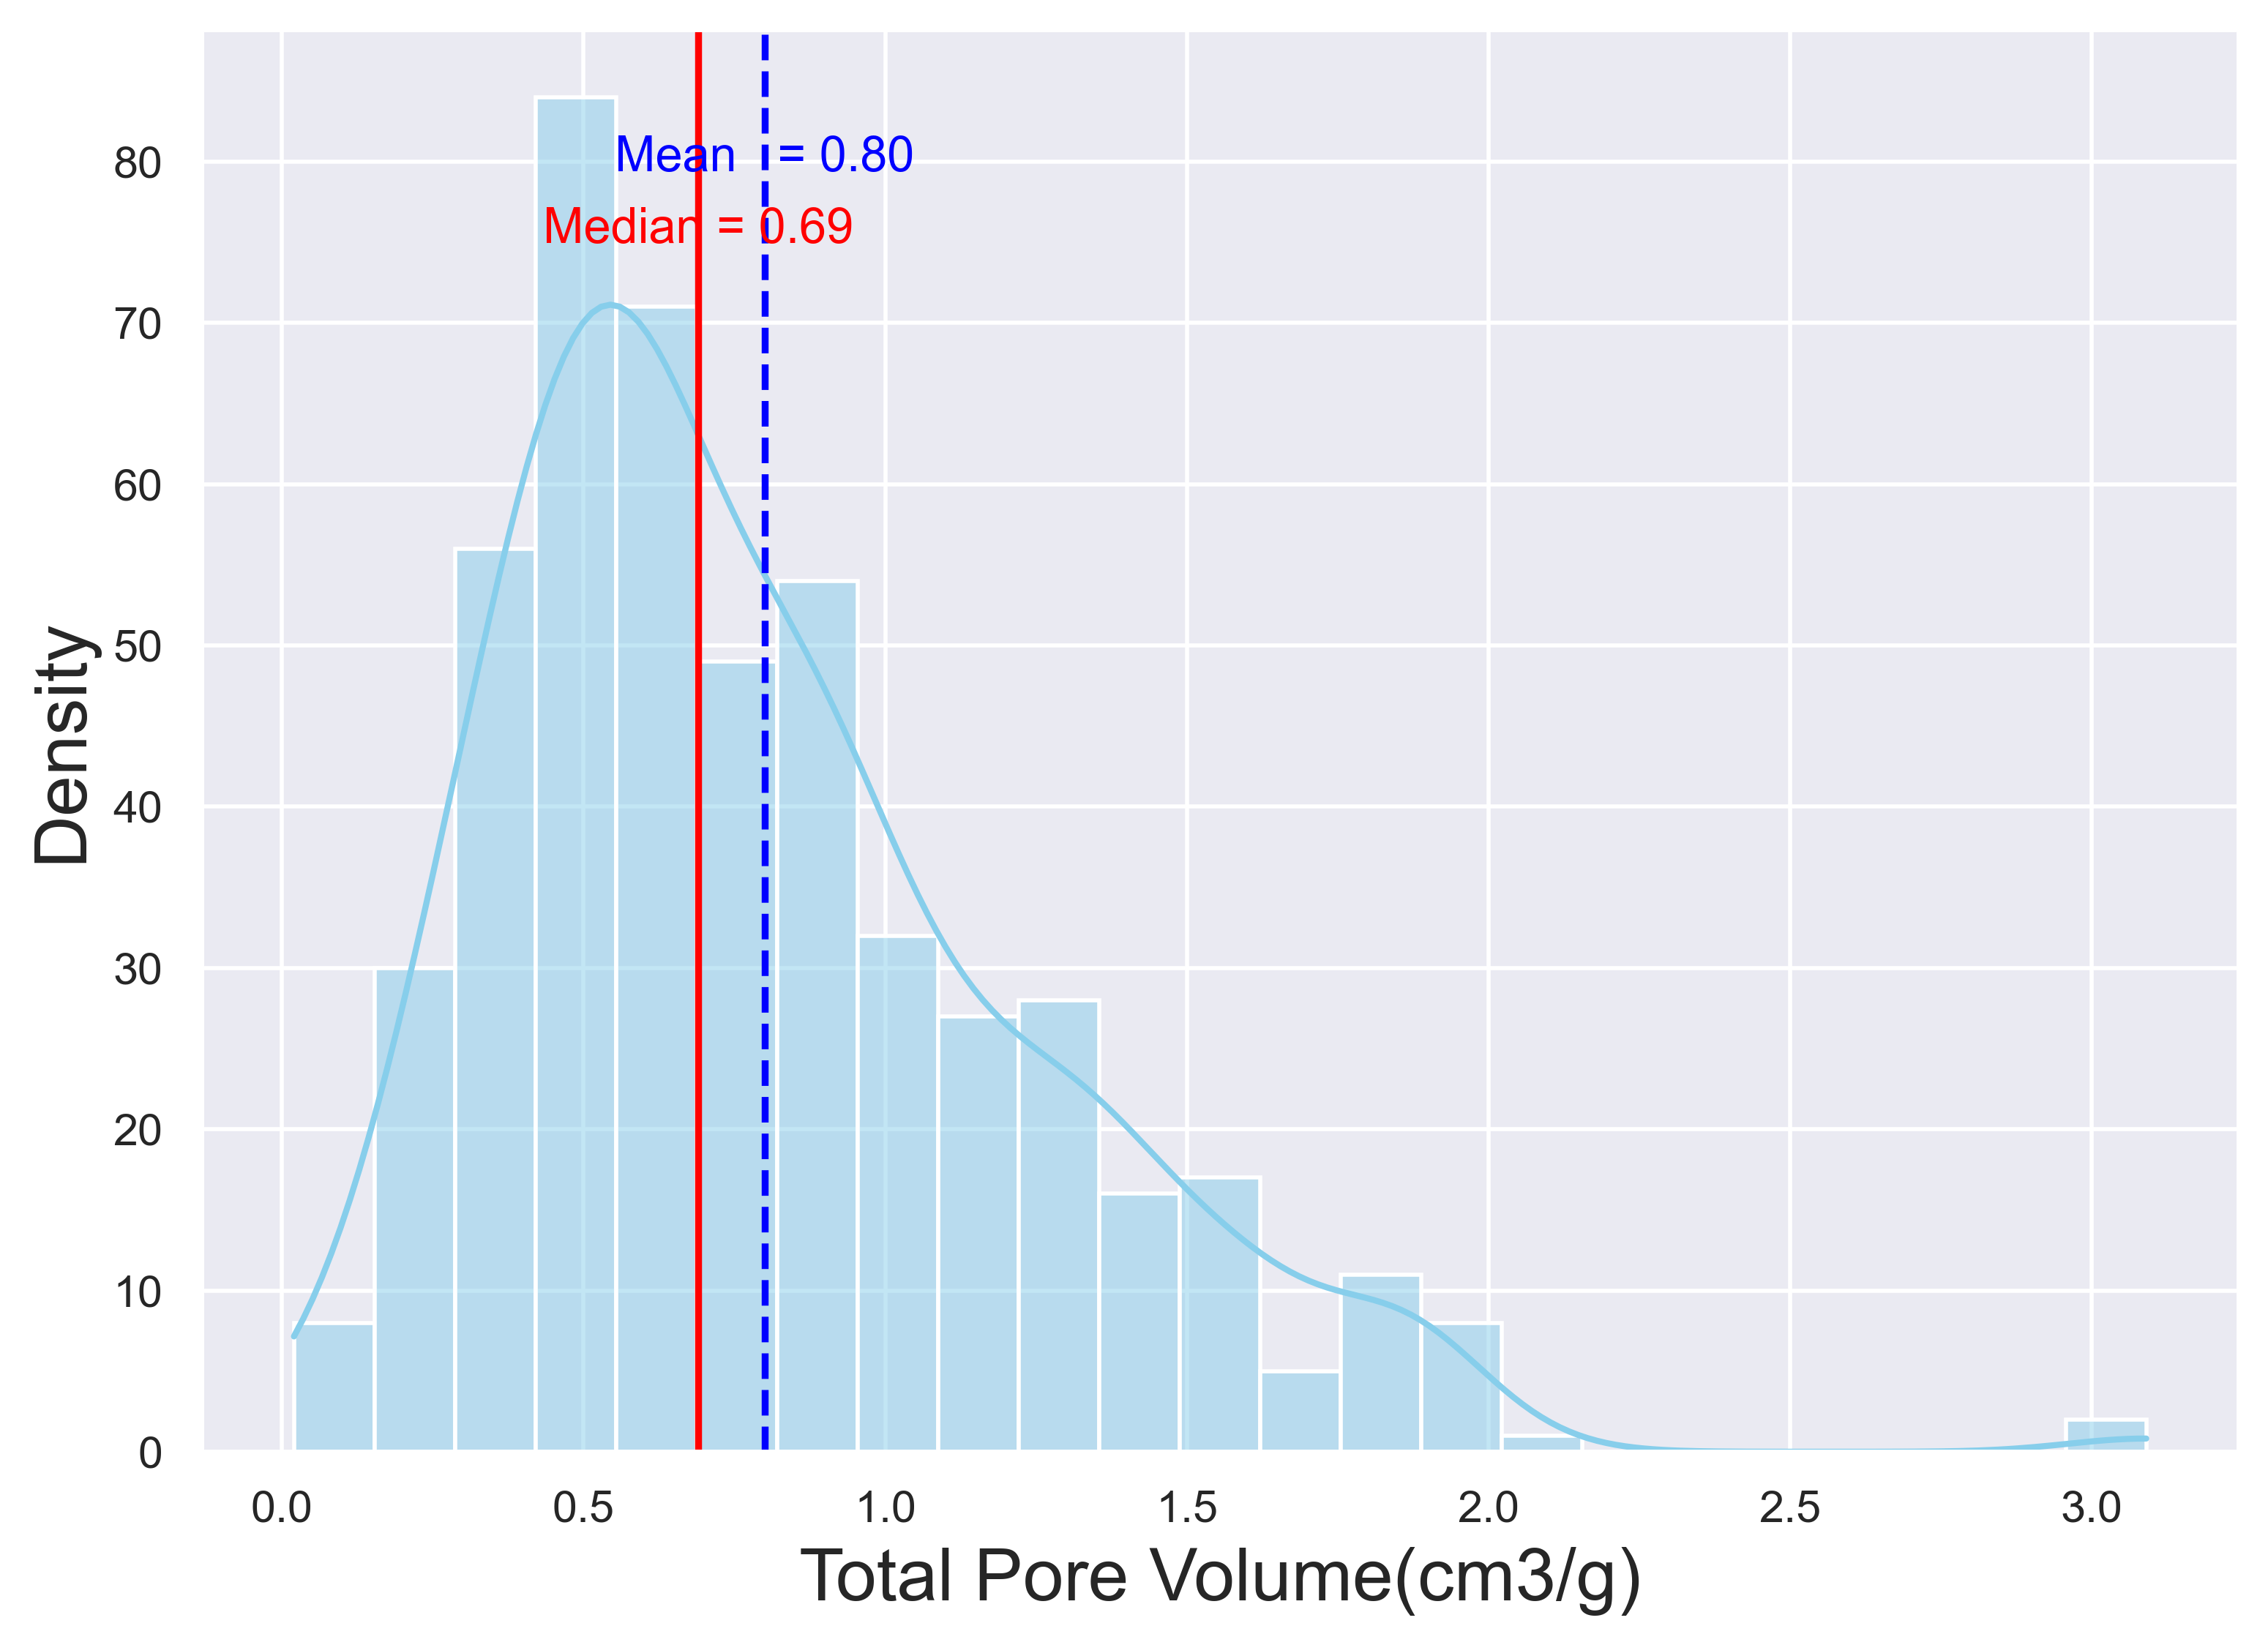

In [65]:
density_features(df, 'Total Pore Volume(cm3/g)') 

In [66]:
fig = px.violin(df, y="CO2 uptake (mmol/g)", x="Pressure (bar)", 
                color=df["Pressure (bar)"] , box=True, points="all", hover_data=['CO2 uptake (mmol/g)'])
fig.show()

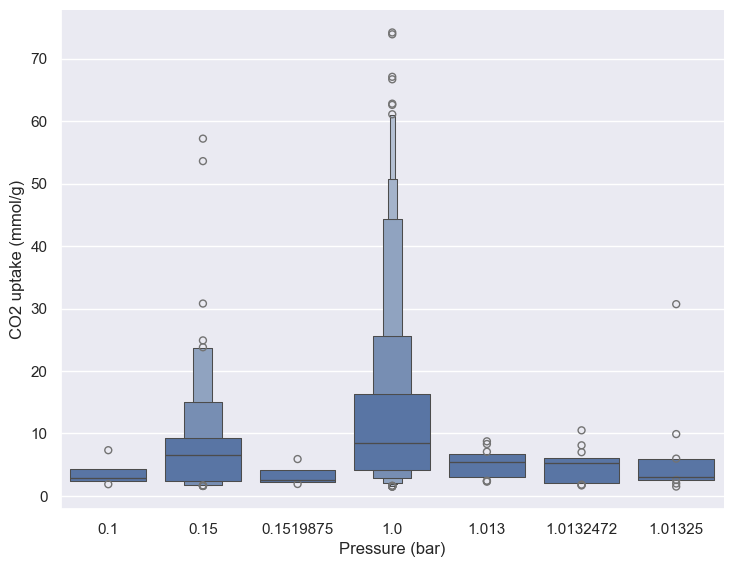

In [23]:
#plt.figure(figsize=(20,16),dpi=150)
g=sns.catplot(x="Pressure (bar)", y="CO2 uptake (mmol/g)", data=df, kind="boxen");
g.fig.set_size_inches(8,6)

In [24]:
fig = px.violin(df, y="CO2 uptake (mmol/g)", x="Temp (°C)",
                color=df["Temp (°C)"] , box=True, points="all", hover_data=['CO2 uptake (mmol/g)'])
fig.show()

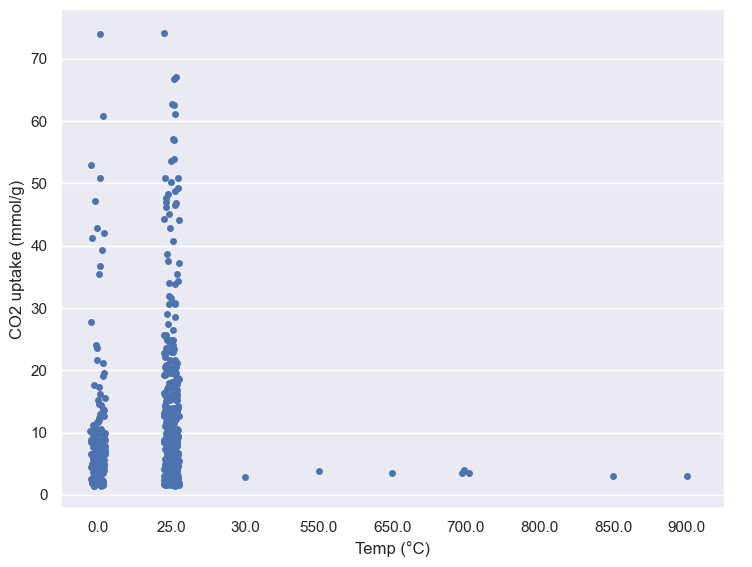

In [25]:
#plt.figure(figsize=(20,16),dpi=150)
g=sns.catplot(x="Temp (°C)", y="CO2 uptake (mmol/g)", data=df, kind="strip");
g.fig.set_size_inches(8,6)


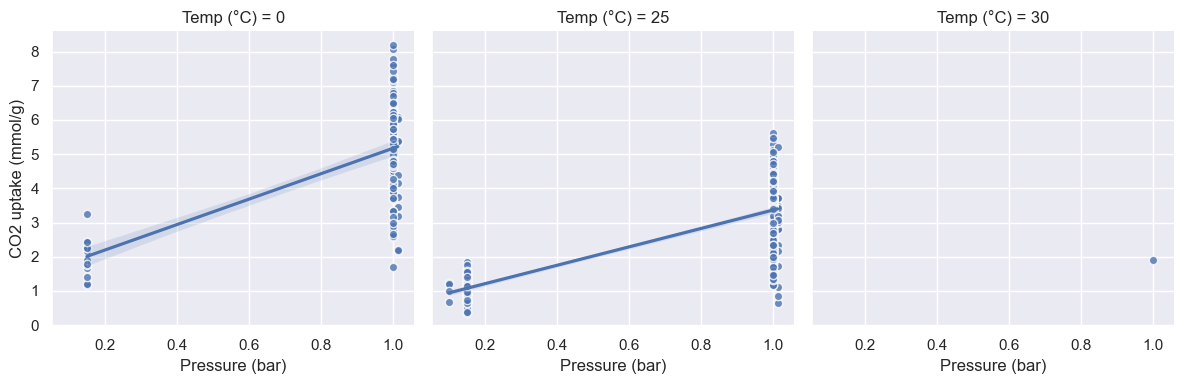

In [67]:
feature = "Pressure (bar)"

sns.lmplot(
    x=feature, y="CO2 uptake (mmol/g)", col="Temp (°C)",
    data=df, scatter_kws={"edgecolor": 'w'}, col_wrap=3, height=4,
)

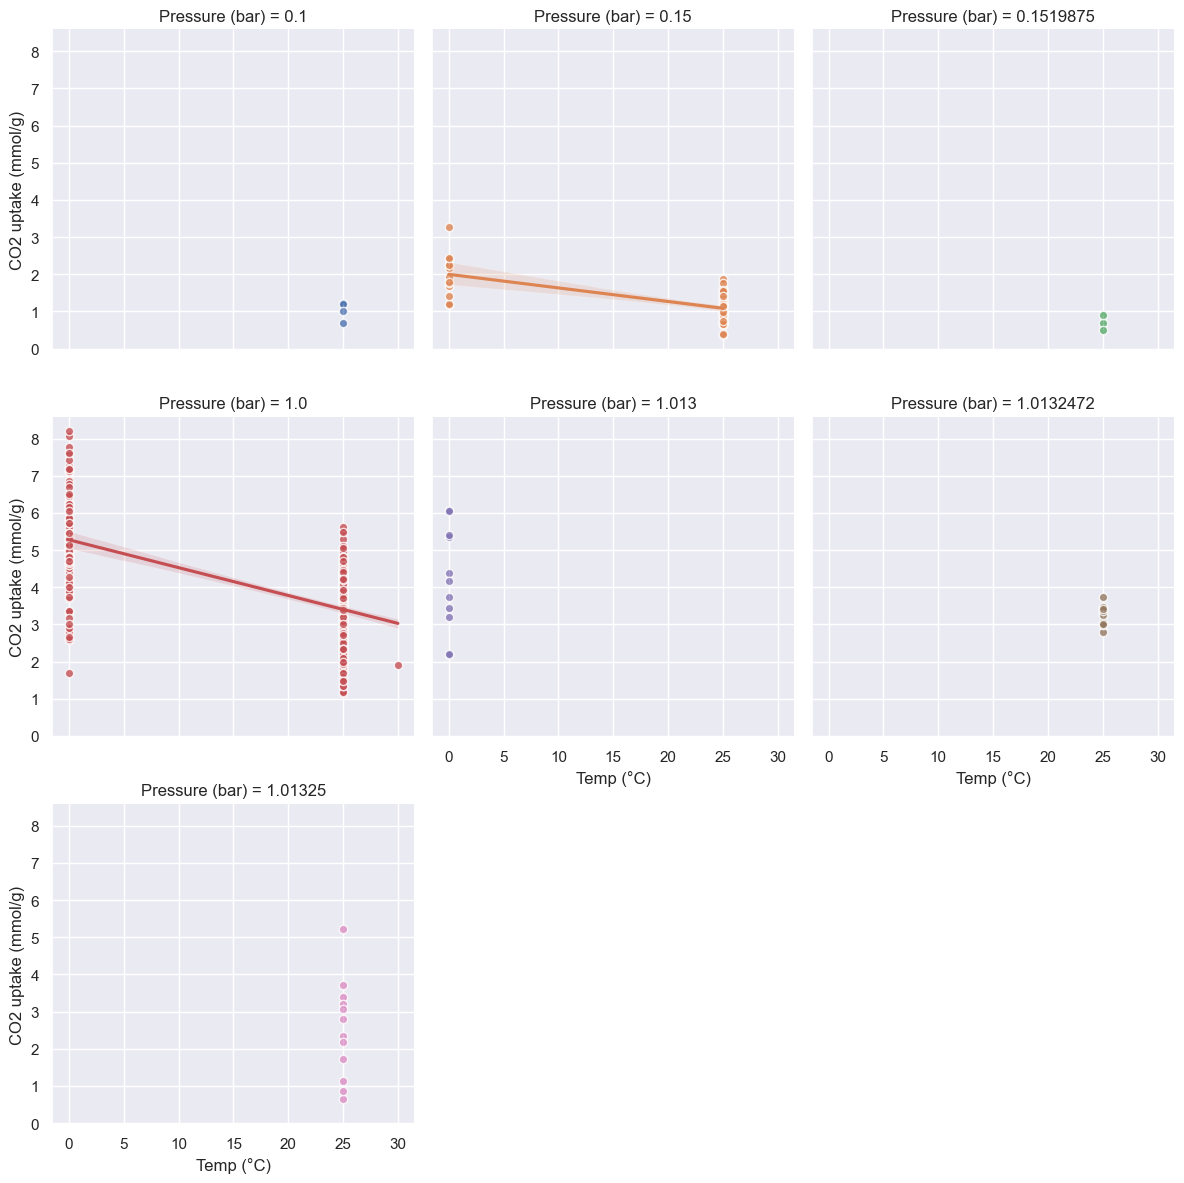

In [68]:
feature = "Temp (°C)"

sns.lmplot(
    x=feature, y="CO2 uptake (mmol/g)", hue="Pressure (bar)", col="Pressure (bar)",
    data=df, scatter_kws={"edgecolor": 'w'}, col_wrap=3, height=4,
);

In [36]:
df.columns

Index(['Materials', 'Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'Temp (°C)', 'Pressure (bar)',
       'CO2 uptake (mmol/g)', 'C-C', 'C-C (ring)', '(ring) C-C (ring)', 'C=C',
       'C-O', 'C=O', 'C-N', 'C=N', '(ring) N - N (ring)', 'N=N',
       '(ring) N=N (ring)', '(ring) C-O', '(ring) C=O', ' (ring) C-S (ring)',
       ' (ring) N-S (ring)', '(ring) C-N', 'C-N (ring)', '(ring) C=C (ring)',
       '(ring) N-C (ring)', '(ring) N=C (ring)', 'C ≡ C', 'C ≡ N', 'N - O',
       'N = O', 'O - R', 'C - R', '(ring) C - R', 'Al', 'Cd', 'Co', 'Cu', 'Mg',
       'Mn', 'Ni', 'Zn', 'Zn4O', 'Sc', 'Ti', 'Be', 'Pd', 'Y', 'Er', 'In', 'Cr',
       'Fe', 'Mo', 'Zr'],
      dtype='object')

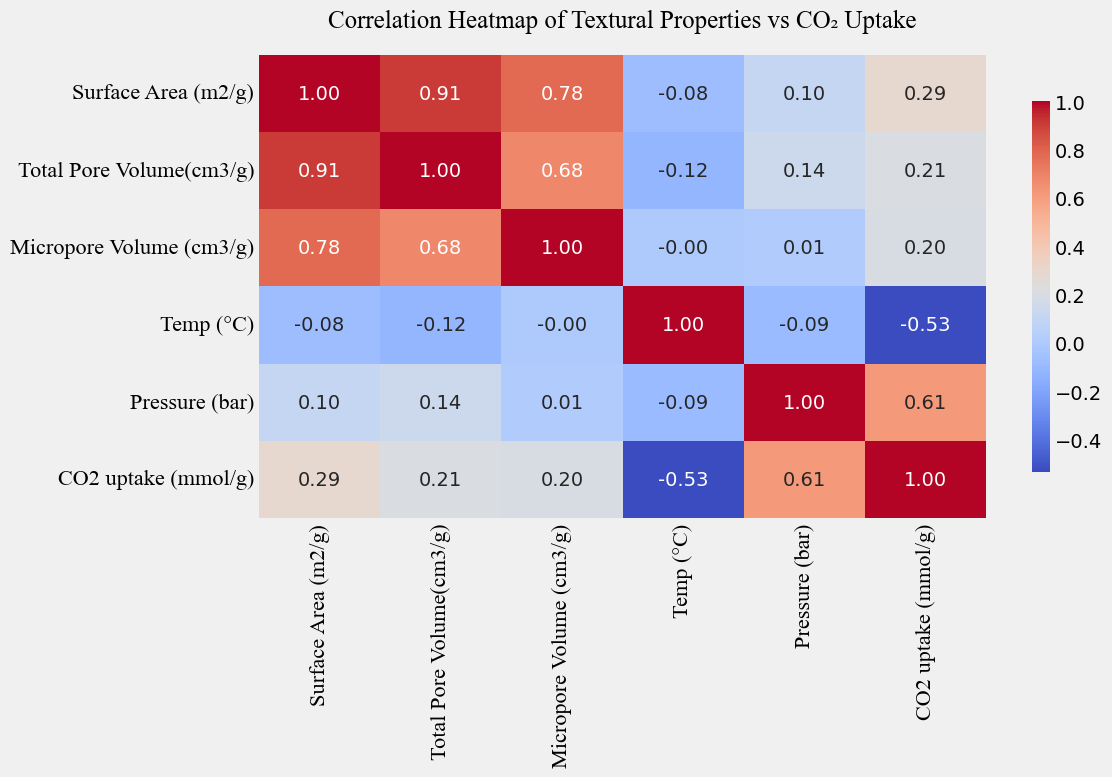

In [12]:

plt.figure(figsize=(12, 8))

corr_matrix = df[['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 
       'Temp (°C)', 'Pressure (bar)', 'CO2 uptake (mmol/g)']].corr()

sns.heatmap(corr_matrix,
            annot=True,            # show correlation values
            fmt=".2f",             # 2 decimal places
            cmap="coolwarm",       # better color contrast
            cbar_kws={'shrink': .8})

plt.xticks(rotation=90, fontsize=16, fontname="Times New Roman")
plt.yticks(rotation=0, fontsize=16, fontname="Times New Roman")

plt.title("Correlation Heatmap of Textural Properties vs CO₂ Uptake",
          fontsize=18, fontname="Times New Roman", pad=20)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Materials_encoded'] = le.fit_transform(df['Materials'])

In [37]:
df = df.drop('Materials', axis=1)

In [38]:
def skew_map(data):
    for column in data.columns:
        print(column)
        df_check = data[column].map(lambda i: np.log(i) if i > 0 else 0) 
        print(df_check.skew())
        print(df_check.skew())

In [39]:
skew_map(df)

Surface Area (m2/g)
-1.6319401568269565
-1.6319401568269565
Total Pore Volume(cm3/g)
4.196769189634062
4.196769189634062
Pore Volume (cm3/g)
-1.6203931985989475
-1.6203931985989475
Pressure (bar)
-2.1221923745245443
-2.1221923745245443
Temp (°C)
-0.17972032075362637
-0.17972032075362637
CO2 uptake (mmol/g)
0.036477823858765135
0.036477823858765135
C-C
4.134720654636515
4.134720654636515
C-C (ring)
0.0808308303941124
0.0808308303941124
(ring) C-C (ring)
-0.38868344138442457
-0.38868344138442457
C=C
11.100943309648324
11.100943309648324
C-O
-0.21951334404095132
-0.21951334404095132
C=O
-0.25687001638447254
-0.25687001638447254
C-N
4.993209132557332
4.993209132557332
C=N
12.26764502865486
12.26764502865486
(ring) N - N (ring)
4.708369366729465
4.708369366729465
N=N
0.0
0.0
(ring) N=N (ring)
5.443131131739282
5.443131131739282
(ring) C-O
3.6390849181811924
3.6390849181811924
(ring) C=O
7.267943742772361
7.267943742772361
 (ring) C-S (ring)
10.70264576957382
10.70264576957382
 (ring) N-S (r

In [73]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

Surface Area (m2/g) - Skewness: 0.29, Kurtosis: -0.59
Total Pore Volume(cm3/g) - Skewness: 1.15, Kurtosis: 2.16
Micropore Volume (cm3/g) - Skewness: 0.67, Kurtosis: -0.11
C (%) - Skewness: -0.77, Kurtosis: -0.09
H (%) - Skewness: 1.00, Kurtosis: 0.56
N (%) - Skewness: 3.21, Kurtosis: 20.46
O (%) - Skewness: 0.97, Kurtosis: 0.35
S (%) - Skewness: 12.27, Kurtosis: 157.85
Temp (°C) - Skewness: -1.08, Kurtosis: -0.82
Pressure (bar) - Skewness: -1.89, Kurtosis: 1.57
CO2 uptake (mmol/g) - Skewness: 0.26, Kurtosis: -0.16


In [11]:
df= df.replace([np.inf, -np.inf], np.nan)
df_clean = df.fillna(df.mean())

In [12]:
def P_OLS_all(df, target_column='CO2 uptake (mmol/g)'):
    import statsmodels.api as sm
    X = df.drop(target_column, axis=1)  # Drop the target column
    y = df[target_column]  # Use the target column
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())
    return model

In [13]:
target_column = 'CO2 uptake (mmol/g)'
P_OLS_all(df_clean, target_column)

                             OLS Regression Results                            
Dep. Variable:     CO2 uptake (mmol/g)   R-squared:                       0.680
Model:                             OLS   Adj. R-squared:                  0.674
Method:                  Least Squares   F-statistic:                     109.8
Date:                 Fri, 19 Sep 2025   Prob (F-statistic):          7.46e-121
Time:                         21:42:42   Log-Likelihood:                -683.85
No. Observations:                  527   AIC:                             1390.
Df Residuals:                      516   BIC:                             1437.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [85]:
def p_value_data0(df_clean): 
    X = df_clean[['Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
                   'Pressure (bar)', 'Temp (°C)']]
    y = df_clean['CO2 uptake (mmol/g)']
    lm = LinearRegression()
    lm.fit(X,y)
    params = np.append(lm.intercept_,lm.coef_)
    
    predictions = lm.predict(X)

    # newX = pd.DataFrame({"Constant":np.ones(len(X))}).join(pd.DataFrame(X))
    # MSE = (sum((y-predictions)**2))/(len(newX)-len(newX.columns))

    # Note if you don't want to use a DataFrame replace the two lines above with
    newX = np.append(np.ones((len(X),1)), X, axis=1)
    MSE = (sum((y-predictions)**2))/(len(newX)-len(newX[0]))

    var_b = MSE*(np.linalg.inv(np.dot(newX.T,newX)).diagonal())
    sd_b = np.sqrt(var_b)
    ts_b = params/ sd_b

    p_values =[2*(1-stats.t.cdf(np.abs(i),(len(newX)-len(newX[0])))) for i in ts_b]

    sd_b = np.round(sd_b,4)
    ts_b = np.round(ts_b,4)
    p_values = np.round(p_values,6)
    params = np.round(params,4)

    DF = pd.DataFrame(index=X.columns)
    DF["Coeff."],DF["std"],DF[" t_values"],DF[" P_values"] = [params[1:],sd_b[1:],ts_b[1:],p_values[1:]]

    #myDF3["features"],myDF3["Coefficients"],myDF3["Standard Errors"],myDF3["t values"],myDF3["Probabilities"] = [df_0.columns,params,sd_b,ts_b,p_values]
    return DF

In [88]:
DF=p_value_data0(df_clean)
DF

,Coeff.,std,t_values,P_values
Surface Area (m2/g),0.0010,0.0001,9.4073,0.0
Total Pore Volume(cm3/g),-1.1073,0.1743,-6.3531,0.0
Pressure (bar),2.8506,0.1283,22.2120,0.0
Temp (°C),-0.0685,0.0036,-18.9213,0.0


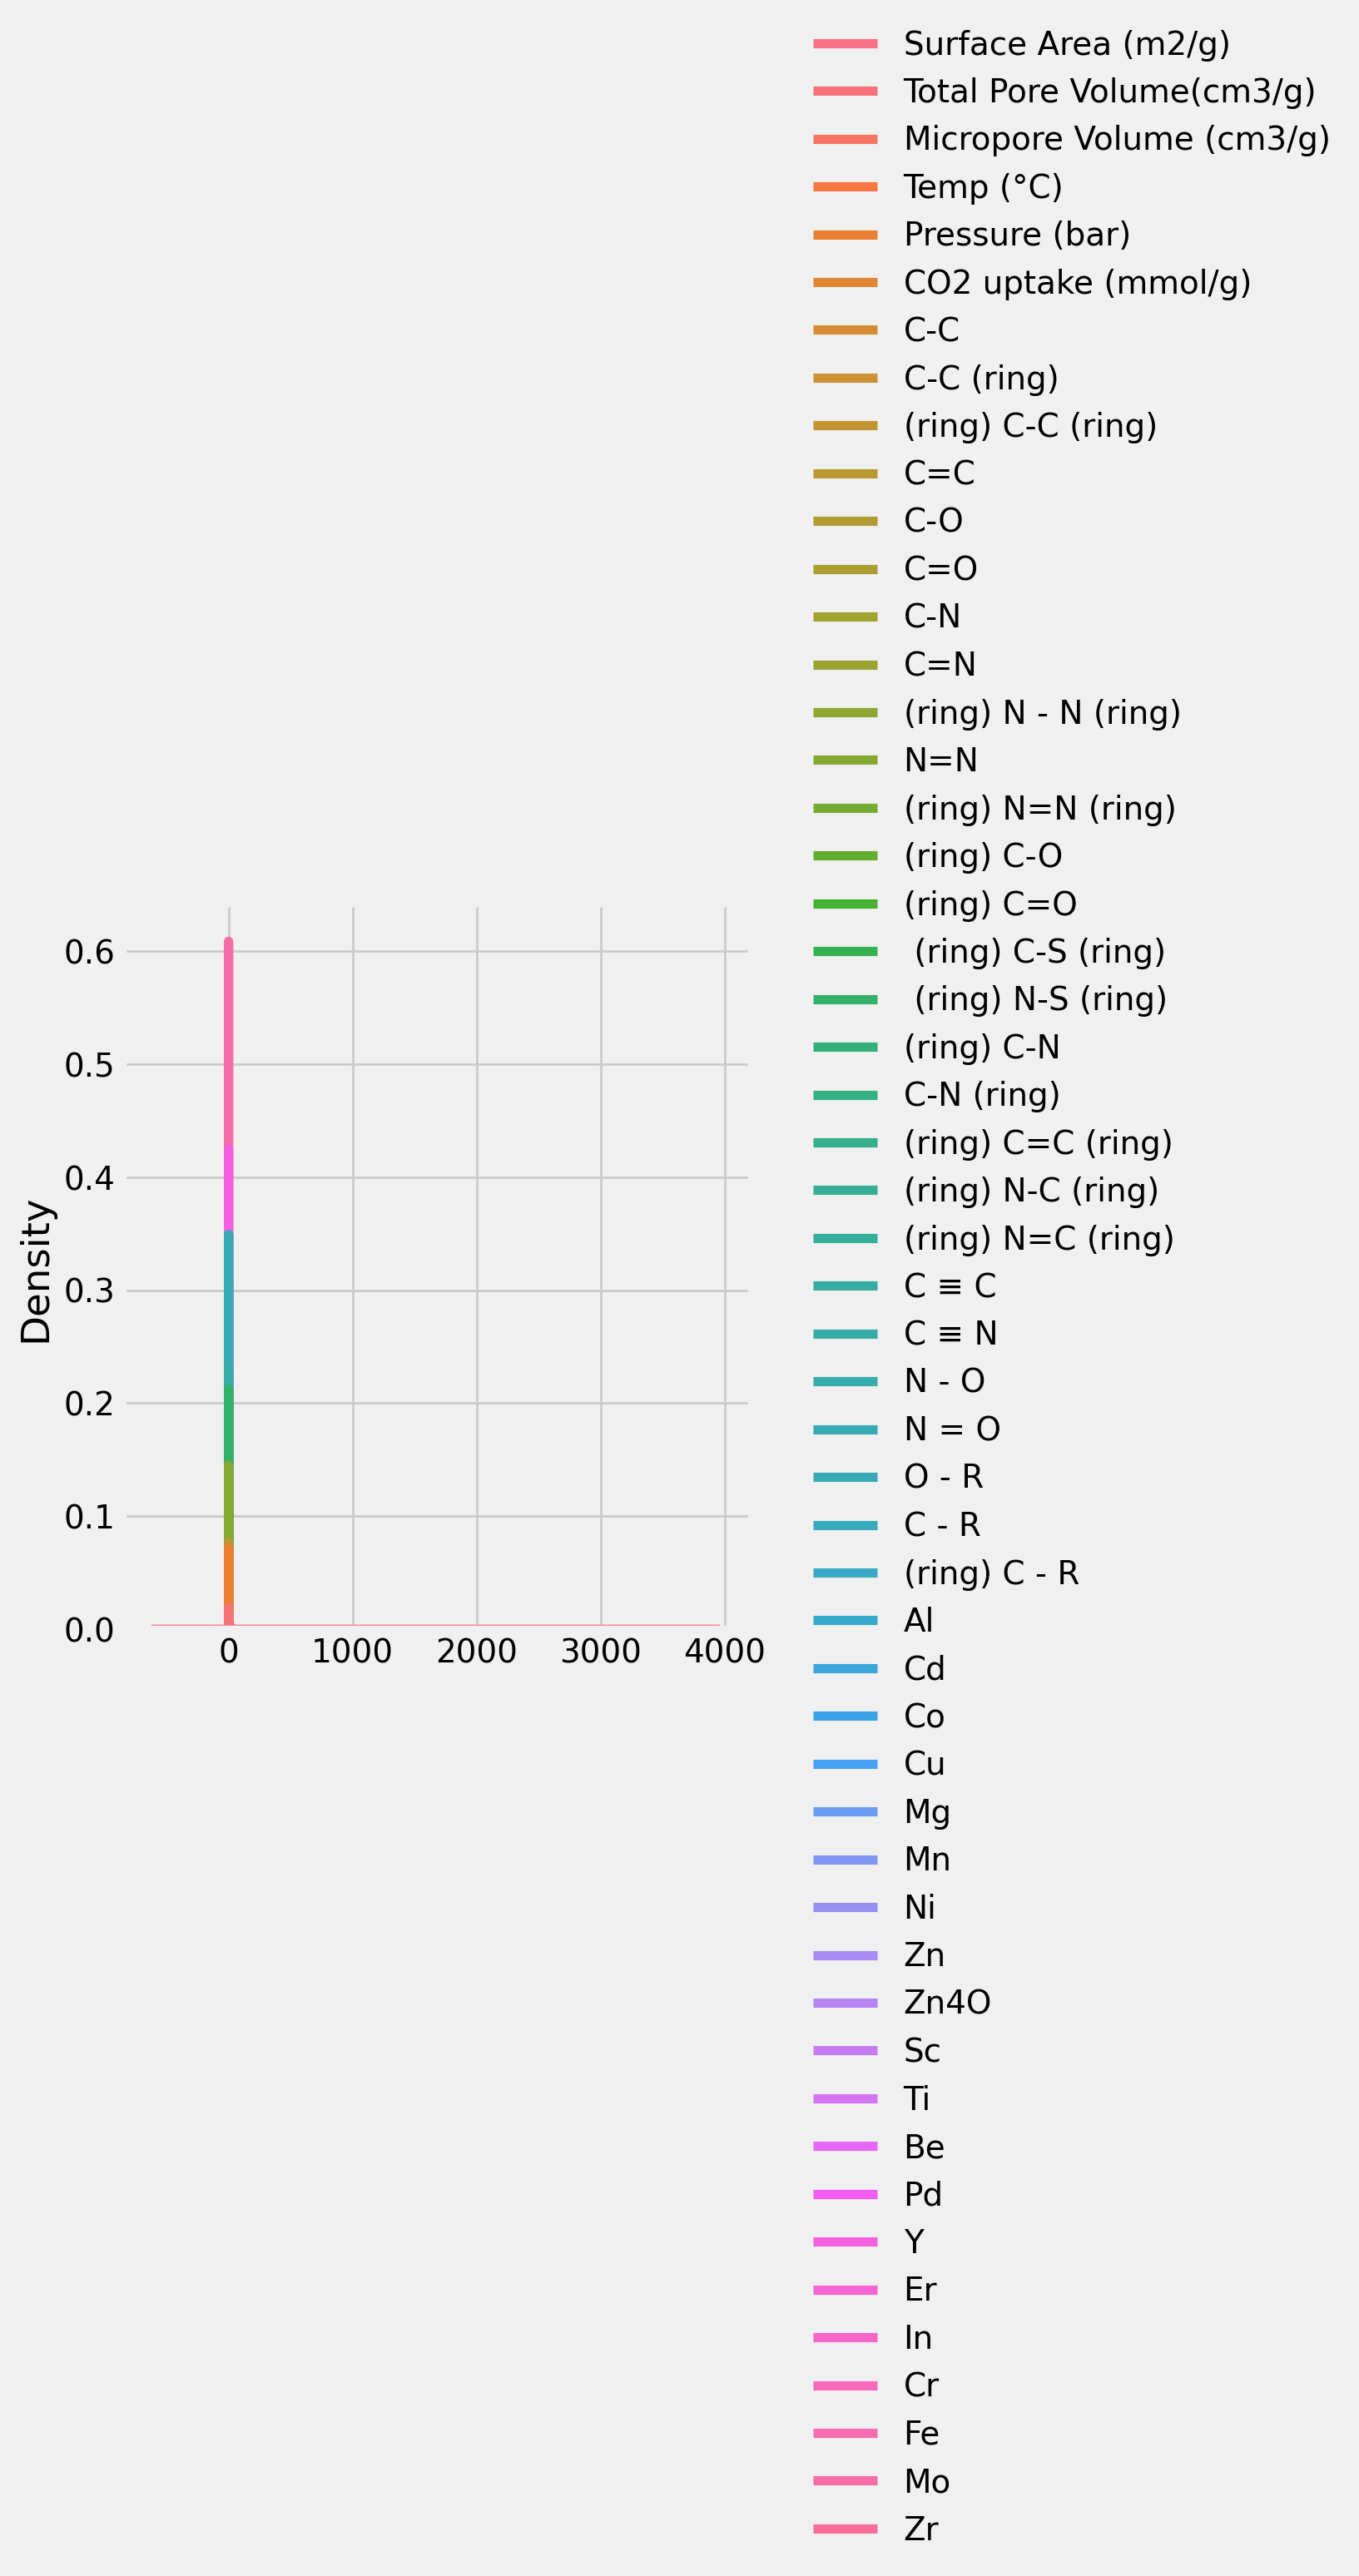

In [13]:
p=sns.displot(df, kind="kde")
p.fig.set_dpi(200)

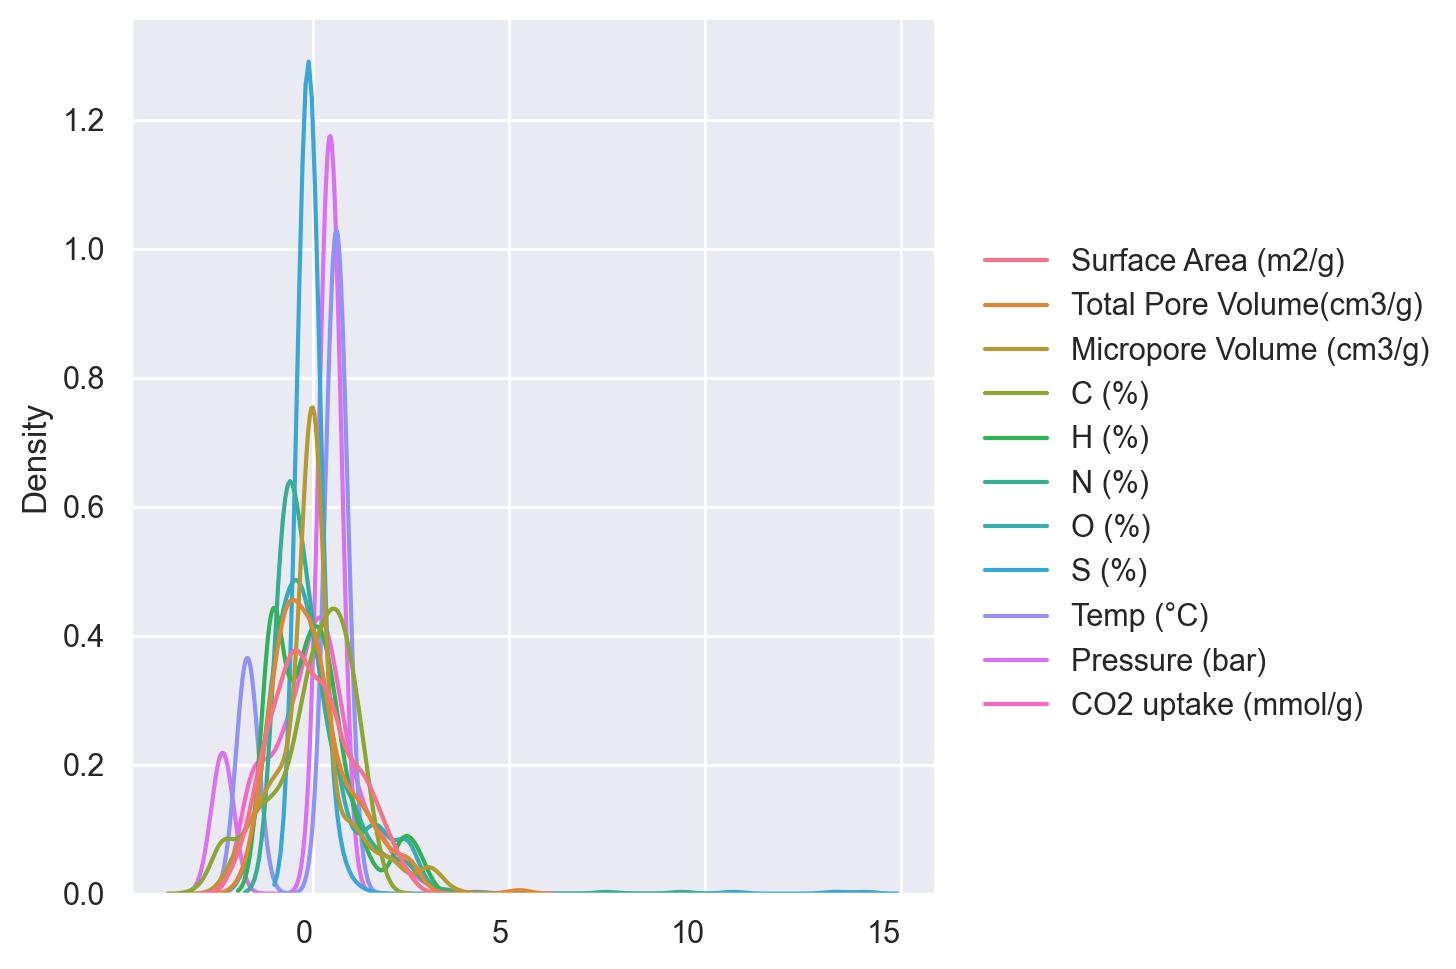

In [90]:
df_0_scaled = StandardScaler().fit_transform(df_clean)

df_0_scaled = pd.DataFrame(df_0_scaled, columns=df_clean.columns)

p_all = sns.displot(df_0_scaled, kind="kde", common_norm=False)

p_all.fig.set_dpi(200)

plt.xticks(rotation=0, ha='right')

plt.show()

## Checking correlation between features

In [91]:
def correlation_matrix(df_clean):
    corr_matrix=df_clean.corr()
    aa=corr_matrix['CO2 uptake (mmol/g)'].sort_values(ascending=False)
    print(aa[:10])
    print(aa.to_latex(index=True))

In [92]:
correlation_matrix(df_clean)

CO2 uptake (mmol/g)         1.000000
Pressure (bar)              0.614663
Surface Area (m2/g)         0.287036
Total Pore Volume(cm3/g)    0.209902
Micropore Volume (cm3/g)    0.167265
N (%)                       0.149025
H (%)                       0.021086
S (%)                       0.012142
O (%)                      -0.007235
C (%)                      -0.035484
Name: CO2 uptake (mmol/g), dtype: float64
\begin{tabular}{lr}
\toprule
 & CO2 uptake (mmol/g) \\
\midrule
CO2 uptake (mmol/g) & 1.000000 \\
Pressure (bar) & 0.614663 \\
Surface Area (m2/g) & 0.287036 \\
Total Pore Volume(cm3/g) & 0.209902 \\
Micropore Volume (cm3/g) & 0.167265 \\
N (%) & 0.149025 \\
H (%) & 0.021086 \\
S (%) & 0.012142 \\
O (%) & -0.007235 \\
C (%) & -0.035484 \\
Temp (°C) & -0.533773 \\
\bottomrule
\end{tabular}



<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> ETL, Missing Data & Outlier</p>
</div>

Missing values (fill or drop)

Duplicate rows (remove them)

Outlier detection & removal (using IQR)

Plots before/after cleaning

Ideally packaged as functions so it’s reusable for columns like CO2 uptake (mmol/g) or others.

🔍 Checking and handling missing values...
Handled missing values in 'total pore volume(cm3/g)' with strategy: mean
Handled missing values in 'micropore volume (cm3/g)' with strategy: mean

🧹 Removing duplicates...
Removed 0 duplicate rows.

📊 Detecting & removing outliers...


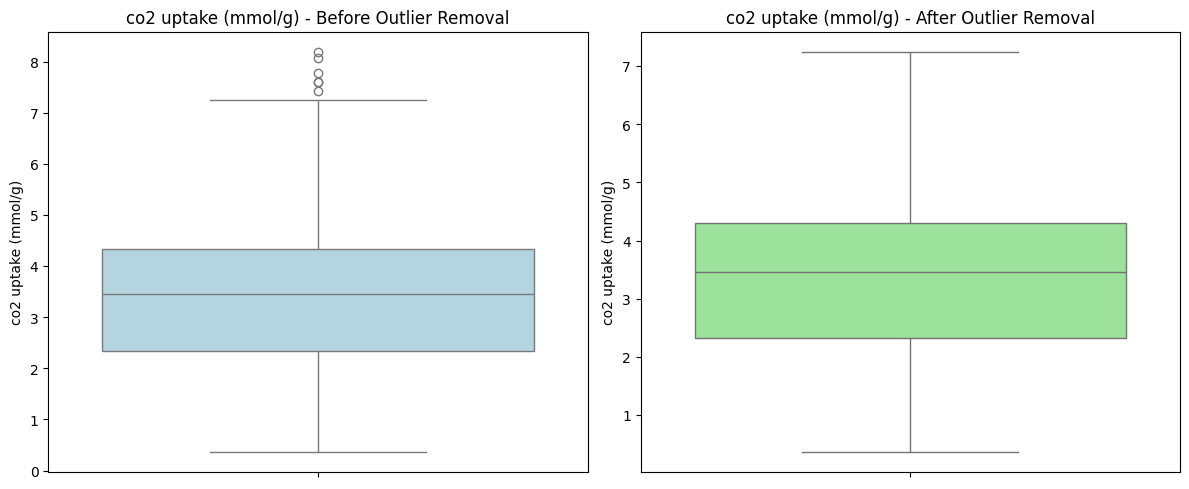

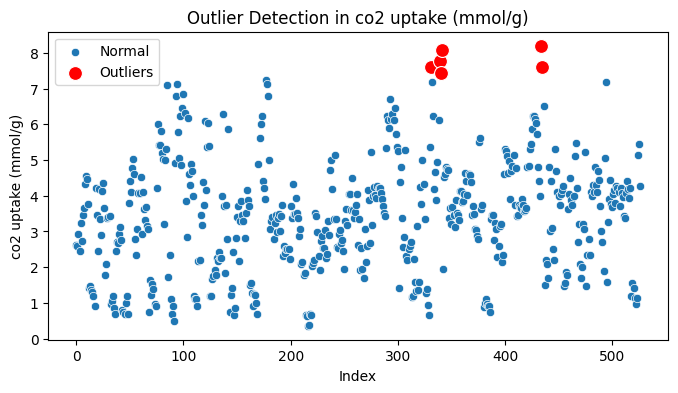

Removed 6 outliers from 'co2 uptake (mmol/g)'

✅ ETL pipeline complete.


In [4]:


# ----------------------------
# ETL Functions
# ----------------------------

def check_missing_values(df):
    """Return columns with missing values and their counts."""
    missing = df.isnull().sum()
    return missing[missing > 0]


def handle_missing_values(df, strategy="mean", drop_threshold=0.5):
    """Fill or drop missing values."""
    df_clean = df.copy()
    for col in df_clean.columns:
        missing_ratio = df_clean[col].isnull().mean()
        if missing_ratio > drop_threshold:
            df_clean = df_clean.drop(columns=[col])
            print(f"Dropped column '{col}' due to high missing ratio ({missing_ratio:.2f})")
        elif df_clean[col].isnull().any():
            if strategy == "mean" and np.issubdtype(df_clean[col].dtype, np.number):
                df_clean[col].fillna(df_clean[col].mean(), inplace=True)
            elif strategy == "median" and np.issubdtype(df_clean[col].dtype, np.number):
                df_clean[col].fillna(df_clean[col].median(), inplace=True)
            elif strategy == "mode":
                df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            elif strategy == "drop":
                df_clean.dropna(subset=[col], inplace=True)
            print(f"Handled missing values in '{col}' with strategy: {strategy}")
    return df_clean



def remove_duplicates(df):
    """Remove duplicate rows."""
    initial_shape = df.shape
    df_clean = df.drop_duplicates()
    print(f"Removed {initial_shape[0] - df_clean.shape[0]} duplicate rows.")
    return df_clean


def detect_outliers_iqr(df, column):
    """Return boolean mask of outliers using IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)


def remove_outliers(df, column, plot=True):
    """Remove outliers from a column using IQR and optionally plot before/after."""
    mask_outliers = detect_outliers_iqr(df, column)
    df_clean = df[~mask_outliers].copy()
    
    if plot:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.boxplot(y=df[column], color='lightblue')
        plt.title(f'{column} - Before Outlier Removal')
        plt.subplot(1, 2, 2)
        sns.boxplot(y=df_clean[column], color='lightgreen')
        plt.title(f'{column} - After Outlier Removal')
        plt.tight_layout()
        plt.show()
        
        # Scatterplot with outliers highlighted
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df.index, y=df[column], label="Normal")
        sns.scatterplot(x=df.index[mask_outliers], y=df[column][mask_outliers], 
                        color="red", s=100, label="Outliers")
        plt.title(f'Outlier Detection in {column}')
        plt.xlabel("Index")
        plt.ylabel(column)
        plt.legend()
        plt.show()
    
    print(f"Removed {mask_outliers.sum()} outliers from '{column}'")
    return df_clean

# ----------------------------
# Updated ETL Pipeline
# ----------------------------

def etl_pipeline(df, target_column, missing_strategy="mean", remove_cols=None):
    """
    Full ETL pipeline: missing values, duplicates, outliers, lowercase cols, remove unwanted columns.
    remove_cols: list of column names to drop
    """
    df_clean = df.copy()
    
    # Lowercase and strip column names
    df_clean.columns = [col.lower().strip() for col in df_clean.columns]
    
    # Drop unwanted columns
    if remove_cols:
        cols_to_drop = [col.lower() for col in remove_cols if col.lower() in df_clean.columns]
        df_clean = df_clean.drop(columns=cols_to_drop)
        if cols_to_drop:
            print(f"Dropped columns: {cols_to_drop}")
    
    print("🔍 Checking and handling missing values...")
    df_clean = handle_missing_values(df_clean, strategy=missing_strategy)
    
    print("\n🧹 Removing duplicates...")
    df_clean = remove_duplicates(df_clean)
    
    print("\n📊 Detecting & removing outliers...")
    df_clean = remove_outliers(df_clean, target_column.lower(), plot=True)
    
    print("\n✅ ETL pipeline complete.")
    return df_clean

# ----------------------------
# USAGE EXAMPLE
# ----------------------------

# Suppose df is your dataset
cleaned_df = etl_pipeline(
    df,
    target_column='CO2 uptake (mmol/g)',
    missing_strategy="mean",
    remove_cols=["gamma", "world"]
)


In [5]:
print(df.shape, cleaned_df.shape)
cleaned_df.describe()

(527, 54) (521, 54)


,surface area (m2/g),total pore volume(cm3/g),micropore volume (cm3/g),temp (°c),pressure (bar),co2 uptake (mmol/g),c-c,c-c (ring),(ring) c-c (ring),c=c,...,ti,be,pd,y,er,in,cr,fe,mo,zr
count,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,...,521.000000,521.000000,521.000000,521.000000,521.0,521.000000,521.000000,521.000000,521.000000,521.000000
mean,1478.990653,0.791114,0.516405,18.675624,0.865100,3.403738,0.243762,3.618042,9.583493,0.042226,...,0.005758,0.007678,0.007678,0.003839,0.0,0.015355,0.024952,0.023033,0.001919,0.053743
std,724.910688,0.423006,0.212397,10.891615,0.312657,1.505716,0.749413,2.766903,7.840798,0.331288,...,0.075736,0.087368,0.087368,0.061898,0.0,0.123079,0.156129,0.150151,0.043811,0.225726
min,2.480000,0.020000,0.040000,0.000000,0.100000,0.360000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,947.000000,0.490000,0.420000,0.000000,1.000000,2.330000,0.000000,2.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1412.000000,0.710000,0.516845,25.000000,1.000000,3.450000,0.000000,3.000000,7.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1957.000000,0.990000,0.516845,25.000000,1.000000,4.300000,0.000000,4.000000,13.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
max,3337.000000,3.090000,1.290000,30.000000,1.013250,7.250000,6.000000,18.000000,43.000000,6.000000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


## Checking for zero values

In [121]:
def zeros_check(data):
    for column_name in data.columns:
        column = data[column_name]
        count = (column == 0).sum()
        print('Count of zeros in column ', column_name, ' is : ', count)
        
zeros_check(df)

Count of zeros in column  Surface Area (m2/g)  is :  0
Count of zeros in column  Total Pore Volume(cm3/g)  is :  0
Count of zeros in column  Micropore Volume (cm3/g)  is :  0
Count of zeros in column  C (%)  is :  0
Count of zeros in column  H (%)  is :  135
Count of zeros in column  N (%)  is :  47
Count of zeros in column  O (%)  is :  10
Count of zeros in column  S (%)  is :  454
Count of zeros in column  Temp (°C)  is :  138
Count of zeros in column  Pressure (bar)  is :  0
Count of zeros in column  CO2 uptake (mmol/g)  is :  0


In [81]:
 #Separate numerical and categorical columns
num_cols = cleaned_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = cleaned_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Fill missing values
for col in num_cols:
    cleaned_df[col].fillna(cleaned_df[col].median(), inplace=True)  # Use median for robustness

for col in cat_cols:
    cleaned_df[col].fillna(cleaned_df[col].mode()[0], inplace=True)  # Fill with most frequent value

print("\nMissing Values After Cleaning:\n", cleaned_df.isnull().sum())


Missing Values After Cleaning:
 materials                   0
surface area (m2/g)         0
total pore volume(cm3/g)    0
micropore volume (cm3/g)    0
temp (°c)                   0
pressure (bar)              0
co2 uptake (mmol/g)         0
c-c                         0
c-c (ring)                  0
(ring) c-c (ring)           0
c=c                         0
c-o                         0
c=o                         0
c-n                         0
c=n                         0
(ring) n - n (ring)         0
n=n                         0
(ring) n=n (ring)           0
(ring) c-o                  0
(ring) c=o                  0
(ring) c-s (ring)           0
(ring) n-s (ring)           0
(ring) c-n                  0
c-n (ring)                  0
(ring) c=c (ring)           0
(ring) n-c (ring)           0
(ring) n=c (ring)           0
c ≡ c                       0
c ≡ n                       0
n - o                       0
n = o                       0
o - r                       0
c - r  

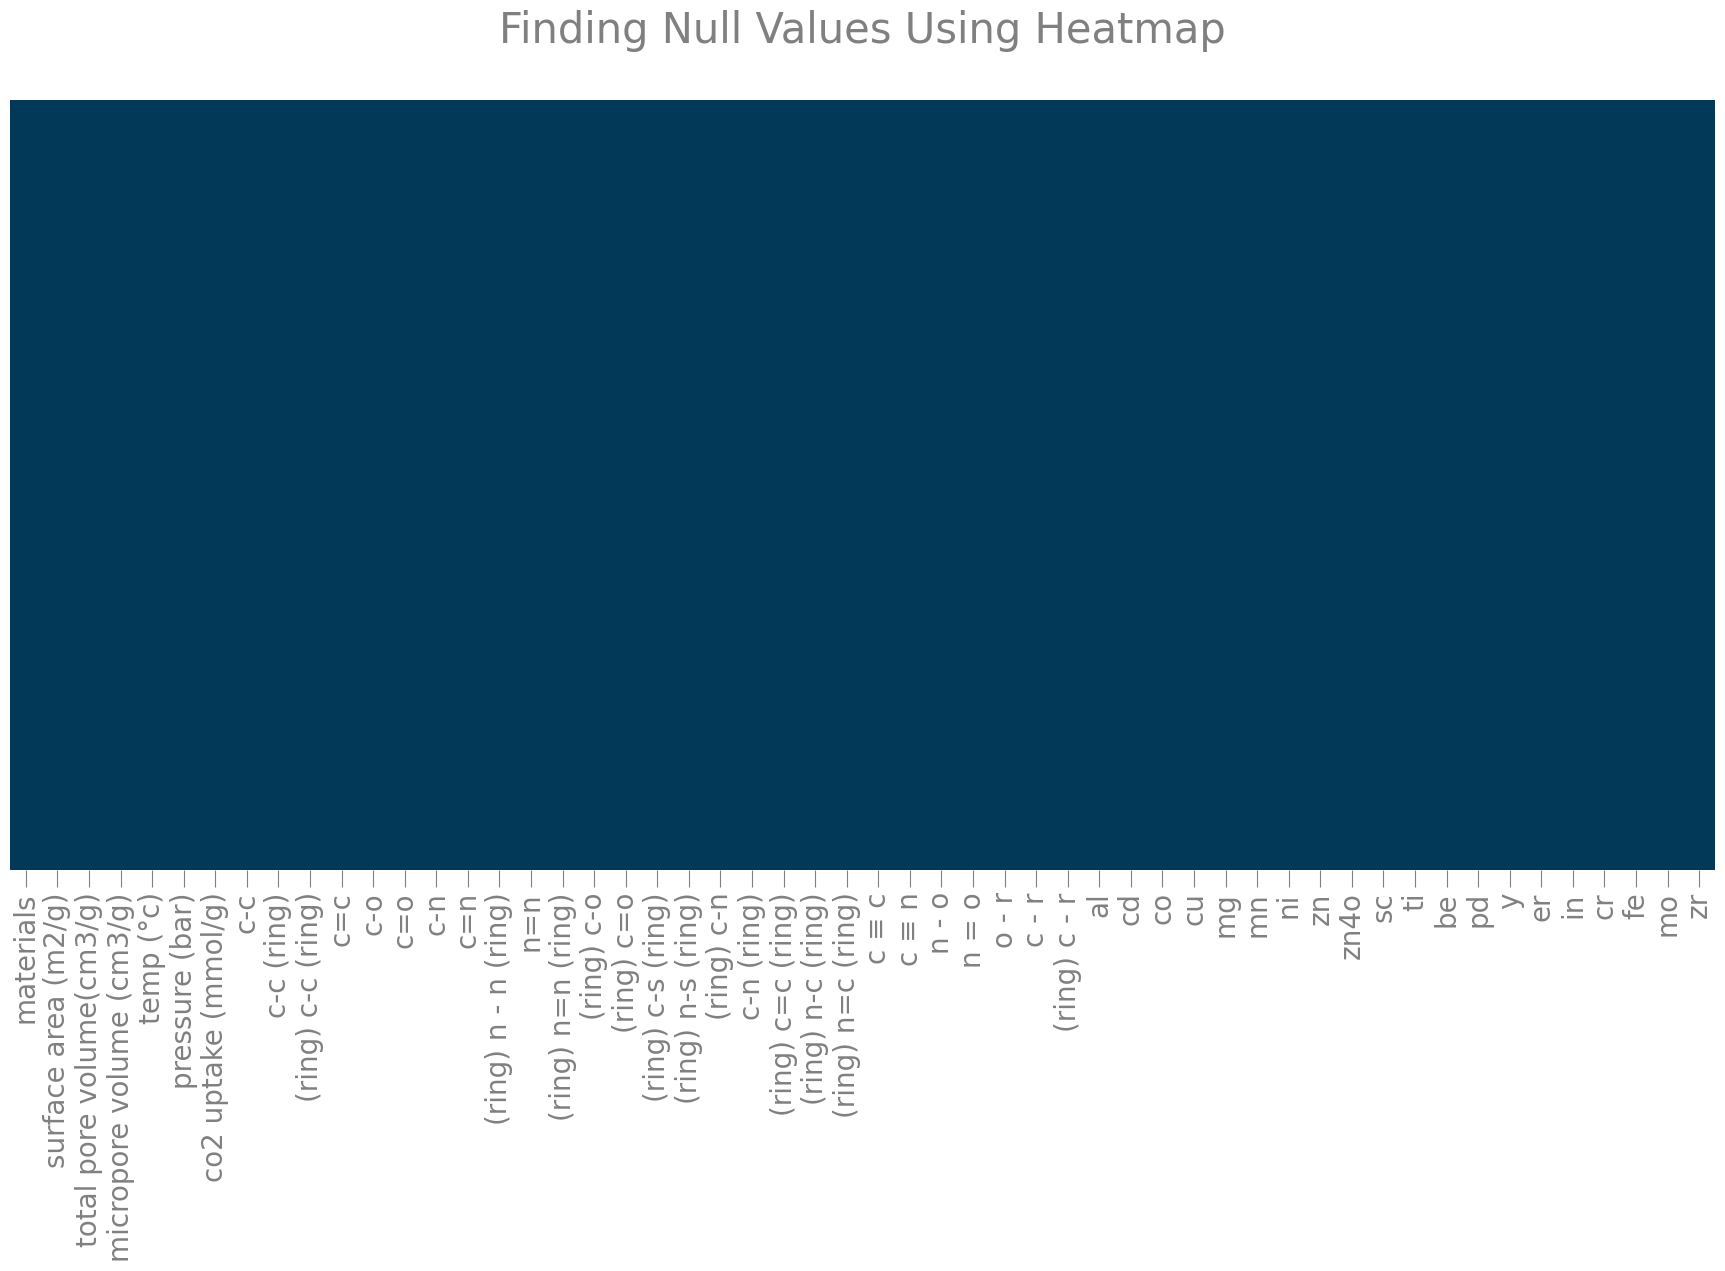

In [76]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(cleaned_df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> FUNCTION WITH ETL + SCALING</p>
</div>

In [ ]:


def preprocess_co2_data(cleaned_df, target_column, test_size=0.2, random_state=42, drop_columns=None):
    """
    Automatically:
    - Separates features (X) and target (y)
    - Detects numeric & categorical columns
    - Handles missing values
    - Applies scaling & one-hot encoding
    - Returns train/test splits and preprocessor object
    """

    # Drop irrelevant columns if provided
    if drop_columns:
        cleaned_df = cleaned_df.drop(columns=drop_columns, errors='ignore')

    # Separate X and y
    X = cleaned_df.drop(columns=[target_column])
    y = cleaned_df[target_column].values.reshape(-1, 1)

    # Replace commas with dots for numeric strings
    X = X.apply(lambda col: col.str.replace(',', '.', regex=False) if col.dtype == 'object' else col)

    # Detect column types
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convert categorical columns to string
    for col in categorical_features:
        X[col] = X[col].astype(str)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Pipelines
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()) ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))])

    # ColumnTransformer
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)])

    # Fit & transform
    X_train_p = preprocessor.fit_transform(X_train)
    X_test_p = preprocessor.transform(X_test)

    print(f"✅ Preprocessing complete. Shapes -> X_train: {X_train_p.shape}, X_test: {X_test_p.shape}")
    return X_train_p, X_test_p, y_train, y_test, preprocessor


drop_cols=[
       'materials', 
        'c-c', 'c-c (ring)', '(ring) c-c (ring)', 'c=c',
       'c-o', 'c=o', 'c-n', 'c=n', '(ring) n - n (ring)', 'n=n',
       '(ring) n=n (ring)', '(ring) c-o', '(ring) c=o', '(ring) c-s (ring)',
       '(ring) n-s (ring)', '(ring) c-n', 'c-n (ring)', '(ring) c=c (ring)',
       '(ring) n-c (ring)', '(ring) n=c (ring)', 'c ≡ c', 'c ≡ n', 'n - o',
       'n = o', 'o - r', 'c - r', '(ring) c - r', 'al', 'cd', 'co', 'cu', 'mg',
       'mn', 'ni', 'zn', 'zn4o', 'sc', 'ti', 'be', 'pd', 'y', 'er', 'in', 'cr',
       'fe', 'mo', 'zr']

In [10]:
df.columns

Index(['Materials', 'Surface Area (m2/g)', 'Total Pore Volume(cm3/g)',
       'Micropore Volume (cm3/g)', 'Temp (°C)', 'Pressure (bar)',
       'CO2 uptake (mmol/g)', 'C-C', 'C-C (ring)', '(ring) C-C (ring)', 'C=C',
       'C-O', 'C=O', 'C-N', 'C=N', '(ring) N - N (ring)', 'N=N',
       '(ring) N=N (ring)', '(ring) C-O', '(ring) C=O', ' (ring) C-S (ring)',
       ' (ring) N-S (ring)', '(ring) C-N', 'C-N (ring)', '(ring) C=C (ring)',
       '(ring) N-C (ring)', '(ring) N=C (ring)', 'C ≡ C', 'C ≡ N', 'N - O',
       'N = O', 'O - R', 'C - R', '(ring) C - R', 'Al', 'Cd', 'Co', 'Cu', 'Mg',
       'Mn', 'Ni', 'Zn', 'Zn4O', 'Sc', 'Ti', 'Be', 'Pd', 'Y', 'Er', 'In', 'Cr',
       'Fe', 'Mo', 'Zr'],
      dtype='object')

In [83]:
X_train_p, X_test_p, y_train, y_test, preprocessor = preprocess_co2_data(
    cleaned_df,
    target_column= 'co2 uptake (mmol/g)',
    drop_columns=drop_cols
)

✅ Preprocessing complete. Shapes -> X_train: (416, 5), X_test: (105, 5)


In [88]:
cleaned_df.columns

Index(['materials', 'surface area (m2/g)', 'total pore volume(cm3/g)',
       'micropore volume (cm3/g)', 'temp (°c)', 'pressure (bar)',
       'co2 uptake (mmol/g)', 'c-c', 'c-c (ring)', '(ring) c-c (ring)', 'c=c',
       'c-o', 'c=o', 'c-n', 'c=n', '(ring) n - n (ring)', 'n=n',
       '(ring) n=n (ring)', '(ring) c-o', '(ring) c=o', '(ring) c-s (ring)',
       '(ring) n-s (ring)', '(ring) c-n', 'c-n (ring)', '(ring) c=c (ring)',
       '(ring) n-c (ring)', '(ring) n=c (ring)', 'c ≡ c', 'c ≡ n', 'n - o',
       'n = o', 'o - r', 'c - r', '(ring) c - r', 'al', 'cd', 'co', 'cu', 'mg',
       'mn', 'ni', 'zn', 'zn4o', 'sc', 'ti', 'be', 'pd', 'y', 'er', 'in', 'cr',
       'fe', 'mo', 'zr'],
      dtype='object')

In [84]:
print(f"shape of x train: {X_train_p.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test_p.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (416, 5)
shape of y train: (416, 1)
shape of x test: (105, 5)
shape of y train: (105, 1)


In [87]:
cleaned_df.to_excel("preprocessor_output.xlsx", index=False)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

# ================================
# GradientBoostingRegressor
# ================================


In [ ]:
def ZF_GBoost_Regression(X_train_p, X_test_p, y_train, y_test, feature_names=None, cv=5):
 

    # 1️⃣ Build & fit model
    gboost_model = GradientBoostingRegressor(
        learning_rate=0.5,
        max_depth=2,
        n_estimators=250,
        subsample=0.9,
        random_state=42
    )
    gboost_model.fit(X_train_p, y_train.ravel())

    # 2️⃣ Predictions
    y_train_flat = y_train.ravel()
    y_test_flat  = y_test.ravel()
    y_pred_train_flat = gboost_model.predict(X_train_p)
    y_pred_test_flat  = gboost_model.predict(X_test_p)

    # 3️⃣ Metrics
    metrics_train = {
        "RMSE": np.sqrt(mean_squared_error(y_train_flat, y_pred_train_flat)),
        "MAE": mean_absolute_error(y_train_flat, y_pred_train_flat),
        "R2": r2_score(y_train_flat, y_pred_train_flat)}
    metrics_test = {
        "RMSE": np.sqrt(mean_squared_error(y_test_flat, y_pred_test_flat)),
        "MAE": mean_absolute_error(y_test_flat, y_pred_test_flat),
        "R2": r2_score(y_test_flat, y_pred_test_flat)}

    print("=== Gradient Boosting Train Metrics ===", metrics_train)
    print("=== Gradient Boosting Test Metrics ===", metrics_test)

    # 4️⃣ Bar chart of metrics
    mae_gb, rmse_gb, r2_gb = metrics_test["MAE"], metrics_test["RMSE"], metrics_test["R2"]
    mse_gb = mean_squared_error(y_test_flat, y_pred_test_flat)
    gb_metrics = pd.DataFrame(
        [mae_gb, mse_gb, rmse_gb, r2_gb * 100],
        index=['MAE', 'MSE', 'RMSE', 'R2 (%)'],
        columns=['Gradient Boosting']
    )
    print("--------------------------")
    print(gb_metrics)
    print("--------------------------")

    plt.figure(figsize=(8, 5))
    bars = plt.bar(['MAE', 'MSE', 'R² (%)', 'RMSE'],
                   [mae_gb, mse_gb, r2_gb*100, rmse_gb],
                   color='#1f77b4')
    plt.title('Gradient Boost Regression - Evaluation Metrics', pad=20)
    plt.ylabel('Score')
    plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [mae_gb, mse_gb, r2_gb*100, rmse_gb]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=11)
    plt.show()

    # 5️⃣ Cross-validation
    scoring = {'MSE': 'neg_mean_squared_error', 'R2': 'r2'}
    cv_results = cross_validate(gboost_model, X_train_p, y_train.ravel(), cv=cv, scoring=scoring)
    print(f"{cv}-Fold CV Mean MSE: {-cv_results['test_MSE'].mean():.4f}")
    print(f"{cv}-Fold CV Mean R²: {cv_results['test_R2'].mean():.4f}")

    # 6️⃣ Permutation Feature Importance
    perm_res = permutation_importance(gboost_model, X_train_p, y_train.ravel())
    sorted_idx = perm_res.importances_mean.argsort()
    if feature_names is not None:
        plt.figure(figsize=(8,6))
        plt.barh(range(len(sorted_idx)), perm_res.importances_mean[sorted_idx])
        plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
        plt.xlabel("Permutation Importance")
        plt.title("Feature Importance")
        plt.show()

    # 7️⃣ Partial Dependence Plot (Top 2 features)
    importances = gboost_model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    top_features = sorted_idx[:2]
    if feature_names is not None:
        fig, ax = plt.subplots(figsize=(8,5))
        PartialDependenceDisplay.from_estimator(
            gboost_model, X_train_p, features=top_features,
            feature_names=feature_names, ax=ax
        )
        ax.set_title("Partial Dependence Plot (Top 2 Features)")
        plt.show()

    # 8️⃣ Residual Plot
    plt.figure(figsize=(6,5))
    plt.scatter(y_pred_test_flat, y_test_flat - y_pred_test_flat, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (Gradient Boosting)")
    plt.show()

    # 9️⃣ Predicted vs Actual
    plt.figure(figsize=(8,6))
    x_ax = range(len(y_test_flat))
    plt.scatter(x_ax, y_test_flat, s=5, color="blue", label="Actual")
    plt.plot(x_ax, y_pred_test_flat, lw=0.8, color="red", label="Predicted")
    plt.legend()
    plt.xlabel("Sample")
    plt.ylabel("CO$_2$ Adsorbed (mmol/g)")
    plt.title("Gradient Boosting: Actual vs Predicted")
    plt.show()

    # 10️⃣ Error Distribution
    errors = y_test_flat - y_pred_test_flat
    plt.figure(figsize=(8, 5))
    plt.hist(errors, bins=30, alpha=0.7, edgecolor='black')
    plt.title("Prediction Errors Distribution")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.show()

    return gboost_model, metrics_train, metrics_test, cv_results, perm_res


=== Gradient Boosting Train Metrics === {'RMSE': 0.2162844249210592, 'MAE': 0.16099983474743967, 'R2': 0.9788848872974858}
=== Gradient Boosting Test Metrics === {'RMSE': 0.6896723960031714, 'MAE': 0.5128428362413265, 'R2': 0.8023723504681508}
--------------------------
        Gradient Boosting
MAE              0.512843
MSE              0.475648
RMSE             0.689672
R2 (%)          80.237235
--------------------------


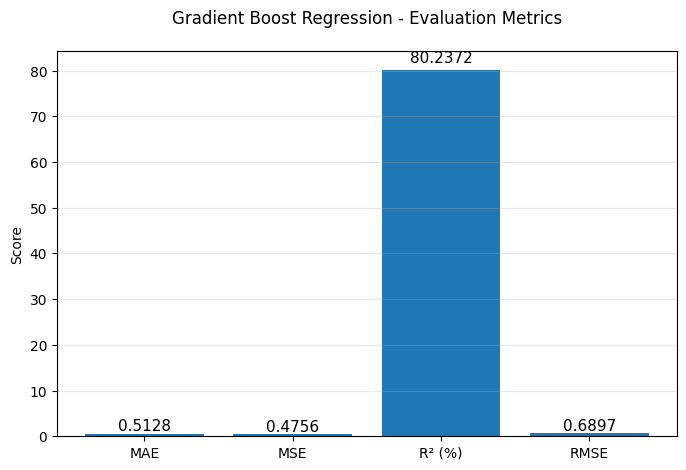

5-Fold CV Mean MSE: 0.5856
5-Fold CV Mean R²: 0.7307


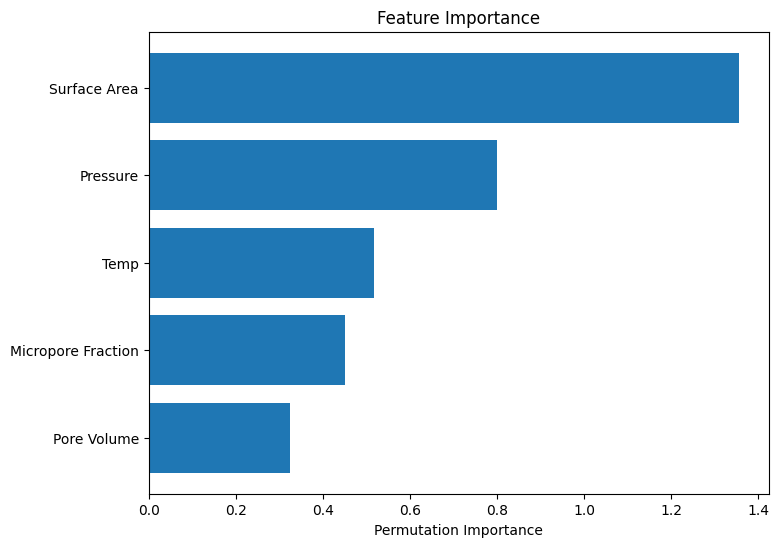

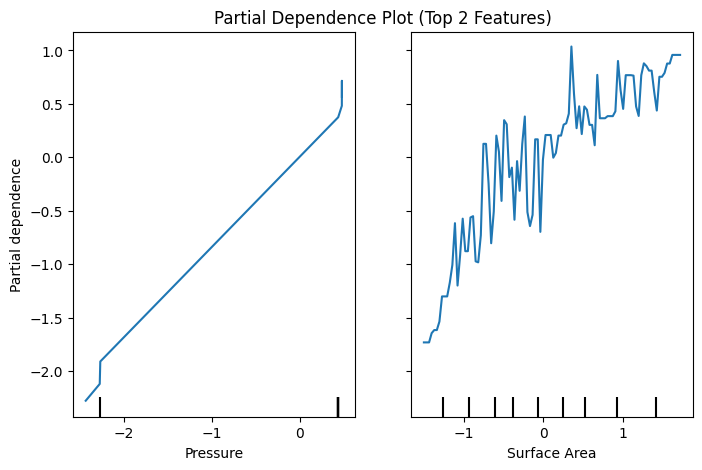

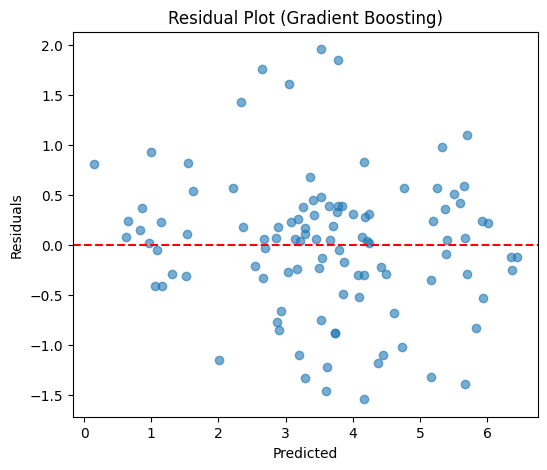

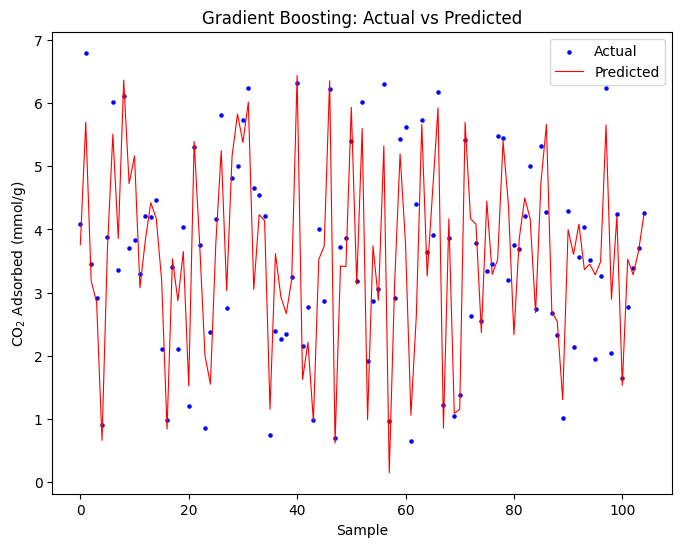

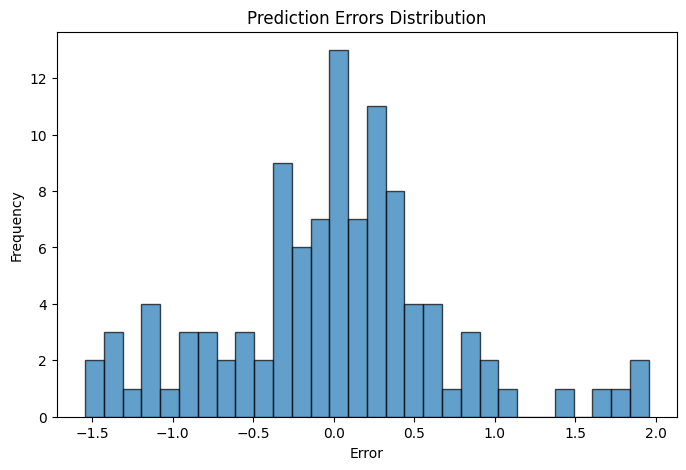

In [55]:
feature_names = ["Surface Area", "Pore Volume", "Micropore Fraction", "Temp", "Pressure"]

gboost_model, metrics_train, metrics_test, cv_results, perm_importance = ZF_GBoost_Regression(
    X_train_p, X_test_p, y_train, y_test, feature_names=feature_names)

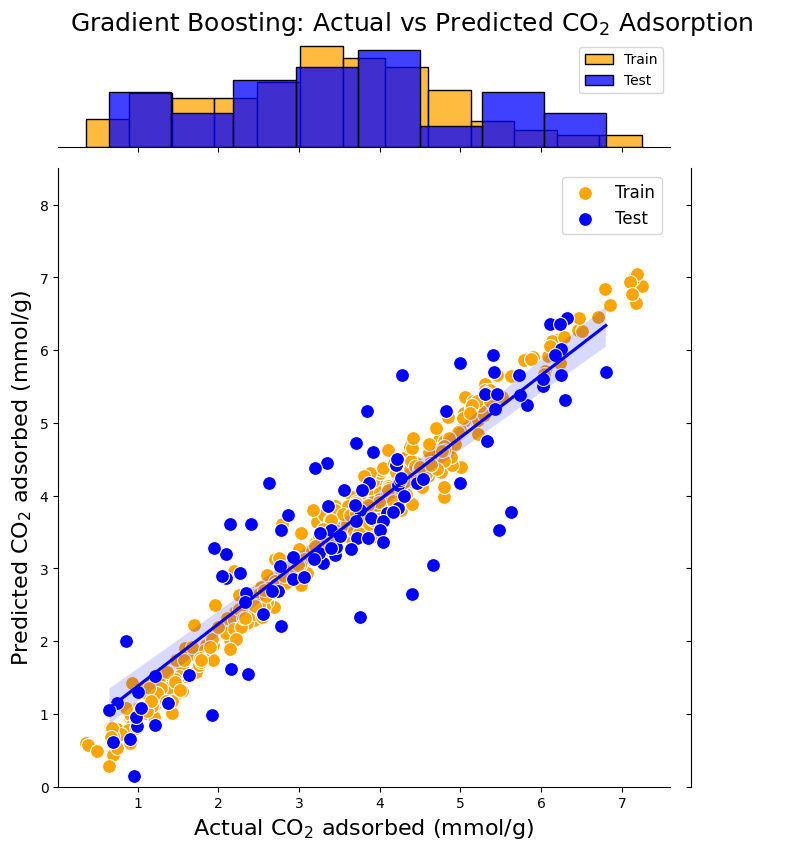

In [58]:
# ----------------------------
# Predictions
# ----------------------------
y_train_flat = y_train.ravel()
y_test_flat  = y_test.ravel()
y_pred_train_flat = gboost_model.predict(X_train_p)
y_pred_test_flat  = gboost_model.predict(X_test_p)
# ----------------------------
# 7️⃣ Joint plot: Actual vs Predicted
# ----------------------------

# Use consistent variable names
pp_tr = y_pred_train_flat
pp_te = y_pred_test_flat

# Correlation coefficients
r_train = np.corrcoef(y_train_flat, pp_tr)[0, 1]
r_test  = np.corrcoef(y_test_flat, pp_te)[0, 1]

# Create joint plot
g = sns.JointGrid(x=y_test_flat, y=pp_te, height=8)

sns.scatterplot(x=y_train_flat, y=pp_tr, s=100, color='orange', ax=g.ax_joint, label='Train')
sns.scatterplot(x=y_test_flat,  y=pp_te, s=100, color='blue',   ax=g.ax_joint, label='Test')

# Regression line for test data
sns.regplot(x=y_test_flat, y=pp_te, ax=g.ax_joint, scatter=False, color='blue')

# Axes limits
plt.ylim(0, 8.5)
plt.xlim(0, 8.5)

# Axis labels
g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", 
                  "Predicted CO$_2$ adsorbed (mmol/g)", 
                  fontsize=16)

# Marginal histograms
sns.histplot(y_train_flat, ax=g.ax_marg_x, color='orange', stat="density")
sns.histplot(y_test_flat,  ax=g.ax_marg_x, color='blue',   stat="density")

# Legends and title
g.ax_marg_x.legend(["Train", "Test"])
g.ax_joint.legend(fontsize=12)
plt.suptitle("Gradient Boosting: Actual vs Predicted CO$_2$ Adsorption", 
             fontsize=18, y=1.02)

plt.show()

In [ ]:
def ZF_GBoost_Regression(X_train, X_test, y_train, y_test, feature_names=None, cv=5):
    # Train model
    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    metrics_train = {
    "RMSE": np.sqrt(mean_squared_error(y_train.ravel(), y_pred_train)),
    "MAE": mean_absolute_error(y_train.ravel(), y_pred_train),
    "R2": r2_score(y_train.ravel(), y_pred_train)}

    metrics_test = {
    "RMSE": np.sqrt(mean_squared_error(y_test.ravel(), y_pred_test)),
    "MAE": mean_absolute_error(y_test.ravel(), y_pred_test),
    "R2": r2_score(y_test.ravel(), y_pred_test)}

    print("=== GradientBoosting Regressor Train Metrics ===", metrics_train)
    print("=== GradientBoosting Regressor Test Metrics ===", metrics_test)

    # Train/Test mean difference
    sq_diff = np.mean((y_pred_train.mean() - y_pred_test.mean())**2)
    print(f"Train/Test Mean Squared Difference: {sq_diff:.4f}")

    # Residual Plot
    plt.figure(figsize=(6,5))
    plt.scatter(y_pred_test, y_test.ravel() - y_pred_test, alpha=0.6)   
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted"); plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

    # Cross-validation
    cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")
    print(f"{cv}-Fold CV Mean Score: {np.mean(cv_score):.4f}")


    # Permutation Importance
    if feature_names is not None:
        perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        idxs = perm.importances_mean.argsort()
        plt.figure(figsize=(8,6))
        plt.barh(np.array(feature_names)[idxs], perm.importances_mean[idxs])
        plt.title("Permutation Importance")
        plt.show()

  
    # PDP for first two features
    PartialDependenceDisplay.from_estimator(model, X_test, [0,1], feature_names=feature_names)
    plt.show()

    # Learning Curve
    train_sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, cv=cv)
    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
    plt.plot(train_sizes, np.mean(val_scores, axis=1), label="CV")
    plt.title("Learning Curve"); plt.xlabel("Samples"); plt.ylabel("Score"); plt.legend()
    plt.show()

    # Validation Curve
    try:
        param_name = "n_estimators"
        param_range = [50,100,200]
        train_scores, val_scores = validation_curve(model, X_train, y_train, param_name=param_name, param_range=param_range, cv=3)
        plt.figure(figsize=(6,5))
        plt.plot(param_range, np.mean(train_scores,axis=1), label="Train")
        plt.plot(param_range, np.mean(val_scores,axis=1), label="CV")
        plt.title("Validation Curve"); plt.xlabel(param_name); plt.ylabel("Score"); plt.legend()
        plt.show()
    except:
        pass


    return model, metrics_train, metrics_test, sq_diff

=== GradientBoosting Regressor Train Metrics === {'RMSE': 0.28756191916912616, 'MAE': 0.21315278384315056, 'R2': 0.9618057864906706}
=== GradientBoosting Regressor Test Metrics === {'RMSE': 0.6435205168261122, 'MAE': 0.4784492223723156, 'R2': 0.8415050752996481}
Train/Test Mean Squared Difference: 0.0314


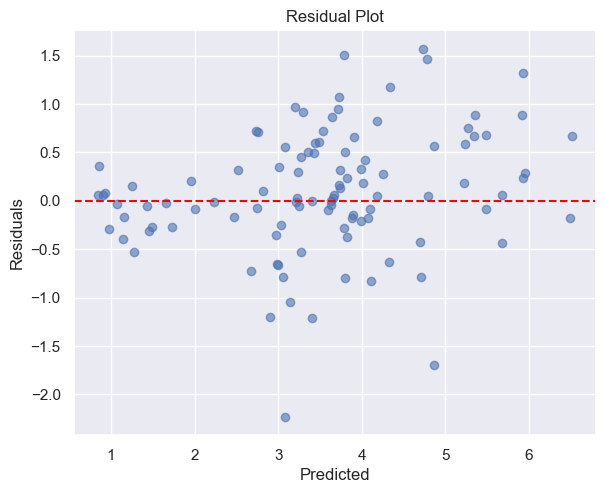

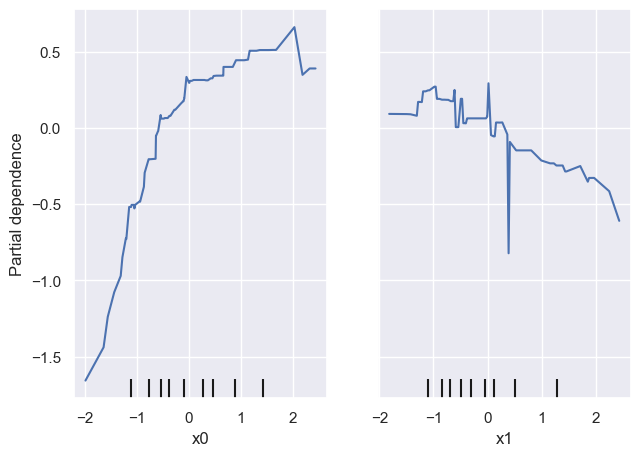

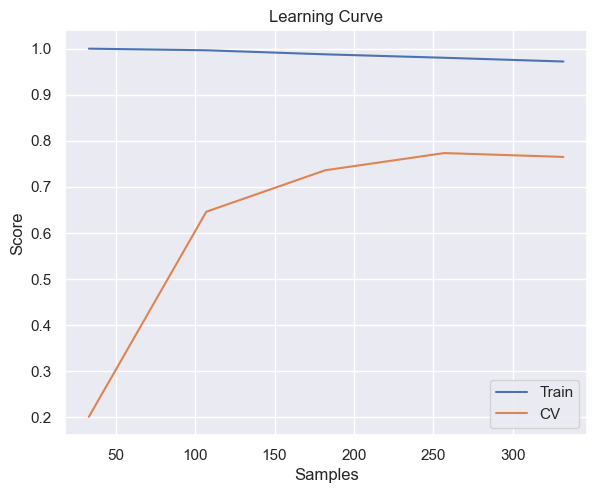

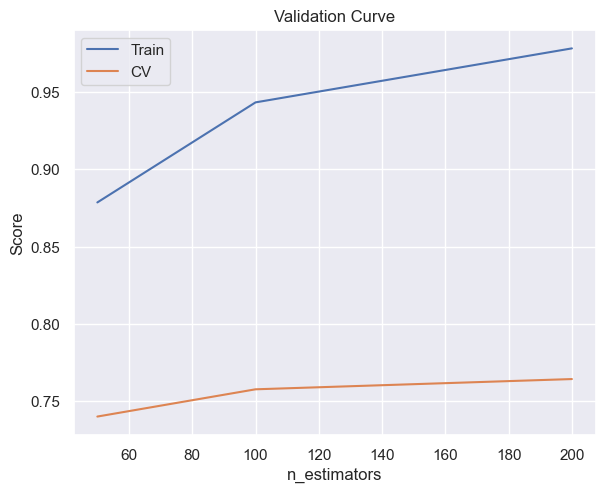

5-Fold CV Mean Score: 0.7692


In [162]:
model, metrics_train, metrics_test, sq_diff = ZF_GBoost_Regression(
    X_train, X_test, y_train, y_test,
    cv=5
)

# ================================
# ANN
# ================================

In [38]:
def ZF_ANN_Regression(X_train, X_test, y_train, y_test, epochs=150, batch_size=32, feature_names=None):
    # ----------------------------
    # 1️⃣ Build ANN model
    # ----------------------------
    ann_model = Sequential([
        Dense(32, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    ann_model.compile(loss='mean_squared_error', optimizer=Adam(), metrics=['mse', 'mae'])
    ann_model.summary()

    # Early stopping
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    # Fit model
    history = ann_model.fit(
        X_train, y_train.ravel(),
        validation_data=(X_test, y_test.ravel()),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stop]
    )

    # ----------------------------
    # 2️⃣ Predictions
    # ----------------------------
    y_train_pred = ann_model.predict(X_train).ravel()
    y_test_pred = ann_model.predict(X_test).ravel()

    # ----------------------------
    # 3️⃣ Metrics
    # ----------------------------
    metrics_train = {
        "RMSE": np.sqrt(mean_squared_error(y_train.ravel(), y_train_pred)),
        "MAE": mean_absolute_error(y_train.ravel(), y_train_pred),
        "R2": r2_score(y_train.ravel(), y_train_pred)
    }
    metrics_test = {
        "RMSE": np.sqrt(mean_squared_error(y_test.ravel(), y_test_pred)),
        "MAE": mean_absolute_error(y_test.ravel(), y_test_pred),
        "R2": r2_score(y_test.ravel(), y_test_pred)
    }
    print("=== ANN Train Metrics ===", metrics_train)
    print("=== ANN Test Metrics ===", metrics_test)

    # Train/Test mean difference
    sq_diff = np.mean((y_train_pred.mean() - y_test_pred.mean())**2)
    print(f"Train/Test Mean Squared Difference: {sq_diff:.4f}")

    # ----------------------------
    # 4️⃣ Residual Plot
    # ----------------------------
    plt.figure(figsize=(6,5))
    plt.scatter(y_test_pred, y_test.ravel() - y_test_pred, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (ANN)")
    plt.show()

    # ----------------------------
    # 5️⃣ Training History Plots
    # ----------------------------
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, history.history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

    if 'mae' in history.history:
        plt.figure(figsize=(8,5))
        plt.plot(epochs_range, history.history['mae'], 'g-', label='Training MAE')
        plt.plot(epochs_range, history.history['val_mae'], 'k-', label='Validation MAE')
        plt.xlabel('Epochs')
        plt.ylabel('Mean Absolute Error')
        plt.title('Training and Validation MAE')
        plt.legend()
        plt.show()

    # ----------------------------
    # 6️⃣ Predicted vs Actual
    # ----------------------------
    plt.figure(figsize=(8,6))
    x_ax = range(len(y_test_pred))
    plt.scatter(x_ax, y_test.ravel(), s=5, color="blue", label="Actual")
    plt.plot(x_ax, y_test_pred, lw=0.8, color="red", label="Predicted")
    plt.legend()
    plt.xlabel("Sample Index")
    plt.ylabel("CO$_2$ Adsorbed (mmol/g)")
    plt.title("ANN: Actual vs Predicted CO$_2$ Adsorption")
    plt.show()

    # ----------------------------
    # 7️⃣ Joint Plot
    # ----------------------------
    g = sns.JointGrid(x=y_test.ravel(), y=y_test_pred, height=8)
    sns.scatterplot(x=y_train.ravel(), y=y_train_pred, s=100, color='orange', ax=g.ax_joint, label='Train')
    sns.scatterplot(x=y_test.ravel(), y=y_test_pred, s=100, color='blue', ax=g.ax_joint, label='Test')
    sns.regplot(x=y_test.ravel(), y=y_test_pred, ax=g.ax_joint, scatter=False, color='blue')
    g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", "Predicted CO$_2$ adsorbed (mmol/g)", fontsize=16)
    sns.histplot(y_train.ravel(), ax=g.ax_marg_x, color='orange')
    sns.histplot(y_test.ravel(), ax=g.ax_marg_x, color='blue')
    g.ax_marg_x.legend(["Train", "Test"])
    plt.suptitle("ANN: Actual vs Predicted CO$_2$ Adsorption", fontsize=18, y=1.02)
    plt.show()

    # ----------------------------
    # 8️⃣ Error Distribution
    # ----------------------------
    errors = y_test.ravel() - y_test_pred
    plt.figure(figsize=(8, 5))
    plt.hist(errors, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Errors (ANN)')
    plt.show()

    # ----------------------------
    # 9️⃣ Explicit Evaluation Metrics Bar Chart
    # ----------------------------
    mae_nn = metrics_test['MAE']
    mse_nn = mean_squared_error(y_test.ravel(), y_test_pred)
    rmse_nn = metrics_test['RMSE']
    r2_nn = metrics_test['R2']

    plt.figure(figsize=(6, 4))
    values = [mae_nn, mse_nn, r2_nn, rmse_nn]
    bars = plt.bar(['MAE', 'MSE', 'R²', 'RMSE'], values, color='brown')
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=11)
    plt.title('Neural Network - Evaluation Metrics')
    plt.show()

    return ann_model, metrics_train, metrics_test, sq_diff, history


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 15.0955 - mae: 3.6552 - mse: 15.0078 - val_loss: 15.1106 - val_mae: 3.6294 - val_mse: 15.0233
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.1690 - mae: 3.2206 - mse: 12.0817 - val_loss: 12.5545 - val_mae: 3.2385 - val_mse: 12.4669
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.9626 - mae: 2.8377 - mse: 9.8744 - val_loss: 10.4462 - val_mae: 2.8950 - val_mse: 10.3571
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1151 - mae: 2.4846 - mse: 8.0249 - val_loss: 8.4717 - val_mae: 2.5463 - val_mse: 8.3803
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.3981 - mae: 2.1327 - mse: 6.3056 - val_loss: 6.6731 - val_mae: 2.1977 - val_mse: 6.5790
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.9274 - mae: 1.8237 - mse: 4.8320 - val_loss: 5.1129 - val_mae: 1.8714 - val_mse: 5.0159
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7492 - mae: 1.5757 - mse: 3.6508 -

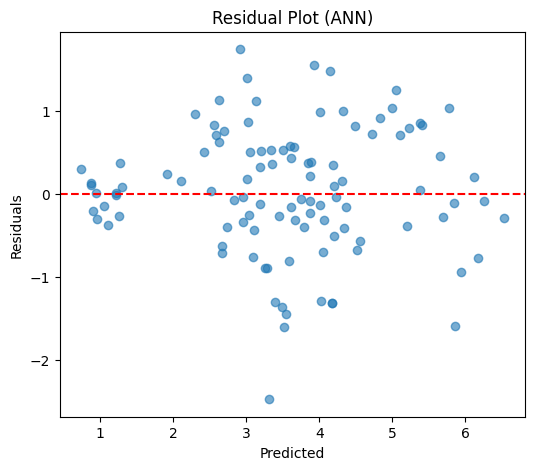

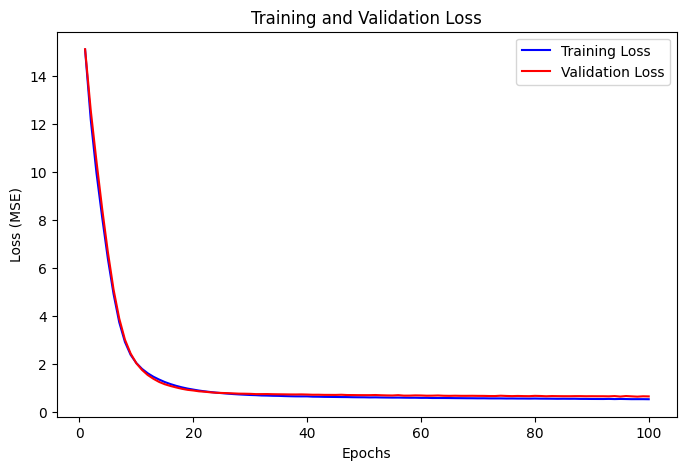

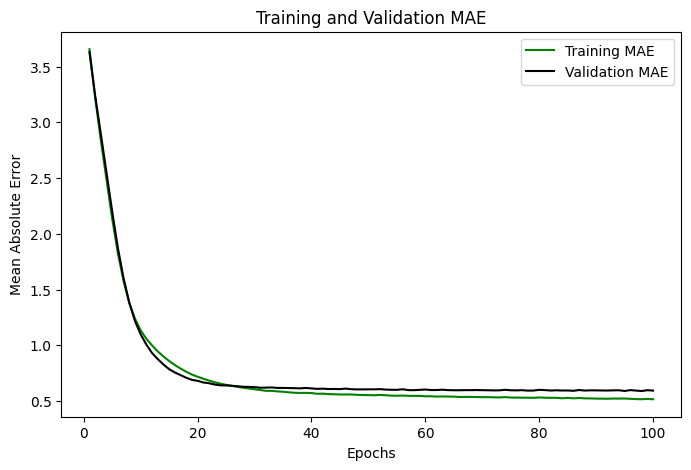

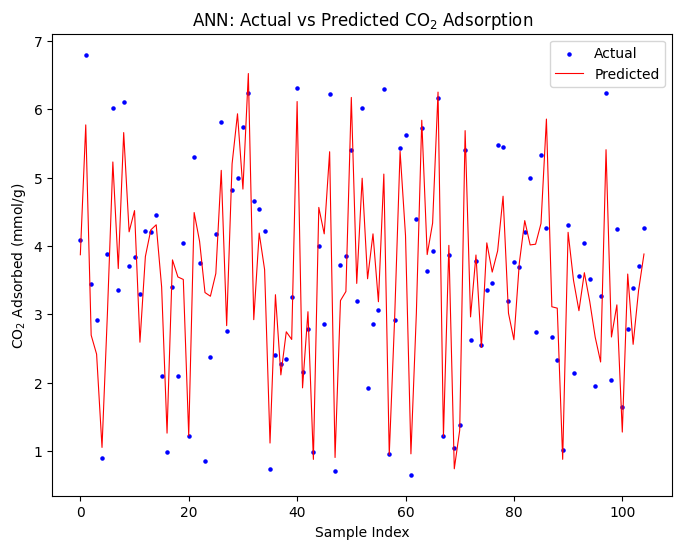

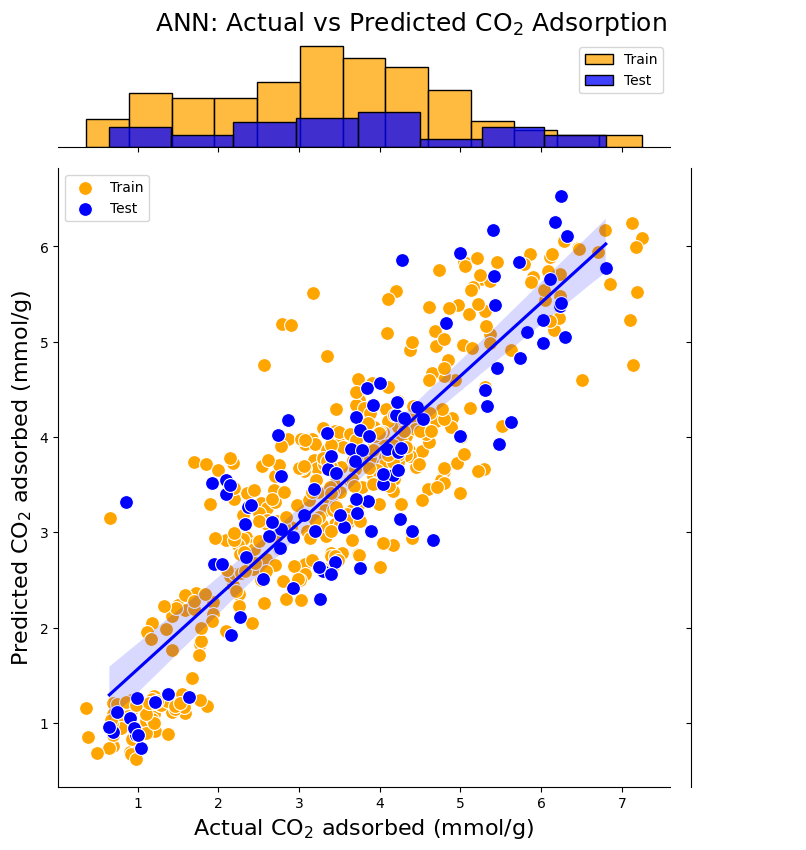

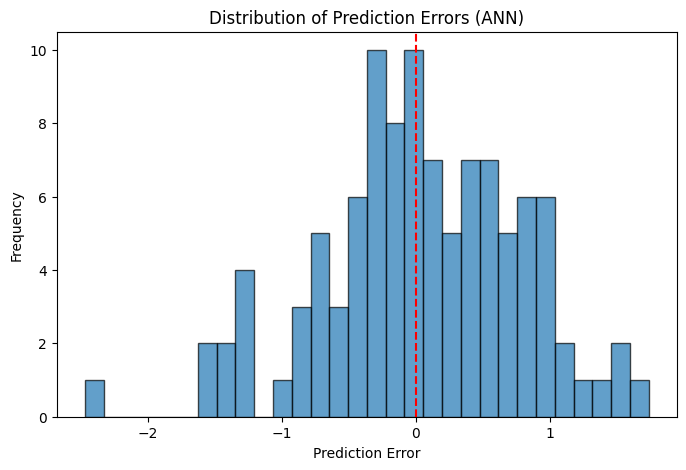

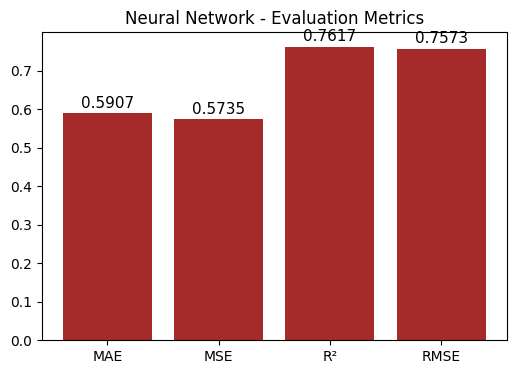

In [39]:
# Train ANN
feature_names = ["Surface Area", "Pore Volume", "Micropore Fraction", "Temp", "Pressure"]
ann_model, metrics_train, metrics_test, sq_diff, history = ZF_ANN_Regression(
    X_train, X_test, y_train, y_test,
    epochs=100,
    batch_size=32,
    feature_names=feature_names
)

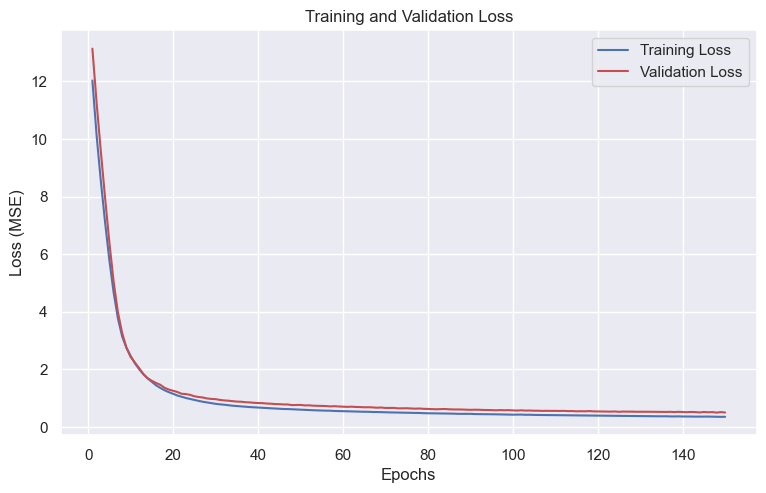

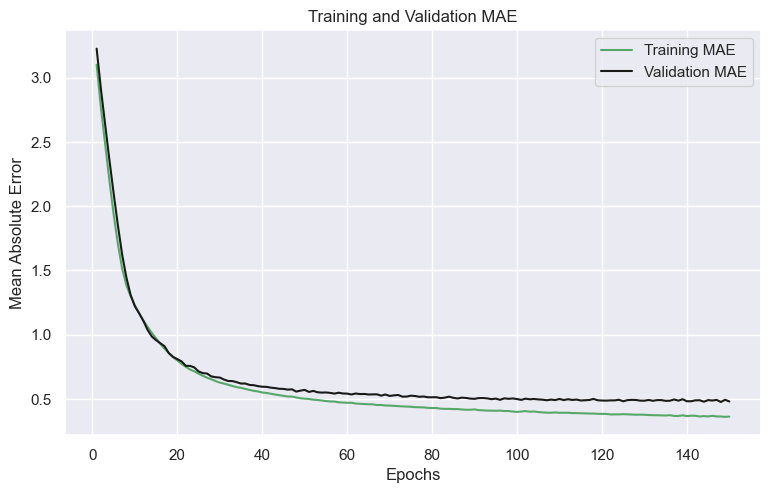

In [ ]:

# Epoch range
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10,6))

# Plot Loss (red)
plt.plot(epochs_range, history.history['loss'], 'r-', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], 'r--', label='Validation Loss')

# Plot MSE (green)
if 'mse' in history.history:
    plt.plot(epochs_range, history.history['mse'], 'g-', label='Training MSE')
    plt.plot(epochs_range, history.history['val_mse'], 'g--', label='Validation MSE')

# Plot MAE (blue)
if 'mae' in history.history:
    plt.plot(epochs_range, history.history['mae'], 'b-', label='Training MAE')
    plt.plot(epochs_range, history.history['val_mae'], 'b--', label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training and Validation Loss, MSE, and MAE')
plt.legend()
plt.grid(True)
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


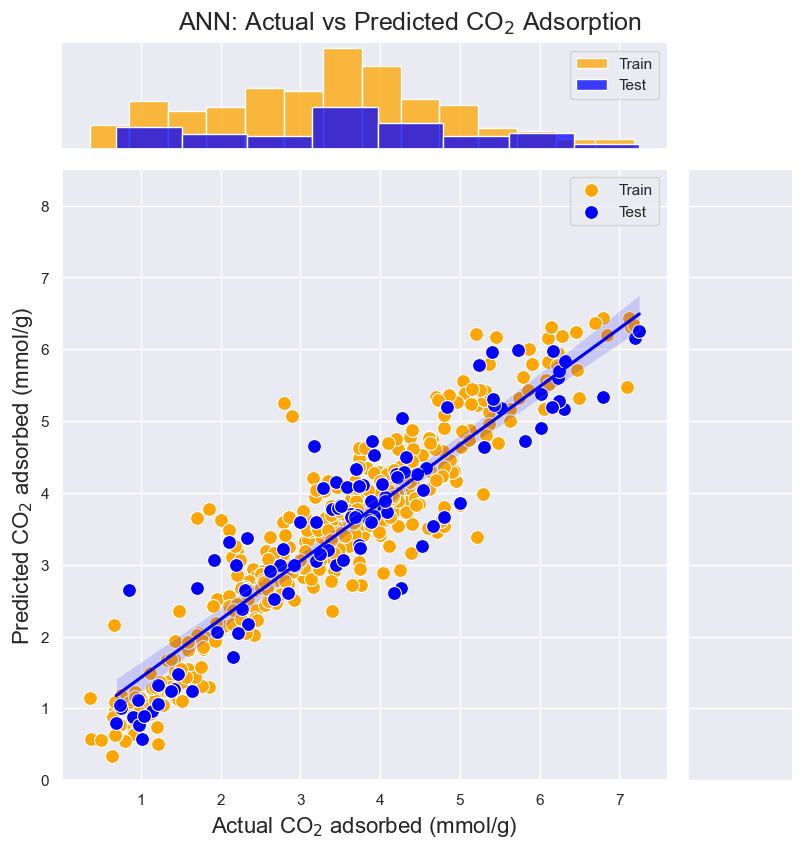

In [164]:
# ----------------------------
# 8️⃣ Joint plot: Actual vs Predicted (ANN)
# ----------------------------
y_train_pred_flat = ann_model.predict(X_train).ravel()
y_test_pred_flat  = ann_model.predict(X_test).ravel()

g = sns.JointGrid(x=y_test.ravel(), y=y_test_pred_flat, height=8)

# Scatter plots
sns.scatterplot(x=y_train.ravel(), y=y_train_pred_flat, s=100, color='orange', ax=g.ax_joint, label='Train')
sns.scatterplot(x=y_test.ravel(), y=y_test_pred_flat, s=100, color='blue', ax=g.ax_joint, label='Test')

# Regression line for test set
sns.regplot(x=y_test.ravel(), y=y_test_pred_flat, ax=g.ax_joint, scatter=False, color='blue')

# Axis limits
plt.ylim(0, 8.5)
plt.xlim(0, 8.5)

# Labels
g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", "Predicted CO$_2$ adsorbed (mmol/g)", fontsize=16)

# Marginal histograms
sns.histplot(y_train.ravel(), ax=g.ax_marg_x, color='orange')
sns.histplot(y_test.ravel(), ax=g.ax_marg_x, color='blue')
g.ax_marg_x.legend(["Train", "Test"])

plt.suptitle("ANN: Actual vs Predicted CO$_2$ Adsorption", fontsize=18, y=1.02)
plt.show()

# ================================
# CNN
# ================================

In [53]:
def ZF_CNN_Regression(X_train, X_test, y_train, y_test, epochs=150, batch_size=32, feature_names=None):
  
    
    # ----------------------------
    # 1️⃣ Prepare data for CNN (add channel dimension)
    # ----------------------------
    print(f"Original shapes - X_train: {X_train.shape}, X_test: {X_test.shape}")
    
    # Reshape for CNN (samples, timesteps, channels)
    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    print(f"CNN shapes - X_train_cnn: {X_train_cnn.shape}, X_test_cnn: {X_test_cnn.shape}")
    
    # ----------------------------
    # 2️⃣ Build CNN model
    # ----------------------------
    cnn = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(X_train_cnn.shape[1], 1),
               padding='same',
               kernel_regularizer=regularizers.l2(0.01)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')  # regression output
    ])

    cnn.compile(loss='mean_squared_error', optimizer=Adam(), metrics=['mse', 'mae'])
    
    # Display model architecture
    cnn.summary()

    # ----------------------------
    # 3️⃣ Training with Early Stopping
    # ----------------------------
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = cnn.fit(
        X_train_cnn, y_train.ravel(),
        validation_data=(X_test_cnn, y_test.ravel()),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stop]
    )

    # ----------------------------
    # 4️⃣ Predictions
    # ----------------------------
    y_train_pred = cnn.predict(X_train_cnn).ravel()
    y_test_pred = cnn.predict(X_test_cnn).ravel()

    # ----------------------------
    # 5️⃣ Metrics
    # ----------------------------
    metrics_trainn = {
        "RMSE": np.sqrt(mean_squared_error(y_train.ravel(), y_train_pred)),
        "MAE": mean_absolute_error(y_train.ravel(), y_train_pred),
        "R2": r2_score(y_train.ravel(), y_train_pred)
    }
    metrics_testt = {
        "RMSE": np.sqrt(mean_squared_error(y_test.ravel(), y_test_pred)),
        "MAE": mean_absolute_error(y_test.ravel(), y_test_pred),
        "R2": r2_score(y_test.ravel(), y_test_pred)
    }
    print("=== ANN Train Metrics ===", metrics_trainn)
    print("=== ANN Test Metrics ===", metrics_testt)
    

    # Train/Test mean difference
    sq_diff = np.mean((y_train_pred.mean() - y_test_pred.mean())**2)
    print(f"\nTrain/Test Mean Squared Difference: {sq_diff:.4f}")

    # ----------------------------
    # 6️⃣ Residual Plot
    # ----------------------------
    plt.figure(figsize=(6,5))
    plt.scatter(y_test_pred, y_test.ravel() - y_test_pred, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (CNN)")
    plt.show()

    # ----------------------------
    # 7️⃣ Training History
    # ----------------------------
    epochs_range = range(1, len(history.history['loss']) + 1)
    
    # Loss plot
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, history.history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('CNN: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # MAE plot
    if 'mae' in history.history:
        plt.figure(figsize=(8,5))
        plt.plot(epochs_range, history.history['mae'], 'g-', label='Training MAE')
        plt.plot(epochs_range, history.history['val_mae'], 'k-', label='Validation MAE')
        plt.xlabel('Epochs')
        plt.ylabel('Mean Absolute Error')
        plt.title('CNN: Training and Validation MAE')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ----------------------------
    # 8️⃣ Predicted vs Actual
    # ----------------------------
    plt.figure(figsize=(8,6))
    x_ax = range(len(y_test_pred))
    plt.scatter(x_ax, y_test.ravel(), s=5, color="blue", label="Actual")
    plt.plot(x_ax, y_test_pred, lw=0.8, color="red", label="Predicted")
    plt.legend()
    plt.xlabel("Sample Index")
    plt.ylabel("CO$_2$ Adsorbed (mmol/g)")
    plt.title("CNN: Actual vs Predicted CO$_2$ Adsorption")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 9️⃣ Scatter Plot (Actual vs Predicted)
    # ----------------------------
    plt.figure(figsize=(10, 8))
    
    # Create scatter plot
    plt.scatter(y_train.ravel(), y_train_pred, alpha=0.6, color='orange', label='Train', s=50)
    plt.scatter(y_test.ravel(), y_test_pred, alpha=0.6, color='blue', label='Test', s=50)
    
    # Add perfect prediction line
    max_val = max(np.max(y_test.ravel()), np.max(y_test_pred), np.max(y_train.ravel()), np.max(y_train_pred))
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
    
    plt.xlabel("Actual CO$_2$ adsorbed (mmol/g)")
    plt.ylabel("Predicted CO$_2$ adsorbed (mmol/g)")
    plt.title("CNN: Actual vs Predicted CO$_2$ Adsorption")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 🔟 Joint Plot for CNN (Corrected - using CNN predictions)
    # ----------------------------
    g = sns.JointGrid(x=y_test.ravel(), y=y_test_pred, height=8)

    # Scatter plots
    sns.scatterplot(x=y_train.ravel(), y=y_train_pred, s=100, color='orange', ax=g.ax_joint, label='Train')
    sns.scatterplot(x=y_test.ravel(), y=y_test_pred, s=100, color='blue', ax=g.ax_joint, label='Test')

    # Regression line for test set
    sns.regplot(x=y_test.ravel(), y=y_test_pred, ax=g.ax_joint, scatter=False, color='blue')

    # Axis limits
    plt.ylim(0, 8.5)
    plt.xlim(0, 8.5)

    # Labels
    g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", "Predicted CO$_2$ adsorbed (mmol/g)", fontsize=16)

    # Marginal histograms
    sns.histplot(y_train.ravel(), ax=g.ax_marg_x, color='orange')
    sns.histplot(y_test.ravel(), ax=g.ax_marg_x, color='blue')
    g.ax_marg_x.legend(["Train", "Test"])

    plt.suptitle("CNN: Actual vs Predicted CO$_2$ Adsorption", fontsize=18, y=1.02)
    plt.show()

    # ----------------------------
    # 1️⃣1️⃣ Error Distribution
    # ----------------------------
    errors = y_test.ravel() - y_test_pred
    plt.figure(figsize=(8, 5))
    plt.hist(errors, bins=30, alpha=0.7, edgecolor='black', color='purple')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.title('CNN: Distribution of Prediction Errors')
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 1️⃣2️⃣ Feature Importance (Gradient-based)
    # ----------------------------
    try:
        # Get the first convolutional layer weights
        first_conv_weights = cnn.layers[0].get_weights()[0]
        feature_importance = np.mean(np.abs(first_conv_weights), axis=(0, 2))
        
        if feature_names is not None:
            plt.figure(figsize=(10, 6))
            plt.bar(range(len(feature_importance)), feature_importance)
            plt.xticks(range(len(feature_importance)), feature_names, rotation=45, ha='right')
            plt.xlabel('Features')
            plt.ylabel('Importance (Mean Absolute Weight)')
            plt.title('CNN: Feature Importance from First Conv Layer')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Feature importance visualization failed: {e}")

    return cnn, metrics_train, metrics_test, sq_diff, history

Original shapes - X_train: (416, 5), X_test: (105, 5)
CNN shapes - X_train_cnn: (416, 5, 1), X_test_cnn: (105, 5, 1)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 5, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 2, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,545 (33.38 KB)

 Trainable params: 8,545 (33.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 10.1145 - mae: 2.7839 - mse: 10.0923 - val_loss: 7.9886 - val_mae: 2.4750 - val_mse: 7.9654
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.1637 - mae: 1.9391 - mse: 5.1393 - val_loss: 4.1588 - val_mae: 1.6597 - val_mse: 4.1333
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.3528 - mae: 1.7202 - mse: 4.3275 - val_loss: 3.4498 - val_mae: 1.5346 - val_mse: 3.4252
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4617 - mae: 1.5885 - mse: 3.4377 - val_loss: 3.1649 - val_mae: 1.4827 - val_mse: 3.1413
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.0434 - mae: 1.4784 - mse: 3.0198 - val_loss: 2.5622 - val_mae: 1.2862 - val_mse: 2.5387
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6638 - mae: 1.3425 - mse: 2.6404 - val_loss: 2.2511 - val_mae: 1.2185 - val_mse: 2.2277
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2172 - mae: 1.2420 - mse: 2.1938 - val_lo

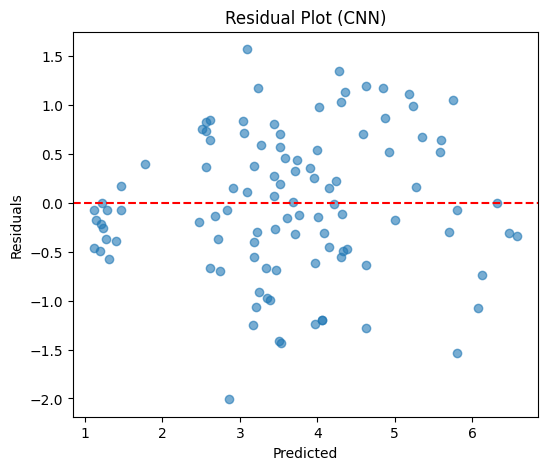

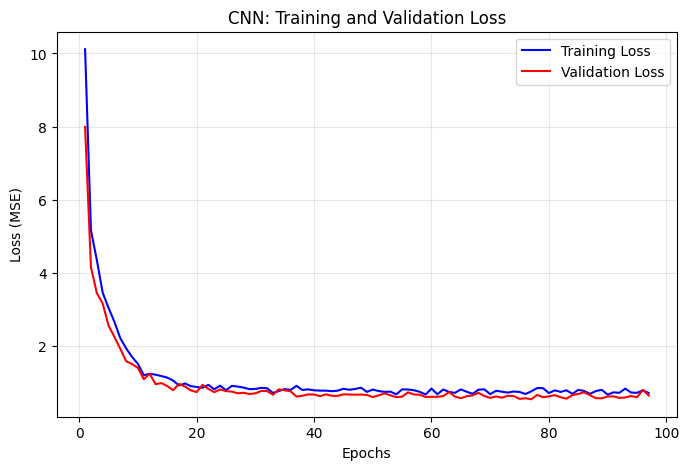

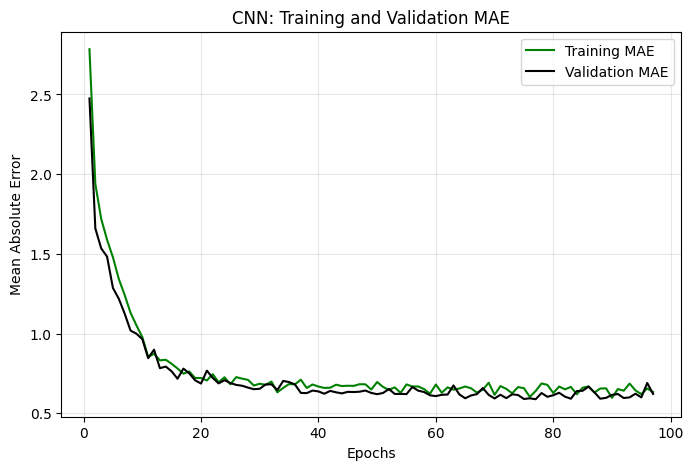

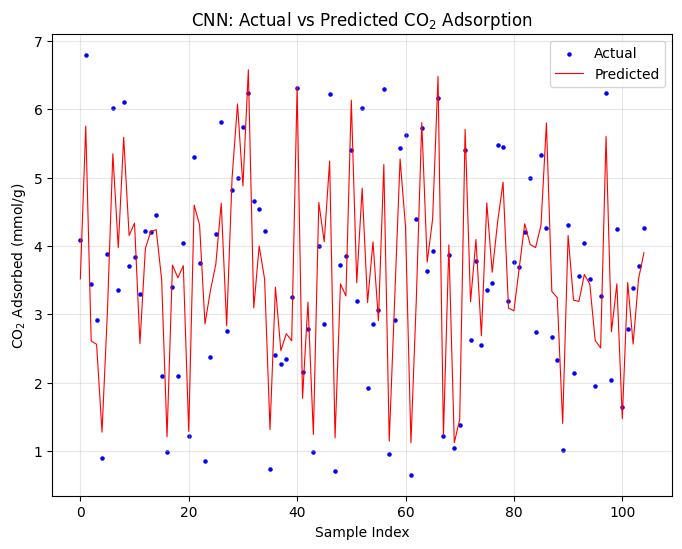

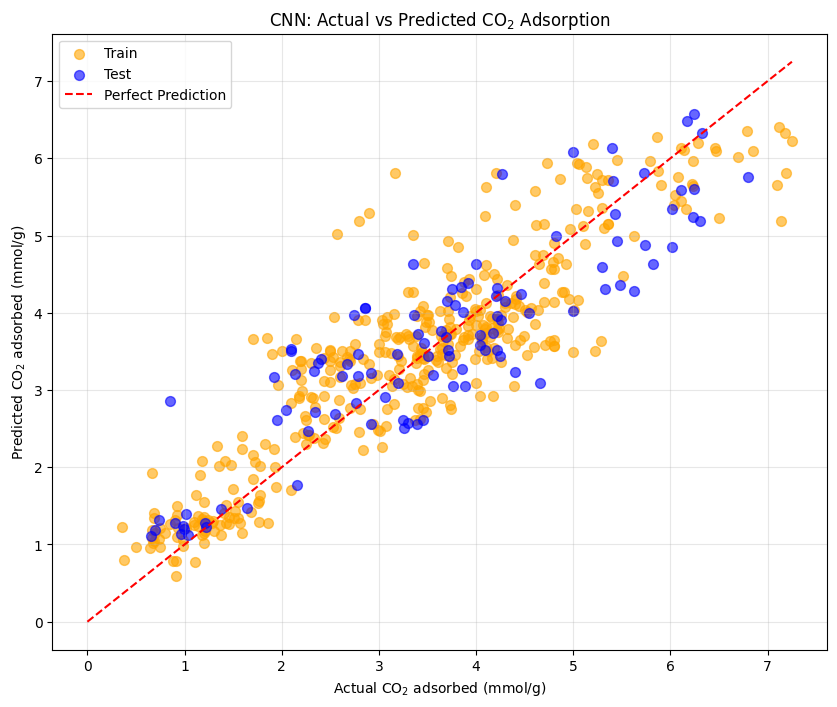

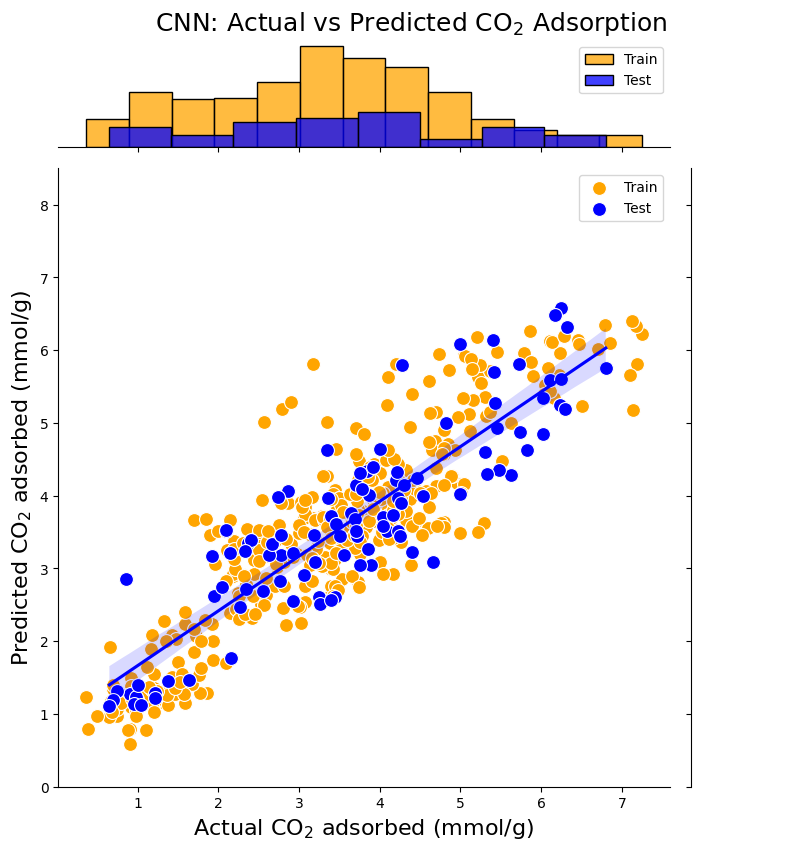

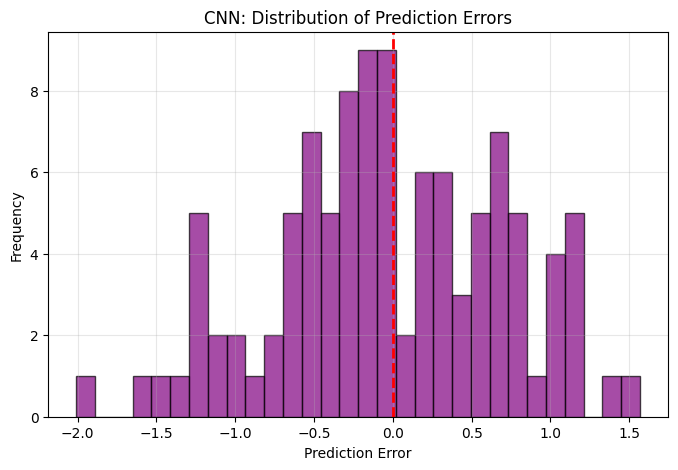

Feature importance visualization failed: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (5).


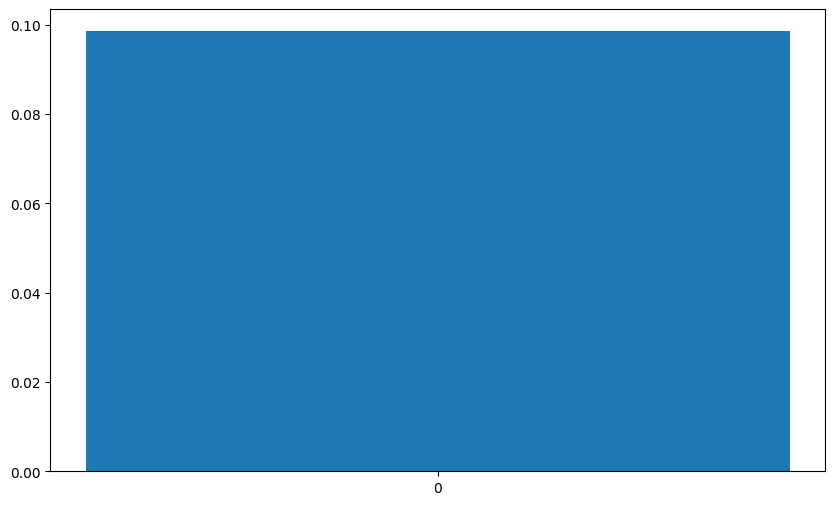

In [54]:
# Train CNN
feature_names = ["Surface Area", "Pore Volume", "Micropore Fraction", "Temp", "Pressure"]
cnn_model, cnn_metrics_train, cnn_metrics_test, cnn_sq_diff, cnn_history = ZF_CNN_Regression(
    X_train, X_test, y_train, y_test,
    epochs=100,
    batch_size=32,
    feature_names=feature_names
)

# ================================
# LSTM
# ================================

In [44]:
def ZF_LSTM_Regression(X_train, X_test, y_train, y_test, epochs=150, batch_size=32, feature_names=None):
  
    
    # ----------------------------
    # 1️⃣ Prepare data for LSTM (add timestep dimension)
    # ----------------------------
    print(f"Original shapes - X_train: {X_train.shape}, X_test: {X_test.shape}")
    
    # Reshape for LSTM (samples, timesteps, features)
    # Assuming each sample is a single timestep with multiple features
    timesteps = 1  # Each sample is one timestep
    features = X_train.shape[1]  # Number of features
    
    X_train_lstm = X_train.reshape(X_train.shape[0], timesteps, features)
    X_test_lstm = X_test.reshape(X_test.shape[0], timesteps, features)
    
    print(f"LSTM shapes - X_train_lstm: {X_train_lstm.shape}, X_test_lstm: {X_test_lstm.shape}")
    print(f"Timesteps: {timesteps}, Features: {features}")
    
    # ----------------------------
    # 2️⃣ Build LSTM model
    # ----------------------------
    lstm = Sequential([
        LSTM(64, activation='tanh', return_sequences=True,
             input_shape=(timesteps, features),
             kernel_regularizer=regularizers.l2(0.01)),
        LSTM(32, return_sequences=False),  # last LSTM collapses sequence
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])

    lstm.compile(loss='mean_squared_error', optimizer=Adam(), metrics=['mse', 'mae'])
    
    # Display model architecture
    lstm.summary()

    # ----------------------------
    # 3️⃣ Training with Early Stopping
    # ----------------------------
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = lstm.fit(
        X_train_lstm, y_train.ravel(),
        validation_data=(X_test_lstm, y_test.ravel()),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stop]
    )

    # ----------------------------
    # 4️⃣ Predictions
    # ----------------------------
    y_train_pred = lstm.predict(X_train_lstm).ravel()
    y_test_pred = lstm.predict(X_test_lstm).ravel()

    # ----------------------------
    # 5️⃣ Metrics
    # ----------------------------
    metrics_train2 = {
        "RMSE": np.sqrt(mean_squared_error(y_train.ravel(), y_train_pred)),
        "MAE": mean_absolute_error(y_train.ravel(), y_train_pred),
        "R2": r2_score(y_train.ravel(), y_train_pred)
    }
    metrics_test2 = {
        "RMSE": np.sqrt(mean_squared_error(y_test.ravel(), y_test_pred)),
        "MAE": mean_absolute_error(y_test.ravel(), y_test_pred),
        "R2": r2_score(y_test.ravel(), y_test_pred)
    }

 
    
    print("=== LSTM Train Metrics ===", metrics_train2)
    print("===LSTM Test Metrics ===", metrics_test2)
    
   

    # Train/Test mean difference
    sq_diff = np.mean((y_train_pred.mean() - y_test_pred.mean())**2)
    print(f"\nTrain/Test Mean Squared Difference: {sq_diff:.4f}")

    # ----------------------------
    # 6️⃣ Residual Plot
    # ----------------------------
    plt.figure(figsize=(6,5))
    plt.scatter(y_test_pred, y_test.ravel() - y_test_pred, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (LSTM)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 7️⃣ Training History
    # ----------------------------
    epochs_range = range(1, len(history.history['loss']) + 1)
    
    # Loss plot
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, history.history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('LSTM: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # MAE plot
    if 'mae' in history.history:
        plt.figure(figsize=(8,5))
        plt.plot(epochs_range, history.history['mae'], 'g-', label='Training MAE')
        plt.plot(epochs_range, history.history['val_mae'], 'k-', label='Validation MAE')
        plt.xlabel('Epochs')
        plt.ylabel('Mean Absolute Error')
        plt.title('LSTM: Training and Validation MAE')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ----------------------------
    # 8️⃣ Predicted vs Actual (Time Series Style)
    # ----------------------------
    plt.figure(figsize=(8,6))
    x_ax = range(len(y_test_pred))
    plt.scatter(x_ax, y_test.ravel(), s=5, color="blue", label="Actual")
    plt.plot(x_ax, y_test_pred, lw=0.8, color="red", label="Predicted")
    plt.legend()
    plt.xlabel("Sample Index")
    plt.ylabel("CO$_2$ Adsorbed (mmol/g)")
    plt.title("LSTM: Actual vs Predicted CO$_2$ Adsorption")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 9️⃣ Scatter Plot (Actual vs Predicted)
    # ----------------------------
    plt.figure(figsize=(10, 8))
    
    # Create scatter plot
    plt.scatter(y_train.ravel(), y_train_pred, alpha=0.6, color='orange', label='Train', s=50)
    plt.scatter(y_test.ravel(), y_test_pred, alpha=0.6, color='blue', label='Test', s=50)
    
    # Add perfect prediction line
    max_val = max(np.max(y_test.ravel()), np.max(y_test_pred), np.max(y_train.ravel()), np.max(y_train_pred))
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
    
    plt.xlabel("Actual CO$_2$ adsorbed (mmol/g)")
    plt.ylabel("Predicted CO$_2$ adsorbed (mmol/g)")
    plt.title("LSTM: Actual vs Predicted CO$_2$ Adsorption")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 🔟 Joint Plot for LSTM
    # ----------------------------
    g = sns.JointGrid(x=y_test.ravel(), y=y_test_pred, height=8)

    # Scatter plots
    sns.scatterplot(x=y_train.ravel(), y=y_train_pred, s=100, color='orange', ax=g.ax_joint, label='Train')
    sns.scatterplot(x=y_test.ravel(), y=y_test_pred, s=100, color='blue', ax=g.ax_joint, label='Test')

    # Regression line for test set
    sns.regplot(x=y_test.ravel(), y=y_test_pred, ax=g.ax_joint, scatter=False, color='blue')

    # Axis limits
    plt.ylim(0, 8.5)
    plt.xlim(0, 8.5)

    # Labels
    g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", "Predicted CO$_2$ adsorbed (mmol/g)", fontsize=16)

    # Marginal histograms
    sns.histplot(y_train.ravel(), ax=g.ax_marg_x, color='orange')
    sns.histplot(y_test.ravel(), ax=g.ax_marg_x, color='blue')
    g.ax_marg_x.legend(["Train", "Test"])

    plt.suptitle("LSTM: Actual vs Predicted CO$_2$ Adsorption", fontsize=18, y=1.02)
    plt.show()

    # ----------------------------
    # 1️⃣1️⃣ Error Distribution
    # ----------------------------
    errors = y_test.ravel() - y_test_pred
    plt.figure(figsize=(8, 5))
    plt.hist(errors, bins=30, alpha=0.7, edgecolor='black', color='purple')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.title('LSTM: Distribution of Prediction Errors')
    plt.grid(True, alpha=0.3)
    plt.show()

    # ----------------------------
    # 1️⃣2️⃣ Learning Rate Analysis (if available)
    # ----------------------------
    if 'lr' in history.history:
        plt.figure(figsize=(8,5))
        plt.plot(epochs_range, history.history['lr'], 'm-', label='Learning Rate')
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.title('LSTM: Learning Rate Schedule')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return lstm, metrics_train, metrics_test, sq_diff, history

Original shapes - X_train: (416, 5), X_test: (105, 5)
LSTM shapes - X_train_lstm: (416, 1, 5), X_test_lstm: (105, 1, 5)
Timesteps: 1, Features: 5


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 13.3182 - mae: 3.3197 - mse: 13.2218 - val_loss: 14.7388 - val_mae: 3.5046 - val_mse: 14.6497
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.6181 - mae: 3.2213 - mse: 12.5336 - val_loss: 13.8340 - val_mae: 3.3878 - val_mse: 13.7540
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.6156 - mae: 3.0833 - mse: 11.5375 - val_loss: 12.4691 - val_mae: 3.2075 - val_mse: 12.3921
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.0834 - mae: 2.8613 - mse: 10.0051 - val_loss: 10.2319 - val_mae: 2.8956 - val_mse: 10.1509
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.6484 - mae: 2.4521 - mse: 7.5629 - val_loss: 6.9366 - val_mae: 2.3508 - val_mse: 6.8445
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.1586 - mae: 1.9425 - mse: 5.0597 - val_loss: 3.4970 - val_mae: 1.6265 - val_mse: 3.3901
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7257 - mae: 1.3666 - mse: 2.

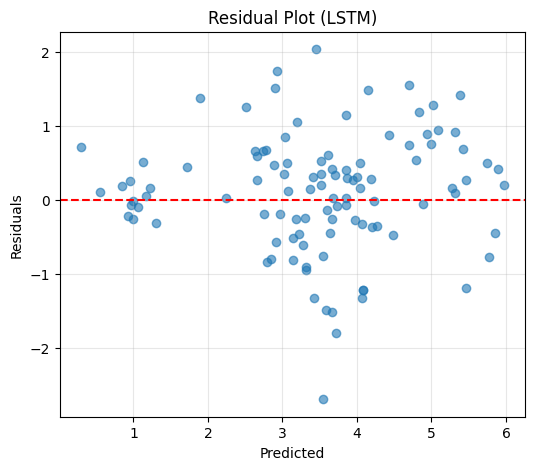

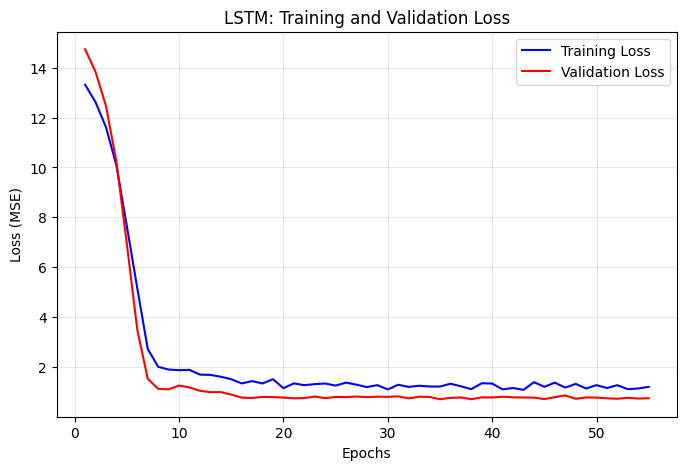

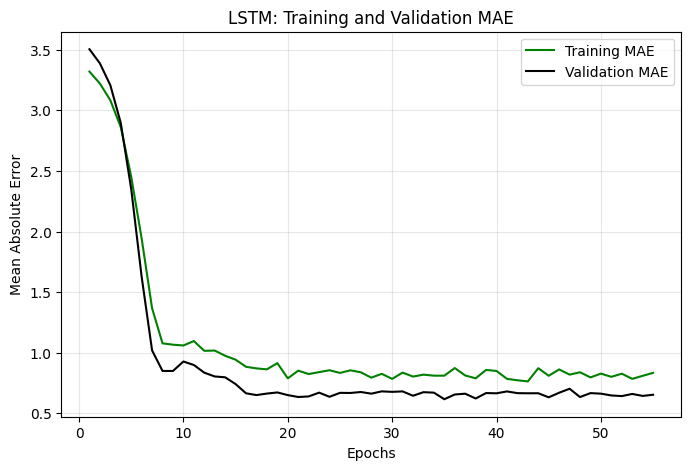

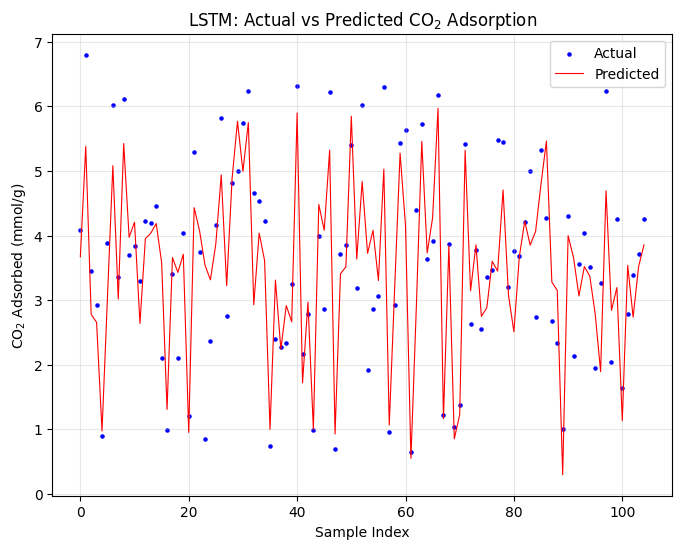

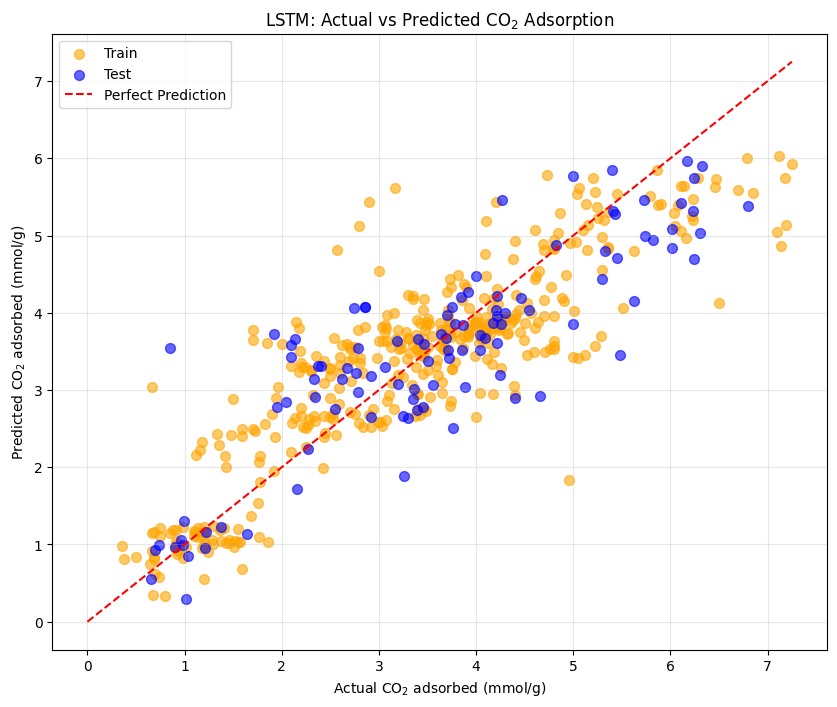

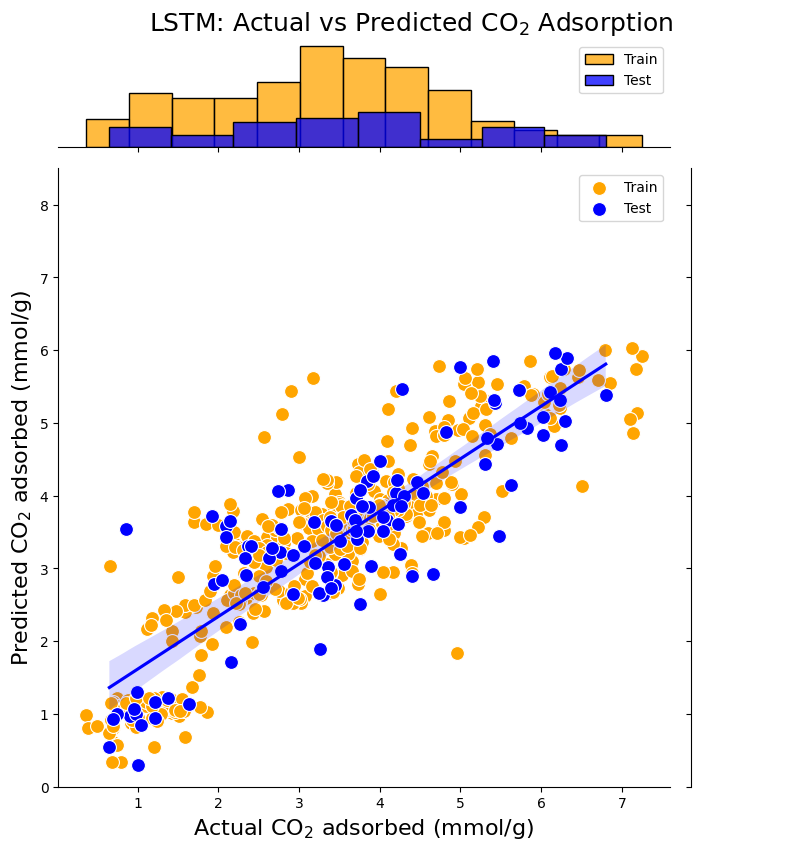

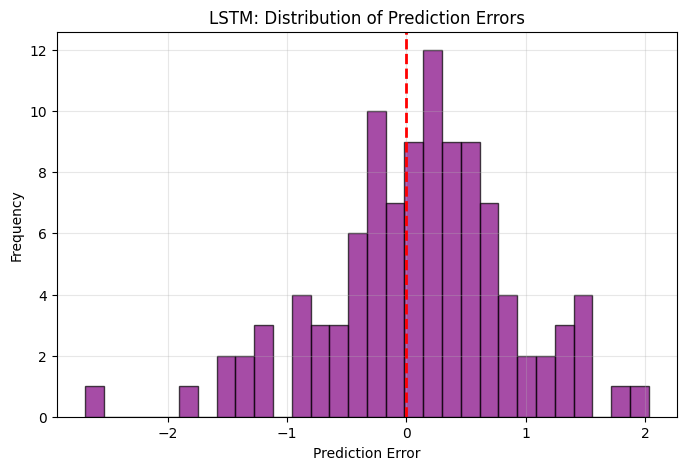

In [45]:
# Train LSTM
feature_names = ["Surface Area", "Pore Volume", "Micropore Fraction", "Temp", "Pressure"]
lstm_model, lstm_metrics_train, lstm_metrics_test, lstm_sq_diff, lstm_history = ZF_LSTM_Regression(
    X_train, X_test, y_train, y_test,
    epochs=100,
    batch_size=32,
    feature_names=feature_names
)

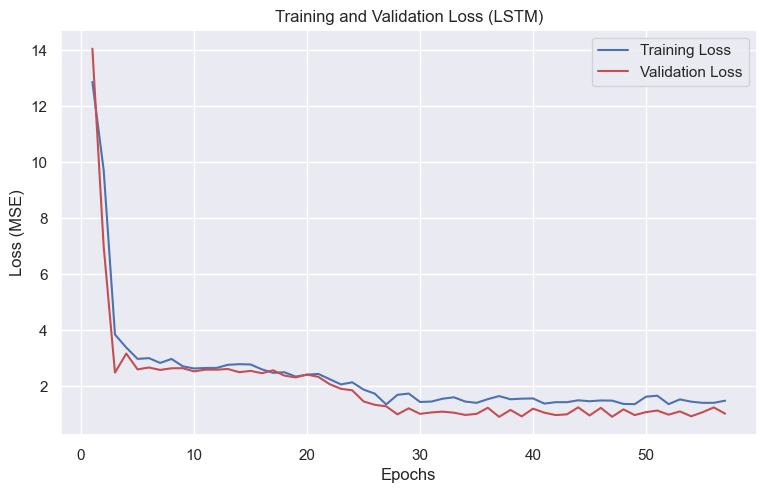

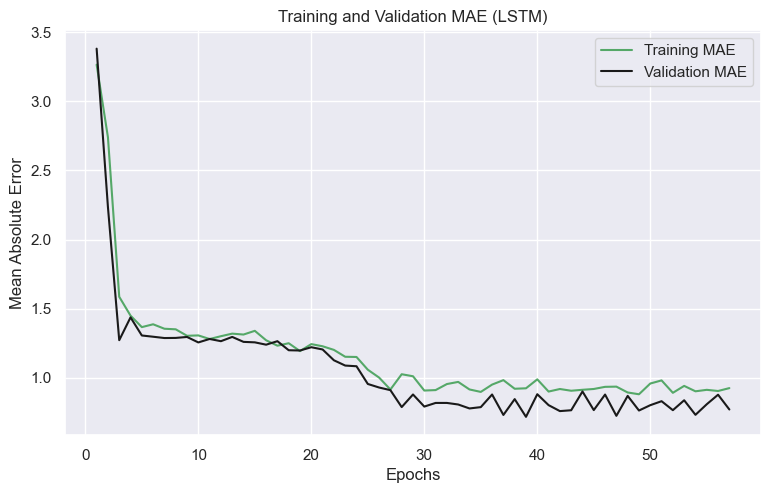

In [193]:
# ----------------------------
# 1️⃣ Plot Loss (MSE)
# ----------------------------
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history.history['loss'], 'b-', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss (LSTM)')
plt.legend()
plt.show()

# ----------------------------
# 2️⃣ Plot MAE (if exists)
# ----------------------------
if 'mae' in history.history:
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, history.history['mae'], 'g-', label='Training MAE')
    plt.plot(epochs_range, history.history['val_mae'], 'k-', label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE (LSTM)')
    plt.legend()
    plt.show()
else:
    print("⚠️ MAE was not tracked. Re-compile the model with metrics=['mse','mae'] to track MAE.")

# ================================
# LSTM-CNN
# ================================

In [46]:

def ZF_LSTM_CNN_Regression(X_train, X_test, y_train, y_test, epochs=200, batch_size=32):
    # ----------------------------
    # 1️⃣ Reshape data for LSTM-CNN
    # ----------------------------
    # LSTM expects (samples, timesteps, features)
    # Treat original features as timesteps, and features=1
    X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_lstm  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    timesteps = X_train_lstm.shape[1]
    features  = X_train_lstm.shape[2]

    # ----------------------------
    # 2️⃣ Build LSTM-CNN model
    # ----------------------------
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True,
             input_shape=(timesteps, features),
             kernel_regularizer=regularizers.l2(0.01)),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')  # regression output
    ])

    model.compile(loss='mean_squared_error', optimizer=Adam(), metrics=['mse', 'mae'])

    # Early stopping
    es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    # ----------------------------
    # 3️⃣ Fit model
    # ----------------------------
    history = model.fit(
        X_train_lstm, y_train,
        validation_data=(X_test_lstm, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[es]
    )

    # ----------------------------
    # 4️⃣ Predictions
    # ----------------------------
    y_train_flat = y_train.ravel()
    y_test_flat  = y_test.ravel()
    y_pred_train_flat = model.predict(X_train_lstm).ravel()
    y_pred_test_flat  = model.predict(X_test_lstm).ravel()

    # ----------------------------
    # 5️⃣ Metrics
    # ----------------------------
    metrics_train = {
        "RMSE": np.sqrt(mean_squared_error(y_train_flat, y_pred_train_flat)),
        "MAE": mean_absolute_error(y_train_flat, y_pred_train_flat),
        "R2": r2_score(y_train_flat, y_pred_train_flat)
    }
    metrics_test = {
        "RMSE": np.sqrt(mean_squared_error(y_test_flat, y_pred_test_flat)),
        "MAE": mean_absolute_error(y_test_flat, y_pred_test_flat),
        "R2": r2_score(y_test_flat, y_pred_test_flat)
    }

    print("=== LSTM-CNN Train Metrics ===", metrics_train)
    print("=== LSTM-CNN Test Metrics ===", metrics_test)

    sq_diff = np.mean((y_pred_train_flat.mean() - y_pred_test_flat.mean())**2)
    print(f"Train/Test Mean Squared Difference: {sq_diff:.4f}")

    # ----------------------------
    # 6️⃣ Residual Plot
    # ----------------------------
    plt.figure(figsize=(6,5))
    plt.scatter(y_pred_test_flat, y_test_flat - y_pred_test_flat, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (LSTM-CNN)")
    plt.show()

    # ----------------------------
    # 7️⃣ Training History
    # ----------------------------
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, history.history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

    if 'mae' in history.history:
        plt.figure(figsize=(8,5))
        plt.plot(epochs_range, history.history['mae'], 'g-', label='Training MAE')
        plt.plot(epochs_range, history.history['val_mae'], 'k-', label='Validation MAE')
        plt.xlabel('Epochs')
        plt.ylabel('Mean Absolute Error')
        plt.title('Training and Validation MAE')
        plt.legend()
        plt.show()

    # ----------------------------
    # 8️⃣ Predicted vs Actual Plot
    # ----------------------------
    plt.figure(figsize=(8,6), dpi=100)
    x_ax = range(len(y_test_flat))
    plt.scatter(x_ax, y_test_flat, s=5, color="blue", label="Actual")
    plt.plot(x_ax, y_pred_test_flat, lw=0.8, color="red", label="Predicted")
    plt.legend()
    plt.xlabel("Sample")
    plt.ylabel("CO$_2$ Adsorbed (mmol/g)")
    plt.title("LSTM-CNN: Actual vs Predicted CO$_2$ Adsorption")
    plt.show()

    # ----------------------------
    # 9️⃣ Joint Plot
    # ----------------------------
    g = sns.JointGrid(x=y_test_flat, y=y_pred_test_flat, height=8)
    sns.scatterplot(x=y_train_flat, y=y_pred_train_flat, s=100, color='orange', ax=g.ax_joint, label='Train')
    sns.scatterplot(x=y_test_flat, y=y_pred_test_flat, s=100, color='blue', ax=g.ax_joint, label='Test')
    sns.regplot(x=y_test_flat, y=y_pred_test_flat, ax=g.ax_joint, scatter=False, color='blue')

    plt.ylim(0, 8.5)
    plt.xlim(0, 8.5)
    g.set_axis_labels("Actual CO$_2$ adsorbed (mmol/g)", "Predicted CO$_2$ adsorbed (mmol/g)", fontsize=16)
    sns.histplot(y_train_flat, ax=g.ax_marg_x, color='orange')
    sns.histplot(y_test_flat, ax=g.ax_marg_x, color='blue')
    g.ax_marg_x.legend(["Train", "Test"])
    plt.suptitle("LSTM-CNN: Actual vs Predicted CO$_2$ Adsorption", fontsize=18, y=1.02)
    plt.show()

    return model, metrics_train, metrics_test, sq_diff, history


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 12.4272 - mae: 3.1792 - mse: 12.4091 - val_loss: 12.1746 - val_mae: 3.1071 - val_mse: 12.1570
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.0025 - mae: 2.4008 - mse: 7.9846 - val_loss: 5.5083 - val_mae: 1.9649 - val_mse: 5.4900
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0354 - mae: 1.8650 - mse: 5.0172 - val_loss: 4.0978 - val_mae: 1.6300 - val_mse: 4.0801
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2513 - mae: 1.4978 - mse: 3.2341 - val_loss: 2.4448 - val_mae: 1.2754 - val_mse: 2.4280
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.7515 - mae: 1.3087 - mse: 2.7351 - val_loss: 2.6737 - val_mae: 1.3349 - val_mse: 2.6574
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5445 - mae: 1.2828 - mse: 2.5283 - val_loss: 1.9821 - val_mae: 1.1418 - val_mse: 1.9659
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1177 - mae: 1.1733 - mse: 2.1015 -

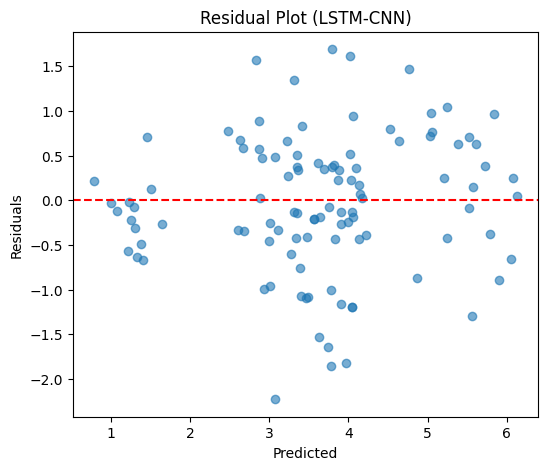

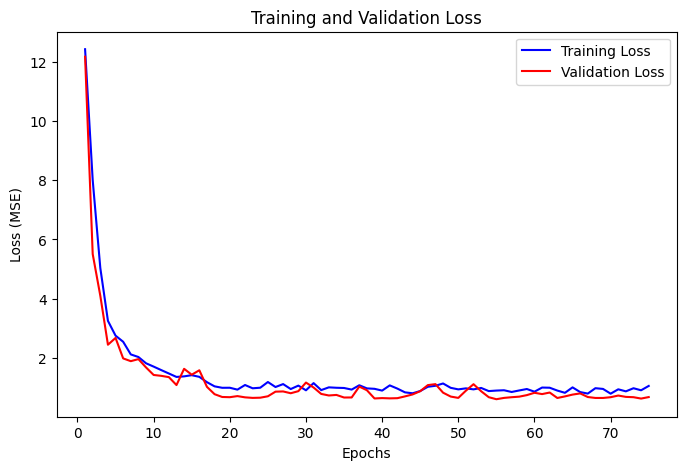

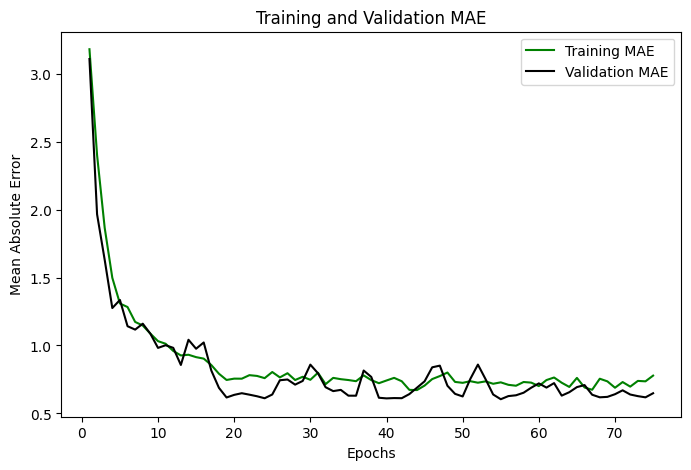

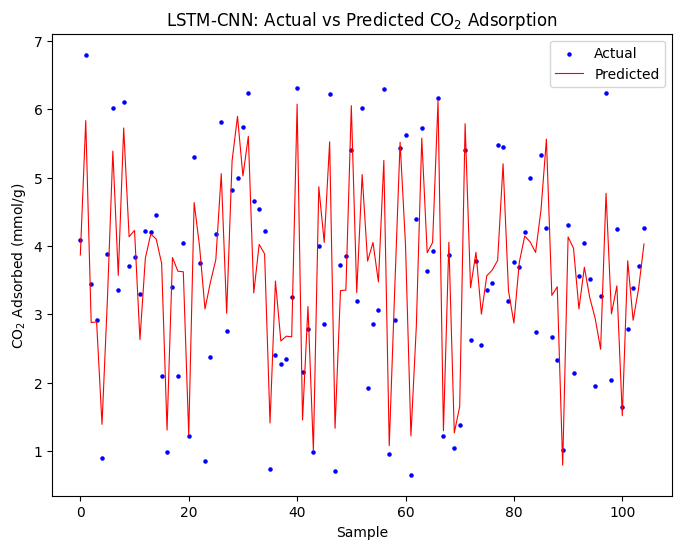

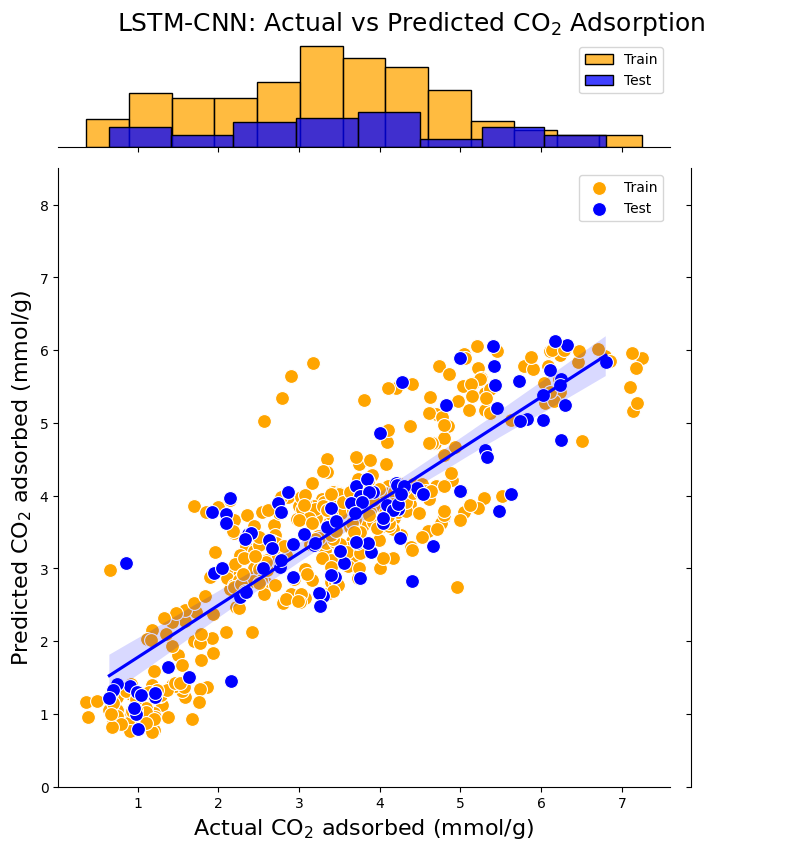

In [47]:
lstm_cnn_model, metrics_train, metrics_test, sq_diff, history = ZF_LSTM_CNN_Regression(
    X_train, X_test, y_train, y_test,
    epochs=200, batch_size=32
)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> hyperpearameter Optimization</p>
</div>

In [34]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

# ANN

In [93]:
def best_par_ann(X_train, y_train, X_test, y_test, early_stopping):
    results = []

    for batch_size_number in [16, 24, 32]:
        for reg in [0, 0.0001, 0.001]:
            for dropout_rate in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
                for neurons1 in range(50, 1000, 50):
                    for epochs_number in range(50, 850, 50):
                        for learning_rate_search in [0.0001,0.00025,0.0005,0.00075,0.001,0.0025,0.005,0.0075,0.01,0.025,0.05,0.075,0.1,0.2]:
                            regularizer = keras.regularizers.l2(reg)
                            model = Sequential()
                            model.add(Dense(neurons1, input_dim=X_train.shape[1],
                                            kernel_initializer='random_normal',
                                            bias_initializer='random_normal',
                                            activation='relu',
                                            kernel_regularizer=regularizer))
                            model.add(Dropout(dropout_rate))
                            model.add(Dense(neurons1, activation='relu', kernel_regularizer=regularizer))
                            model.add(Dropout(dropout_rate))
                            model.add(Dense(1, activation='linear'))

                            adam = Adam(learning_rate=learning_rate_search)
                            model.compile(loss='mse', optimizer=adam)

                            print(f'Training ANN: batch={batch_size_number}, neurons={neurons1}, epochs={epochs_number}, lr={learning_rate_search}')
                            model.fit(X_train, y_train,
                                      verbose=0,
                                      batch_size=batch_size_number,
                                      epochs=epochs_number,
                                      validation_split=0.2,
                                      callbacks=[early_stopping])

                            pred_test = model.predict(X_test)
                            score = r2_score(y_test, pred_test)
                            results.append({
                                'batch_size': batch_size_number,
                                'neurons': neurons1,
                                'epochs': epochs_number,
                                'lr': learning_rate_search,
                                'dropout': dropout_rate,
                                'reg': reg,
                                'R2_test': score
                            })

    df_results = pd.DataFrame(results)
    return df_results

In [91]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [94]:
df_results = best_par_ann(X_train, y_train, X_test, y_test, early_stopping)

Training ANN: batch=16, neurons=50, epochs=50, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Training ANN: batch=16, neurons=50, epochs=50, lr=0.00025
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/stepWARNING:tensorflow:6 out of the last 25 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002FBACAEB380> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Training ANN: batch=16, neurons=50, epochs=50

KeyboardInterrupt: 

In [95]:
df_results.sort_values(by='R2_test', ascending=False).head()

NameError: name 'df_results' is not defined

# CNN


In [102]:
def best_par_cnn(X_train, y_train, X_test, y_test, early_stopping):
    results = []

    # Reshape for CNN (samples, timesteps, channels)
    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    for batch_size_number in [16, 32, 64]:
        for filters1 in [16, 32, 64]:
            for kernel_size1 in [2, 3, 5]:
                for neurons_dense in [16, 32, 64]:
                    for dropout_rate in [0, 0.1, 0.2, 0.3]:
                        for epochs_number in [50, 80, 100]:
                            for learning_rate_search in [0.0001, 0.001, 0.005, 0.01]:

                                model = Sequential()
                                model.add(Conv1D(filters=filters1, kernel_size=kernel_size1, activation='relu',
                                                 input_shape=(X_train_cnn.shape[1], 1),
                                                 padding='same'))
                                model.add(MaxPooling1D(pool_size=2))
                                model.add(Flatten())
                                model.add(Dense(neurons_dense, activation='relu'))
                                model.add(Dropout(dropout_rate))
                                model.add(Dense(1, activation='linear'))

                                adam = Adam(learning_rate=learning_rate_search)
                                model.compile(loss='mse', optimizer=adam)

                                print(f'Training CNN: batch={batch_size_number}, filters={filters1}, '
                                      f'kernel={kernel_size1}, dense_neurons={neurons_dense}, '
                                      f'dropout={dropout_rate}, epochs={epochs_number}, lr={learning_rate_search}')

                                model.fit(X_train_cnn, y_train,
                                          verbose=0,
                                          batch_size=batch_size_number,
                                          epochs=epochs_number,
                                          validation_split=0.2,
                                          callbacks=[early_stopping])

                                pred_test = model.predict(X_test_cnn)
                                score = r2_score(y_test, pred_test)

                                results.append({
                                    'batch_size': batch_size_number,
                                    'filters': filters1,
                                    'kernel_size': kernel_size1,
                                    'dense_neurons': neurons_dense,
                                    'dropout': dropout_rate,
                                    'epochs': epochs_number,
                                    'lr': learning_rate_search,
                                    'R2_test': score
                                })

    df_results = pd.DataFrame(results)
    return df_results

In [103]:

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

df_cnn_results = best_par_cnn(X_train, y_train, X_test, y_test, early_stopping)
df_cnn_results.sort_values(by='R2_test', ascending=False).head()

Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=50, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=50, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=50, lr=0.005
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=50, lr=0.01
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=80, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=80, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, dropout=0, epochs=80, lr=0.005
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Training CNN: batch=16, filters=16, kernel=2, dense_neurons=16, drop

KeyboardInterrupt: 

# GBoost

In [52]:
def best_par_gbr(X_train, y_train, X_test, y_test):
    results = {}

    for i in [0.5, 0.1, 0.01, 0.001]:  # learning_rate
        for j in [100, 250, 500, 750]:  # n_estimators
            for k in [2, 4, 6, 8]:  # max_depth

                gbr = GradientBoostingRegressor(
                    learning_rate=i,
                    n_estimators=j,
                    max_depth=k,
                    min_samples_leaf=1,
                    min_samples_split=2,
                    subsample=0.9,
                    random_state=42
                )

                # fit model
                gbr.fit(X_train, y_train)

                # evaluate
                mse = mean_squared_error(y_test, gbr.predict(X_test))
                r2_train = gbr.score(X_train, y_train)
                r2_test = gbr.score(X_test, y_test)

                # print results
                print(f"learning_rate={i}, n_estimators={j}, max_depth={k}")
                print(f"MSE on test set: {mse:.4f}")
                print(f"R² on training set: {r2_train:.3f}")
                print(f"R² on test set: {r2_test:.3f}")
                print("==============================================")

                # store results
                results[f'{i}-{j}-{k}'] = r2_test

    # convert results dict to DataFrame
    df_scores = pd.DataFrame(results, index=[0]).T
    df_scores.columns = ['R2_test']
    return results, df_scores

In [53]:
# 🔹 Run function
results, df_scores = best_par_gbr(X_train_p, y_train, X_test_p, y_test)

# 🔹 Sort by best R²
df_scores.sort_values(by='R2_test', ascending=False).head()

learning_rate=0.5, n_estimators=100, max_depth=2
MSE on test set: 0.4726
R² on training set: 0.945
R² on test set: 0.804
learning_rate=0.5, n_estimators=100, max_depth=4
MSE on test set: 0.5372
R² on training set: 0.998
R² on test set: 0.777
learning_rate=0.5, n_estimators=100, max_depth=6
MSE on test set: 0.5794
R² on training set: 1.000
R² on test set: 0.759
learning_rate=0.5, n_estimators=100, max_depth=8
MSE on test set: 0.7431
R² on training set: 1.000
R² on test set: 0.691
learning_rate=0.5, n_estimators=250, max_depth=2
MSE on test set: 0.4756
R² on training set: 0.979
R² on test set: 0.802
learning_rate=0.5, n_estimators=250, max_depth=4
MSE on test set: 0.5575
R² on training set: 1.000
R² on test set: 0.768
learning_rate=0.5, n_estimators=250, max_depth=6
MSE on test set: 0.5802
R² on training set: 1.000
R² on test set: 0.759
learning_rate=0.5, n_estimators=250, max_depth=8
MSE on test set: 0.7431
R² on training set: 1.000
R² on test set: 0.691
learning_rate=0.5, n_estimators=

,R2_test
0.5-100-2,0.803624
0.5-250-2,0.802372
0.1-500-4,0.801368
0.1-250-4,0.799889
0.5-500-2,0.798747


In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'learning_rate': [0.5, 0.1, 0.01, 0.001],
    'n_estimators': [100, 250, 500, 750],
    'max_depth': [2, 4, 6, 8]
}

gbr = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gbr, param_grid, scoring='r2', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Best R²: 0.7533830992451147


In [ ]:

def best_par_gbr_grid(X_train, y_train, cv=5):
    """
    Hyperparameter tuning for GradientBoostingRegressor using GridSearchCV.
    
    Returns:
        grid: fitted GridSearchCV object
        df_results: DataFrame with sorted R² scores
    """
    param_grid = {
        'learning_rate': [0.5, 0.1, 0.01, 0.001],
        'n_estimators': [100, 250, 500, 750],
        'max_depth': [2, 4, 6, 8]
    }

    gbr = GradientBoostingRegressor(random_state=42)
    
    grid = GridSearchCV(
        estimator=gbr,
        param_grid=param_grid,
        scoring='r2',        # R² as metric
        cv=cv,               # cross-validation folds
        n_jobs=-1,           # use all CPU cores
        verbose=1,           # show progress
        return_train_score=True
    )
    
    grid.fit(X_train, y_train)
    
    # Convert results to DataFrame
    df_results = pd.DataFrame(grid.cv_results_)
    df_results = df_results[['params', 'mean_test_score', 'std_test_score', 
                             'mean_train_score', 'std_train_score']]
    df_results = df_results.sort_values(by='mean_test_score', ascending=False)
    
    print("✅ Top 5 parameter combinations:")
    print(df_results.head(5))
    
    print("\nBest parameters:", grid.best_params_)
    print("Best mean CV R²:", grid.best_score_)
    
    return grid, df_results


In [69]:


# Call the function at the top level (no indentation)
grid, df_scores = best_par_gbr_grid(X_train, y_train, cv=5)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
✅ Top 5 parameter combinations:
                                               params  mean_test_score  \
18  {'learning_rate': 0.1, 'max_depth': 2, 'n_esti...         0.753383   
20  {'learning_rate': 0.1, 'max_depth': 4, 'n_esti...         0.753368   
19  {'learning_rate': 0.1, 'max_depth': 2, 'n_esti...         0.752263   
21  {'learning_rate': 0.1, 'max_depth': 4, 'n_esti...         0.749693   
22  {'learning_rate': 0.1, 'max_depth': 4, 'n_esti...         0.746569   

    std_test_score  mean_train_score  std_train_score  
18        0.070609          0.953787         0.003546  
20        0.076220          0.949074         0.004967  
19        0.072261          0.969925         0.003225  
21        0.081774          0.990573         0.001539  
22        0.084073          0.998813         0.000220  

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Best mean CV R²: 0.7533830992451147


Fitting 5 folds for each of 64 candidates, totalling 320 fits
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.070963      0.010994         0.001196        0.000977   
1        0.157054      0.012063         0.001511        0.001436   
2        0.312897      0.026002         0.001054        0.000602   
3        0.418557      0.003013         0.002584        0.002346   
4        0.079049      0.005809         0.001502        0.001847   
..            ...           ...              ...             ...   
59       0.766210      0.021245         0.003499        0.001069   
60       0.119390      0.002925         0.001018        0.000631   
61       0.301297      0.011152         0.001954        0.001122   
62       0.590990      0.040563         0.002832        0.001787   
63       0.915654      0.018147         0.004492        0.000354   

    param_learning_rate  param_max_depth  param_n_estimators  \
0                 0.500                2                 

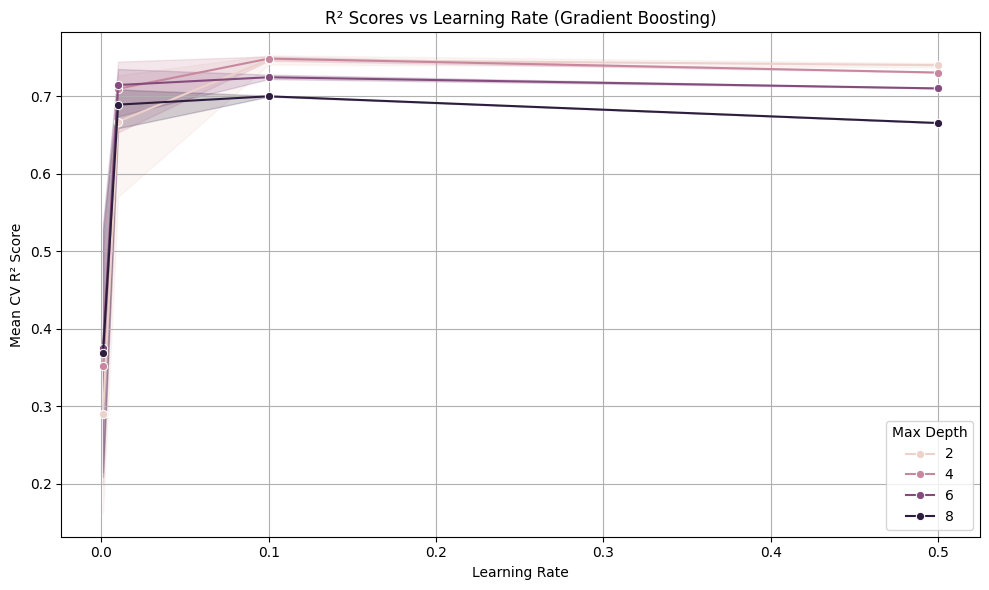

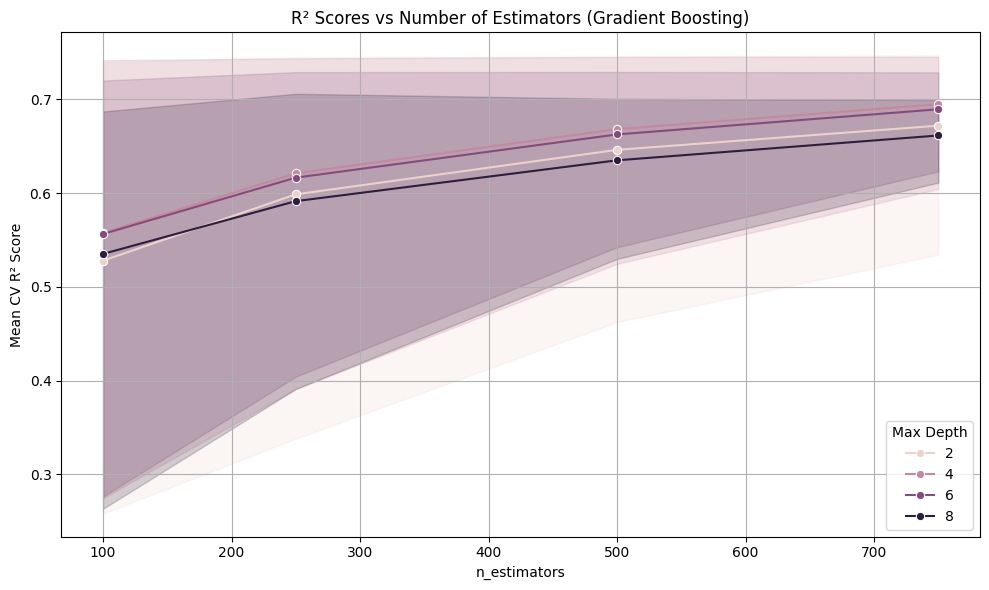

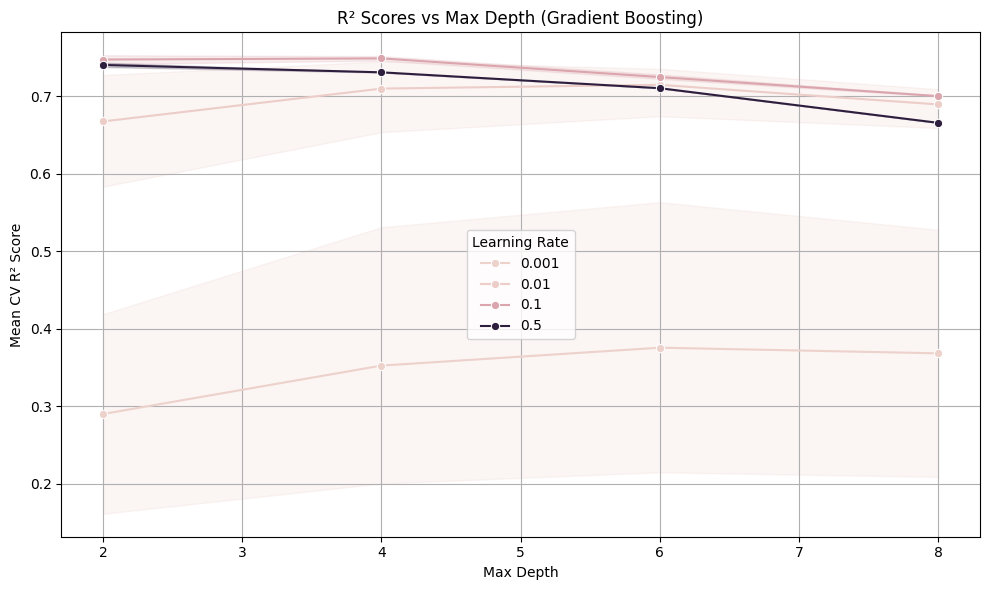

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}
Best CV R² Score: 0.7533830992451147


In [71]:
# -----------------------------
# Define Gradient Boosting model & parameter grid
# -----------------------------
gbr = GradientBoostingRegressor(random_state=42)
param_grid = {
    'learning_rate': [0.5, 0.1, 0.01, 0.001],
    'n_estimators': [100, 250, 500, 750],
    'max_depth': [2, 4, 6, 8]
}

# -----------------------------
# Grid search
# -----------------------------
grid_search = GridSearchCV(gbr, param_grid, scoring='r2', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

# -----------------------------
# Convert results to DataFrame
# -----------------------------
results = pd.DataFrame(grid_search.cv_results_)
print(results)

# -----------------------------
# Plot R² vs learning_rate (color = max_depth)
# -----------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    x='param_learning_rate',
    y='mean_test_score',
    hue='param_max_depth',
    data=results,
    marker='o'
)
plt.title('R² Scores vs Learning Rate (Gradient Boosting)')
plt.xlabel('Learning Rate')
plt.ylabel('Mean CV R² Score')
plt.legend(title='Max Depth')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot R² vs n_estimators (color = max_depth)
# -----------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    x='param_n_estimators',
    y='mean_test_score',
    hue='param_max_depth',
    data=results,
    marker='o'
)
plt.title('R² Scores vs Number of Estimators (Gradient Boosting)')
plt.xlabel('n_estimators')
plt.ylabel('Mean CV R² Score')
plt.legend(title='Max Depth')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot R² vs max_depth (color = learning_rate)
# -----------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    x='param_max_depth',
    y='mean_test_score',
    hue='param_learning_rate',
    data=results,
    marker='o'
)
plt.title('R² Scores vs Max Depth (Gradient Boosting)')
plt.xlabel('Max Depth')
plt.ylabel('Mean CV R² Score')
plt.legend(title='Learning Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Print best parameters & R²
# -----------------------------
print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Comparasion Models</p>
</div>

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.1093 - mae: 1.5826 - val_loss: 0.8871 - val_mae: 0.7899
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1073 - mae: 0.8147 - val_loss: 0.7954 - val_mae: 0.7154
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8740 - mae: 0.7213 - val_loss: 0.7944 - val_mae: 0.6820
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0157 - mae: 0.7692 - val_loss: 0.6542 - val_mae: 0.6379
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0146 - mae: 0.7685 - val_loss: 0.7533 - val_mae: 0.6778
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9008 - mae: 0.7328 - val_loss: 0.6639 - val_mae: 0.6347
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9324 - mae: 0.7383 - val_loss: 0.6194 - val_mae: 0.5991
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8780 - mae: 0.7081 - val_loss: 0.9535 - val_mae: 0.7846
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.83

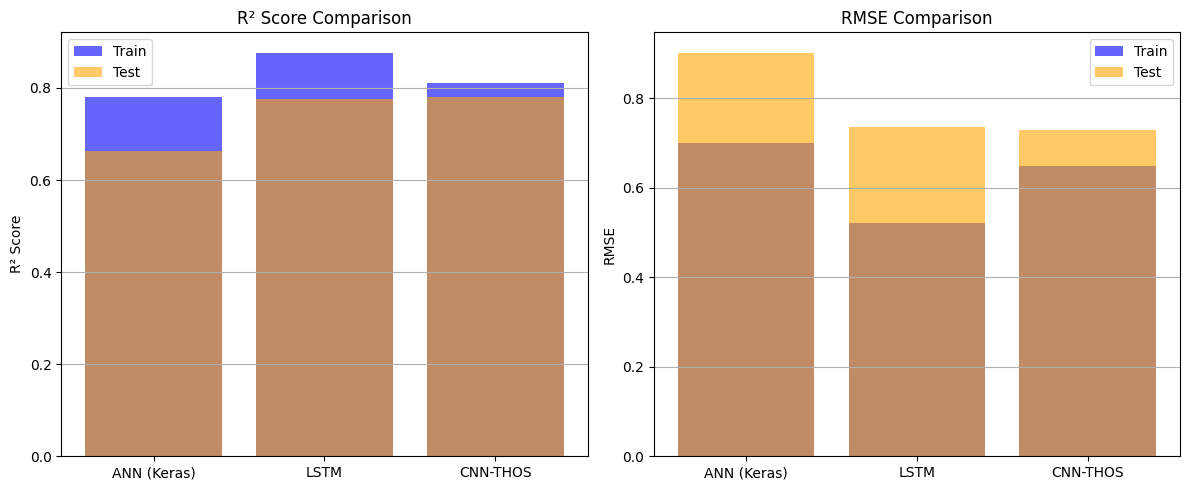

         Model  R2 Train   R2 Test  RMSE Train  RMSE Test
0  ANN (Keras)  0.779342  0.661999    0.699180   0.901941
1         LSTM  0.876954  0.775754    0.522111   0.734651
2     CNN-THOS  0.810178  0.779938    0.648487   0.727766


In [55]:

# ================================
# Reshape Data for CNN and LSTM
# ================================
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ================================
# ANN Model
# ================================
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')
])
ann_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
ann_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)
y_train_pred_ann = ann_model.predict(X_train)
y_test_pred_ann = ann_model.predict(X_test)

# ================================
# LSTM Model
# ================================
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='linear')
])
lstm_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
lstm_model.fit(X_train_lstm, y_train, validation_data=(X_test_lstm, y_test), epochs=100, batch_size=16, verbose=1)
y_train_pred_lstm = lstm_model.predict(X_train_lstm)
y_test_pred_lstm = lstm_model.predict(X_test_lstm)

# ================================
# CNN-THOS Model
# ================================
cnn_thos_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1),
           padding='same',
           kernel_regularizer=regularizers.l2(0.01)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')  # regression output
])
cnn_thos_model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

cnn_thos_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
y_train_pred_cnn = cnn_thos_model.predict(X_train_cnn)
y_test_pred_cnn = cnn_thos_model.predict(X_test_cnn)

# ================================
# Performance Metrics
# ================================
deep_learning_results = [
    {'Model': 'ANN (Keras)',
     'R2 Train': r2_score(y_train, y_train_pred_ann),
     'R2 Test': r2_score(y_test, y_test_pred_ann),
     'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred_ann)),
     'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred_ann))},

    {'Model': 'LSTM',
     'R2 Train': r2_score(y_train, y_train_pred_lstm),
     'R2 Test': r2_score(y_test, y_test_pred_lstm),
     'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred_lstm)),
     'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred_lstm))},

    {'Model': 'CNN-THOS',
     'R2 Train': r2_score(y_train, y_train_pred_cnn),
     'R2 Test': r2_score(y_test, y_test_pred_cnn),
     'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred_cnn)),
     'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred_cnn))}
]

deep_learning_df = pd.DataFrame(deep_learning_results)

# ================================
# Plot Comparison
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['blue', 'orange', 'green']

# R² Score Comparison
axes[0].bar(deep_learning_df['Model'], deep_learning_df['R2 Train'], color=colors[0], alpha=0.6, label='Train')
axes[0].bar(deep_learning_df['Model'], deep_learning_df['R2 Test'], color=colors[1], alpha=0.6, label='Test')
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].grid(axis='y')

# RMSE Comparison
axes[1].bar(deep_learning_df['Model'], deep_learning_df['RMSE Train'], color=colors[0], alpha=0.6, label='Train')
axes[1].bar(deep_learning_df['Model'], deep_learning_df['RMSE Test'], color=colors[1], alpha=0.6, label='Test')
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

# ================================
# Print Results
# ================================
print(deep_learning_df)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Perdiction</p>
</div>


In [72]:
joblib.dump(preprocessor, "preprocessor.pkl")
print("✅ Model saved as 'preprocessor.pkl'")

✅ Model saved as 'preprocessor.pkl'


In [73]:

# Fit model
gboost_model = GradientBoostingRegressor(
    learning_rate=0.5,
    max_depth=2,
    n_estimators=250,
    subsample=0.9,
    random_state=42
)
gboost_model.fit(X_train_p, y_train.ravel())

# Save to disk
joblib.dump(gboost_model, "uptake_model.pkl")
print("✅ Model saved as 'uptake_model.pkl'")

✅ Model saved as 'uptake_model.pkl'
